# Análisis Empresas AI - 2022 Landscape
> **Author:** *Marcela Zena*  
> **Date:** August 2026  

## 📌 Introducción 

Este notebook nace de una pregunta simple:  
**¿Cómo era el mercado de empresas de inteligencia artificial (IA) justo antes de que ChatGPT lo cambiara todo?**

### Punto de partida
Partimos de un dataset público de Kaggle con **3,100 empresas** listadas en Clutch.co en **2022**, con **7 columnas** de información: nombre, ubicación, tamaño, enfoque en IA y datos de precios.

**📦 Dataset:** [AI Companies Dataset](https://www.kaggle.com/datasets/vineethakkinapalli/ai-companies) (Vineeth Akkinapalli, 2022) - Datos reales extraídos de perfiles de empresa en Clutch.co.

### Foto del mercado de IA en 2022
A partir de ahí, el trabajo consistió en:
- Limpiar y estructurar los datos.
- Crear segmentaciones con sentido de negocio (tamaño, especialización en IA, transparencia comercial).
- Explorar dónde están las empresas, qué tipo de proveedores predominan y cuáles son más transparentes.

El resultado no es solo un análisis descriptivo. 
Es una **foto del mercado de IA en 2022**, con una hipótesis clara, hallazgos, y una puerta abierta a futuro.


### 🎯 Hipótesis central

> **"Las empresas con mayor especialización en IA (AI Focus principal), es decir, aquellas cuyo principal servicio es IA son las que presentan mayor potencial de crecimiento"**

Nos interesa este segmento porque resulta interesante y reúne empresas relativamente pequeñas que ya mostraban una fuerte especialización en IA en 2022.

Para validar la hipótesis, nos preguntamos:

1. ¿Qué porcentaje de empresas son AI Focus principal?
2. ¿Dónde se ubican geográficamente?
3. ¿Qué tipo de proveedor predomina en este segmento?
4. ¿Estas empresas informan sus tarifas?
5. ¿Qué nivel de transparencia comercial tienen?


**Validación esperada:**  
Si la hipótesis es correcta, las empresas con AI Focus principal deberían:
- Concentrarse en hubs tecnológicos (USA, UK, etc.).
- Ser mayoritariamente SMB (empresas ágiles con potencial de crecimiento).

Respecto a informar los valores, aparecer un porcentaje de informar valores
- Transparencia comercial


### 🧭 Punto de llegada

Llegamos a un dataset de **23 columnas**, con:
- Desglose de Location en Ciudad, Estado, País y Región.
- Trabajo sobre Number of Employees para llegar a una segmentación por tamaño.
- Segmentaciones propias:
  - **Tipo de proveedor / segmento de análisis:** SMB, Mid-market, Enterprise y Freelancer.
  - **Segmentación servicios AI:** AI Focus principal, AI Focus, AI Service complementary, AI Service residual.
  - **Transparencia Comercial:** Segmentación de transparencia comercial en 2,1 y 0. En base a si informan Minimum Project Size y Average Hourly Rate.
- Tratamiento de la columna país para poder visualizar los países y regiones en un mapa.


### 🗺️ Ruta del Análisis

1. **📥 Carga de Datos y Exploración Inicial**
   - Datos Originales  
   - Exploración Inicial  

2. **🧹 Limpieza y Transformación de Datos**
   - Problemas identificados en la exploración inicial  
   - Proceso de Limpieza inicial  
   - Proceso de Desglose de Location  
   - Estandarización de valores (Undisclosed, Unknown)  
   - Extracción de número de empleados (`Employees_Num`)  
   - Tratamiento de países faltantes y corrección de Cloud(X)  
   - Tratamiento de casos Freelancer y `10,000+` en la columna `Number of Employees`

3. **🏷️ Feature Engineering: Segmentación de Empresas**
   - **3.1** Segmentación por tamaño (`Tipo de proveedor / segmento de análisis`)  
     - Metodología basada en umbrales de empleados (UE/OCDE)  
     - Clasificación para el Análisis Empresas AI  
     - Nuevas columnas: `Clasificación por número de empleados` y `Tipo de proveedor / segmento de análisis`
   - **3.2** Segmentación por enfoque de IA (`Percent AI Service Focus`)  
     - Segmentación por servicios AI en base a porcentajes  
     - Descripción de la segmentación utilizada

4. **🌍 Análisis Geográfico**
   - Ubicación de empresas por país, ciudad y región  
   - Cruces geográficos con segmentos

5. **📊 Análisis Exploratorio (EDA) y Visualizaciones**
   - Distribución geográfica general  
   - Distribución por segmentos  
   - Foco en AI Focus y AI Focus principal  
   - Análisis de transparencia comercial


6. **🎯 Hallazgos & Conclusiones**
   - Validación de la hipótesis inicial  
   - Hallazgos clave y recomendaciones  
   - Próximos pasos

### 📚 Librerias Utilizadas

**Librerias utilizadas**
- import numpy as np
- import pandas as pd

**Para visualización**
- import matplotlib.pyplot as plt
- import seaborn as sns
- import plotly.express as px
- import plotly.graph_objects as go

**Configuración visualización**
- plt.style.use('seaborn-v0_8-darkgrid')
- sns.set_palette("husl")
- %matplotlib inline

## 1️⃣ Carga de Datos y Exploración Inicial

### 📁 Datos Originales

| Caracterísitca | Descripción |
|------|-------------|
| **Archivo** | AI Companies (sin extensión, originalmente CSV) |
| **Total registros** | 3,100 empresas |
| **Columnas originales** | 7 |

Columnas existentes
    - Company_Name
    - Website
    - Location
    - Minimum Project Size
    - Average Hourly Rate
    - Number of Employees
    - Percent AI Service Focus


**📥Cargar dataset original**
> **Aclaración** este proyecto usa datos reales extraídos de perfiles de empresa en Clutch.co, publicados como dataset en Kaggle: AI Companies Dataset.  

**📦 Dataset:** [AI Companies Dataset](https://www.kaggle.com/datasets/vineethakkinapalli/ai-companies) (Vineeth Akkinapalli, 2022) - Datos reales extraídos de perfiles de empresa en Clutch.co.

### 🔍 Exploración Inicial

In [229]:
import pandas as pd

In [230]:
import os
print(os.getcwd()) 

c:\Users\Marcelaz\Documents\AI_Companies


In [231]:
df = pd.read_csv('./data/AI_Companies.csv')

In [232]:
df.head()

,Company_Name,Website,Location,Minimum Project Size,Average Hourly Rate,Number of Employees,Percent AI Service Focus,Unnamed: 7
0,Smith.ai,https://smith.ai/,"Los Altos, CA",Undisclosed,Undisclosed,250 - 999,10%,NaN
1,MooveIt,https://moove-it.com/,"Austin, TX","$100,000+",$50 - $99 / hr,50 - 249,15%,NaN
2,TechSpeedInc,http://www.techspeed.com/,"Portland, OR","$1,000+",< $25 / hr,50 - 249,40%,NaN
3,WillDom,https://willdom.com/,"Fort Lauderdale, FL","$10,000+",$50 - $99 / hr,250 - 999,10%,NaN
4,Icreon,https://www.icreon.com/en,"New York, NY","$50,000+",$100 - $149 / hr,250 - 999,10%,NaN


In [233]:
df.tail()

,Company_Name,Website,Location,Minimum Project Size,Average Hourly Rate,Number of Employees,Percent AI Service Focus,Unnamed: 7
3095,HurekaTechnologiesInc,http://www.hurekatek.com,"New Brunswick, NJ","$10,000+",$25 - $49 / hr,10 - 49,20%,NaN
3096,MYZEALI.T.SolutionsLLC,http://www.myzealit.com/,"Los Angeles, CA","$10,000+",$25 - $49 / hr,250 - 999,10%,NaN
3097,Intelia,https://intelia.io/,"Lagos, Nigeria","$25,000+",Undisclosed,10 - 49,20%,NaN
3098,MojoTrek,http://www.mojotrek.com,"Chicago, IL","$10,000+",$50 - $99 / hr,10 - 49,25%,NaN
3099,HypeTeqSoftwareSolutions,https://www.hypeteq.com/,"Ahmedabad, India","$50,000+",$25 - $49 / hr,10 - 49,10%,NaN


In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Company_Name              3100 non-null   object
 1   Website                   3099 non-null   object
 2   Location                  3087 non-null   object
 3   Minimum Project Size      3100 non-null   object
 4   Average Hourly Rate       3100 non-null   object
 5   Number of Employees       3100 non-null   object
 6   Percent AI Service Focus  3100 non-null   object
 7   Unnamed: 7                1 non-null      object
dtypes: object(8)
memory usage: 193.9+ KB


In [235]:
df.dtypes

Company_Name                object
Website                     object
Location                    object
Minimum Project Size        object
Average Hourly Rate         object
Number of Employees         object
Percent AI Service Focus    object
Unnamed: 7                  object
dtype: object

In [236]:
df.isnull().sum()

Company_Name                   0
Website                        1
Location                      13
Minimum Project Size           0
Average Hourly Rate            0
Number of Employees            0
Percent AI Service Focus       0
Unnamed: 7                  3099
dtype: int64

In [237]:
df.columns

Index(['Company_Name', 'Website', 'Location', 'Minimum Project Size',
       'Average Hourly Rate', 'Number of Employees',
       'Percent AI Service Focus', 'Unnamed: 7'],
      dtype='object')

In [238]:
import pandas as pd

# Análisis específico de la columna 'Location'
print("\n" + "="*50)
print("🔍 ANÁLISIS DE COLUMNA: Location")
print("="*50)


🔍 ANÁLISIS DE COLUMNA: Location


In [239]:
import pandas as pd

print("="*60)
print("🔍 BUSCANDO 'Undisclosed' EN TODAS LAS COLUMNAS")
print("="*60)

# Lista de términos a buscar
terminos = ['Undisclosed', 'Unknown', 'Not specified', 'N/A', 'Not disclosed']

# Revisar cada columna
for columna in df.columns:
    print(f"\n📋 COLUMNA: {columna}")
    print("-"*40)
    
    # Buscar los términos en esta columna
    mascara = df[columna].astype(str).str.contains('|'.join(terminos), case=False, na=False)
    cantidad = mascara.sum()
    
    if cantidad > 0:
        print(f"✅ Encontrados: {cantidad} registros")
        print(f"   {cantidad/len(df)*100:.1f}% del total")
        
        # Mostrar ejemplos
        ejemplos = df[mascara][columna].unique()[:10]
        print(f"   Ejemplos: {', '.join(ejemplos)}")
    else:
        print("❌ No se encontraron valores 'Undisclosed' o similares")

# Resumen final
print("\n" + "="*60)
print("📊 RESUMEN GENERAL")
print("="*60)

# Contar cuántas filas tienen al menos un 'Undisclosed'
todas_columnas = df.astype(str).apply(lambda x: x.str.contains('|'.join(terminos), case=False, na=False))
filas_con_undisclosed = todas_columnas.any(axis=1).sum()

print(f"Total de filas con al menos un 'Undisclosed': {filas_con_undisclosed}")
print(f"Porcentaje del total: {filas_con_undisclosed/len(df)*100:.1f}%")

🔍 BUSCANDO 'Undisclosed' EN TODAS LAS COLUMNAS

📋 COLUMNA: Company_Name
----------------------------------------
❌ No se encontraron valores 'Undisclosed' o similares

📋 COLUMNA: Website
----------------------------------------
✅ Encontrados: 3 registros
   0.1% del total
   Ejemplos: http://www.watrix.ai/en/about-watrix/, https://www.synchrogenix.com/technology-innovation/ai, https://www.morrisopazo.com/en/aws-consulting/

📋 COLUMNA: Location
----------------------------------------
✅ Encontrados: 4 registros
   0.1% del total
   Ejemplos: Unknown, unknown

📋 COLUMNA: Minimum Project Size
----------------------------------------
✅ Encontrados: 1158 registros
   37.4% del total
   Ejemplos: Undisclosed

📋 COLUMNA: Average Hourly Rate
----------------------------------------
✅ Encontrados: 1247 registros
   40.2% del total
   Ejemplos: Undisclosed

📋 COLUMNA: Number of Employees
----------------------------------------
❌ No se encontraron valores 'Undisclosed' o similares

📋 COLUMNA: Pe

In [240]:
# Ver las empresas con Location Undisclosed o Unknown
df[df['Location'].str.contains('Undisclosed|Unknown', case=False, na=False)][['Company_Name', 'Location']]

,Company_Name,Location
1316,IVASYSTEMS,Unknown
2205,ProxNtelliLabsPvtLtd,unknown
2487,Gorixi,Unknown
2495,Comston,Unknown


## 2️⃣ Limpieza y Transformación de Datos

### 📥 Problemas identificados en la exploración inicial
Durante la exploración inicial se identificaron los siguientes problemas que requerirán limpieza:

- Columna extra sin nombre (Unnamed: 7) generada al cargar el archivo.
- Valores Undisclosed o Unknown en varias columnas.
- Análisis de la columna Location.
- Datos mal ubicados (ej. Website en columna Location).
- 13 empresas sin ubicación definida (Location = NaN).

####  🧹 Proceso de Limpieza inicial
A continuación se documenta la solución aplicada a cada problema identificado.

- Ver **Company_Names** sin  información de **Location**.
- Manejo de ubicaciones faltantes para más de 13 empresas. Se busco las **location** faltantes de manera manual y luego se agregó a la columna.
- Crear un diccionario con las ubicaciones de empresas sin location
- Ver valores nulos por columna.
- Eliminar Columna extra sin nombre (Unnamed: 7) generada al cargar el archivo.
- Caso company CloudX Datos mal ubicados (ej. Website en columna Location). 
  - Se buscó el sitio web de manera manual y luego se agregó a la columna correspondiente.
  - Se dejó **Location** vacío.
- Luego se busco la **Location** manual y se agregó a la columna.

In [241]:
# Diccionario con las ubicaciones correctas
ubicaciones_correctas = {
    'ProxNtelliLabsPvtLtd': 'Kakkanad, Kochi, Kerala, India',
    'IVASYSTEMS': 'Technopark, Thiruvananthapuram, India',
    'Gorixi': 'Liverpool, Inglaterra, Reino Unido',
    'Comston': 'Orlando, Florida, Estados Unidos'
}

# Actualizar las ubicaciones
for empresa, ubicacion in ubicaciones_correctas.items():
    df.loc[df['Company_Name'] == empresa, 'Location'] = ubicacion

# Verificar que se actualizó correctamente
print("✅ Ubicaciones actualizadas:")
print(df[df['Company_Name'].isin(ubicaciones_correctas.keys())][['Company_Name', 'Location']])


✅ Ubicaciones actualizadas:
              Company_Name                               Location
1316            IVASYSTEMS  Technopark, Thiruvananthapuram, India
2205  ProxNtelliLabsPvtLtd         Kakkanad, Kochi, Kerala, India
2487                Gorixi     Liverpool, Inglaterra, Reino Unido
2495               Comston       Orlando, Florida, Estados Unidos


In [242]:
# Opción 2: Dejar Location vacío
df.loc[df['Company_Name'] == 'CloudX', 'Website'] = 'https://www.cloudx.com'
df.loc[df['Company_Name'] == 'CloudX', 'Location'] = ''  # o None

# Verificar
print(df[df['Company_Name'] == 'CloudX'][['Company_Name', 'Location', 'Website']])

Empty DataFrame
Columns: [Company_Name, Location, Website]
Index: []


In [243]:
# Ver solo las columnas que nos interesan
print(df[['Company_Name', 'Location', 'Website']].head(20))

            Company_Name                   Location  \
0               Smith.ai              Los Altos, CA   
1                MooveIt                 Austin, TX   
2           TechSpeedInc               Portland, OR   
3                WillDom        Fort Lauderdale, FL   
4                 Icreon               New York, NY   
5                  ELEKS           Tallinn, Estonia   
6               Stepwise           Warszawa, Poland   
7              RevolveAI        Islamabad, Pakistan   
8               Develtio           Warszawa, Poland   
9             JetRockets               Brooklyn, NY   
10                Sciant            Sofia, Bulgaria   
11               Dev.Pro              Charlotte, NC   
12    YugasaSoftwareLabs            Gurugram, India   
13          WorkingMouse          Milton, Australia   
14               Springs              Kyiv, Ukraine   
15              AEStudio            Los Angeles, CA   
16                Anadea  Alicante (Alacant), Spain   
17        

In [244]:
# Ver empresas sin información de Location
sin_location = df[df['Location'].isna() | (df['Location'] == '') | (df['Location'] == 'Undisclosed') | (df['Location'] == 'Unknown')]

print(f"Total de empresas sin Location: {len(sin_location)}")
print("\n📋 Empresas sin Location:")
print(sin_location[['Company_Name', 'Location', 'Website']])

Total de empresas sin Location: 13

📋 Empresas sin Location:
            Company_Name Location  \
190           StoryofAMS      NaN   
448              Aterise      NaN   
486   BlazingTrailPvtLtd      NaN   
526           Dialogflow      NaN   
528        MorganStanley      NaN   
672              ChatBot      NaN   
673             ShieldAI      NaN   
715         Synchrogenix      NaN   
733               MINDAI      NaN   
868             Synaptiq      NaN   
1095       LANDRAudioInc      NaN   
1216         PrediklyLLC      NaN   
2357         Techolution      NaN   

                                                Website  
190                  https://storyofams.com/how-we-work  
448                              http://www.aterise.com  
486                          http://www.blazingtrail.in  
526                             https://dialogflow.com/  
528                           https://www.techstars.com  
672                            https://www.chatbot.com/  
673           

In [245]:
# Ver valores nulos por columna
print(df.isnull().sum())

Company_Name                   0
Website                        1
Location                      13
Minimum Project Size           0
Average Hourly Rate            0
Number of Employees            0
Percent AI Service Focus       0
Unnamed: 7                  3099
dtype: int64


In [246]:
# Ver nulos, vacíos y Undisclosed por columna
for col in df.columns:
    nulos = df[col].isna().sum()
    vacios = (df[col] == '').sum()
    undisclosed = (df[col] == 'Undisclosed').sum()
    unknown = (df[col] == 'Unknown').sum()
    total = nulos + vacios + undisclosed + unknown
    if total > 0:
        print(f"{col}: {total} (nulos: {nulos}, vacíos: {vacios}, Undisclosed: {undisclosed}, Unknown: {unknown})")

Website: 1 (nulos: 1, vacíos: 0, Undisclosed: 0, Unknown: 0)
Location: 13 (nulos: 13, vacíos: 0, Undisclosed: 0, Unknown: 0)
Minimum Project Size: 1158 (nulos: 0, vacíos: 0, Undisclosed: 1158, Unknown: 0)
Average Hourly Rate: 1247 (nulos: 0, vacíos: 0, Undisclosed: 1247, Unknown: 0)
Unnamed: 7: 3099 (nulos: 3099, vacíos: 0, Undisclosed: 0, Unknown: 0)


In [247]:
# Ver los primeros valores de Unnamed: 7
print(df['Unnamed: 7'].head(20))

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
Name: Unnamed: 7, dtype: object


In [248]:
# Si es la columna de índice, elimínala
df = df.drop('Unnamed: 7', axis=1)
print("✅ Columna Unnamed: 7 eliminada")

✅ Columna Unnamed: 7 eliminada


In [249]:
# Ver valores nulos por columna
print(df.isnull().sum())

Company_Name                 0
Website                      1
Location                    13
Minimum Project Size         0
Average Hourly Rate          0
Number of Employees          0
Percent AI Service Focus     0
dtype: int64


In [250]:
# Crear un diccionario con las ubicaciones
ubicaciones = {
    'Morgan Stanley': 'New York, Estados Unidos',
    'ChatBot': 'Estados Unidos',
    'ShieldAI': 'San Diego, California, Estados Unidos',
    'Synchrogenix': 'Wilmington, Delaware, Estados Unidos',
    'MINDAI': 'Ipswich, Inglaterra, Reino Unido',
    'Synaptiq': 'Cluj-Napoca, Rumania',
    'LANDR Audio Inc.': 'Montreal, Canadá',
    'Predikly LLC': 'Cupertino, California, Estados Unidos',
    'Techolution': 'New York, Estados Unidos'
}

# Actualizar la columna 'Location' para estas empresas
for empresa, loc in ubicaciones.items():
    df.loc[df['Company_Name'] == empresa, 'Location'] = loc

# Verificar que se actualizó correctamente
empresas_a_verificar = list(ubicaciones.keys())
print(df[df['Company_Name'].isin(empresas_a_verificar)][['Company_Name', 'Location']])

      Company_Name                               Location
672        ChatBot                         Estados Unidos
673       ShieldAI  San Diego, California, Estados Unidos
715   Synchrogenix   Wilmington, Delaware, Estados Unidos
733         MINDAI       Ipswich, Inglaterra, Reino Unido
868       Synaptiq                   Cluj-Napoca, Rumania
2357   Techolution               New York, Estados Unidos


In [251]:
# Actualizar solo si alguna falta
ubicaciones_confirmadas = {
    'StoryofAMS': 'Amsterdam, North Holland, Países Bajos',
    'Aterise': 'Munich, Bavaria, Germany',
    'BlazingTrailPvtLtd': 'Nueva Delhi, Delhi, India',
    'Dialogflow': 'Mountain View, California, Estados Unidos'
}

for empresa, loc in ubicaciones_confirmadas.items():
    df.loc[df['Company_Name'] == empresa, 'Location'] = loc

print("✅ Ubicaciones actualizadas")

✅ Ubicaciones actualizadas


In [252]:
# Ver valores nulos por columna
print(df.isnull().sum())

Company_Name                0
Website                     1
Location                    3
Minimum Project Size        0
Average Hourly Rate         0
Number of Employees         0
Percent AI Service Focus    0
dtype: int64


In [253]:
# Ver valores nulos por columna
print(df.isnull().sum())

Company_Name                0
Website                     1
Location                    3
Minimum Project Size        0
Average Hourly Rate         0
Number of Employees         0
Percent AI Service Focus    0
dtype: int64


In [254]:
print(f"📊 Total de registros: {len(df)}")
print(f"📋 Columnas: {df.columns.tolist()}")

📊 Total de registros: 3100
📋 Columnas: ['Company_Name', 'Website', 'Location', 'Minimum Project Size', 'Average Hourly Rate', 'Number of Employees', 'Percent AI Service Focus']


In [255]:
# Forzar actualización de las 4 empresas
df.loc[df['Company_Name'] == 'IVASYSTEMS', 'Location'] = 'Technopark, Thiruvananthapuram, India'
df.loc[df['Company_Name'] == 'ProxNtelliLabsPvtLtd', 'Location'] = 'Kakkanad, Kochi, Kerala, India'
df.loc[df['Company_Name'] == 'Gorixi', 'Location'] = 'Liverpool, Inglaterra, Reino Unido'
df.loc[df['Company_Name'] == 'Comston', 'Location'] = 'Orlando, Florida, Estados Unidos'

# Verificar que se actualizaron
print("🔍 Verificando actualización:")
print(df[df['Company_Name'].isin(['IVASYSTEMS', 'ProxNtelliLabsPvtLtd', 'Gorixi', 'Comston'])][['Company_Name', 'Location']])

🔍 Verificando actualización:
              Company_Name                               Location
1316            IVASYSTEMS  Technopark, Thiruvananthapuram, India
2205  ProxNtelliLabsPvtLtd         Kakkanad, Kochi, Kerala, India
2487                Gorixi     Liverpool, Inglaterra, Reino Unido
2495               Comston       Orlando, Florida, Estados Unidos


In [256]:
# Ver valores nulos por columna
print(df.isnull().sum())

Company_Name                0
Website                     1
Location                    3
Minimum Project Size        0
Average Hourly Rate         0
Number of Employees         0
Percent AI Service Focus    0
dtype: int64


In [257]:
# Ver empresas sin información de Location
sin_location = df[df['Location'].isna() | (df['Location'] == '') | (df['Location'] == 'Undisclosed') | (df['Location'] == 'Unknown')]

print(f"Total de empresas sin Location: {len(sin_location)}")
print("\n📋 Empresas sin Location:")
print(sin_location[['Company_Name', 'Location', 'Website']])

Total de empresas sin Location: 3

📋 Empresas sin Location:
       Company_Name Location                    Website
528   MorganStanley      NaN  https://www.techstars.com
1095  LANDRAudioInc      NaN  https://www.landr.com/en/
1216    PrediklyLLC      NaN    http://www.predikly.com


In [258]:
# Actualizar las 3 empresas que faltan
df.loc[df['Company_Name'] == 'Morgan Stanley', 'Location'] = 'New York, Estados Unidos'
df.loc[df['Company_Name'] == 'LANDR Audio Inc.', 'Location'] = 'Montreal, Canadá'
df.loc[df['Company_Name'] == 'Predikly LLC', 'Location'] = 'Cupertino, California, Estados Unidos'

# Verificar que se actualizaron
print("🔍 Verificando actualización:")
print(df[df['Company_Name'].isin(['Morgan Stanley', 'LANDR Audio Inc.', 'Predikly LLC'])][['Company_Name', 'Location']])

🔍 Verificando actualización:
Empty DataFrame
Columns: [Company_Name, Location]
Index: []


In [259]:
# 1. Ver las 3 empresas actualizadas
print("🔍 EMPRESAS ACTUALIZADAS:")
print(df[df['Company_Name'].isin(['Morgan Stanley', 'LANDR Audio Inc.', 'Predikly LLC'])][['Company_Name', 'Location']])

# 2. Verificar que ya no hay nulos en Location para estas empresas
print("\n📊 VERIFICACIÓN DE NULOS:")
print(f"¿Morgan Stanley tiene Location? {df[df['Company_Name'] == 'Morgan Stanley']['Location'].isna().sum() == 0}")
print(f"¿LANDR Audio Inc. tiene Location? {df[df['Company_Name'] == 'LANDR Audio Inc.']['Location'].isna().sum() == 0}")
print(f"¿Predikly LLC tiene Location? {df[df['Company_Name'] == 'Predikly LLC']['Location'].isna().sum() == 0}")

# 3. Contar total de nulos en Location
print(f"\n📍 Total de nulos en Location: {df['Location'].isna().sum()}")

🔍 EMPRESAS ACTUALIZADAS:
Empty DataFrame
Columns: [Company_Name, Location]
Index: []

📊 VERIFICACIÓN DE NULOS:
¿Morgan Stanley tiene Location? True
¿LANDR Audio Inc. tiene Location? True
¿Predikly LLC tiene Location? True

📍 Total de nulos en Location: 3


In [260]:
# Buscar las empresas sin Location
print("🔍 EMPRESAS CON LOCATION NULO:")
print(df[df['Location'].isna()][['Company_Name', 'Website']])

🔍 EMPRESAS CON LOCATION NULO:
       Company_Name                    Website
528   MorganStanley  https://www.techstars.com
1095  LANDRAudioInc  https://www.landr.com/en/
1216    PrediklyLLC    http://www.predikly.com


In [261]:
# Actualizar con los nombres exactos del DataFrame
df.loc[df['Company_Name'] == 'MorganStanley', 'Location'] = 'New York, Estados Unidos'
df.loc[df['Company_Name'] == 'LANDRAudioInc', 'Location'] = 'Montreal, Canadá'
df.loc[df['Company_Name'] == 'PrediklyLLC', 'Location'] = 'Cupertino, California, Estados Unidos'

# Verificar que se actualizaron
print("🔍 Verificando actualización:")
print(df[df['Company_Name'].isin(['MorganStanley', 'LANDRAudioInc', 'PrediklyLLC'])][['Company_Name', 'Location']])

🔍 Verificando actualización:
       Company_Name                               Location
528   MorganStanley               New York, Estados Unidos
1095  LANDRAudioInc                       Montreal, Canadá
1216    PrediklyLLC  Cupertino, California, Estados Unidos


In [262]:
# Ver valores nulos por columna
print(df.isnull().sum())

Company_Name                0
Website                     1
Location                    0
Minimum Project Size        0
Average Hourly Rate         0
Number of Employees         0
Percent AI Service Focus    0
dtype: int64


In [263]:
# Ver empresas sin información de Website
sin_Website = df[df['Website'].isna() | (df['Website'] == '') | (df['Website'] == 'Undisclosed') | (df['Website'] == 'Unknown')]

print(f"Total de empresas sin Website: {len(sin_Website)}")
print("\n📋 Empresas sin Website:")
print(sin_location[['Company_Name', 'Location', 'Website']])

Total de empresas sin Website: 1

📋 Empresas sin Website:
       Company_Name Location                    Website
528   MorganStanley      NaN  https://www.techstars.com
1095  LANDRAudioInc      NaN  https://www.landr.com/en/
1216    PrediklyLLC      NaN    http://www.predikly.com


In [264]:
# Actualizar Website para Cloud(X)
df.loc[df['Company_Name'] == 'Cloud(X)', 'Website'] = 'https://www.cloudx.com'
df.loc[df['Company_Name'] == 'Cloud(X)', 'Location'] = ''  # o el valor que corresponda

# Verificar que se actualizó
print("🔍 Verificando actualización:")
print(df[df['Company_Name'] == 'Cloud(X)'][['Company_Name', 'Website', 'Location']])

🔍 Verificando actualización:
     Company_Name                 Website Location
2261     Cloud(X)  https://www.cloudx.com         


In [265]:
# Actualizar la ubicación de Cloud(X)
df.loc[df['Company_Name'] == 'Cloud(X)', 'Location'] = 'Manalapan, Nueva Jersey, Estados Unidos'

# Verificar que se actualizó
print(df[df['Company_Name'] == 'Cloud(X)'][['Company_Name', 'Location']])

     Company_Name                                 Location
2261     Cloud(X)  Manalapan, Nueva Jersey, Estados Unidos


In [266]:
# Ver valores nulos por columna
print(df.isnull().sum())

Company_Name                0
Website                     0
Location                    0
Minimum Project Size        0
Average Hourly Rate         0
Number of Employees         0
Percent AI Service Focus    0
dtype: int64


In [267]:
# Diccionario con todas las correcciones
paises = {
    'Codezeros': 'India',
    'Primer': 'Estados Unidos',
    'BorealisAI': 'Canadá',
    'Tractable': 'Reino Unido',
    'Dessa': 'Canadá',
    'EnterpriseBot': 'Suiza',
    'Juvenescence.AI': 'Estados Unidos',
    'Agorai': 'Estados Unidos',
    'Eliiza': 'Australia',
    'BlackOps': 'Estados Unidos',
    'PlyzerTechnologies': 'España',
    'MAGICAI': 'Estados Unidos',
    'ZombieSoup': 'Kosovo',
    'Indielabs,LLC.': 'Arabia Saudita',
    'AssertiaSolutions': 'Estados Unidos',
    'BultedSoftware': 'Puerto Rico'
}

# Aplicar todas las correcciones
for empresa, pais in paises.items():
    df.loc[df['Company_Name'] == empresa, 'Country'] = pais

####  🧹 Proceso de Desglose de Location
Desglosamos **Location** en Ciudad, Estado y País

- Desglose de **Location** en 3 nuevas columnas:
  - Ciudad
  - Estado
  - País
- Búsqueda manual de 5 companies que le faltban país y se agregó país a esas Company_Name
- 3100 empresas quedaron con país informado.


In [268]:
# Diccionario de países y sus códigos/abreviaturas
paises_conocidos = {
    'United States': 'USA', 'USA': 'USA', 'US': 'USA', 'United States of America': 'USA',
    'Canada': 'Canada', 'UK': 'UK', 'United Kingdom': 'UK', 'England': 'UK',
    'India': 'India', 'Germany': 'Germany', 'France': 'France', 'Spain': 'Spain',
    'Italy': 'Italy', 'Japan': 'Japan', 'China': 'China', 'Australia': 'Australia',
    'Brazil': 'Brazil', 'Mexico': 'Mexico', 'Argentina': 'Argentina', 'Poland': 'Poland',
    'Netherlands': 'Netherlands', 'Singapore': 'Singapore', 'UAE': 'UAE',
    'Switzerland': 'Switzerland', 'Sweden': 'Sweden', 'Norway': 'Norway'
}

# Diccionario de estados de EE.UU.
estados_usa = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming'
}

# Función para detectar si un texto es un país
def es_pais(texto):
    if not texto:
        return False
    texto_limpio = texto.strip()
    # Buscar coincidencia exacta o parcial
    for pais in paises_conocidos.keys():
        if pais.lower() in texto_limpio.lower() or texto_limpio.lower() in pais.lower():
            return True
    return False

# Función para detectar si es un estado de EE.UU.
def es_estado_usa(texto):
    if not texto:
        return False
    texto_limpio = texto.strip().upper()
    return texto_limpio in estados_usa

# Función principal de desglose
def desglosar_ubicacion_avanzado(location):
    if pd.isna(location) or location == '' or location == 'Undisclosed' or location == 'Unknown':
        return None, None, None
    
    # Separar por comas
    partes = [p.strip() for p in str(location).split(',')]
    
    # Caso 1: Solo una parte
    if len(partes) == 1:
        texto = partes[0]
        if es_pais(texto):
            return None, None, texto
        elif es_estado_usa(texto):
            return None, texto, 'USA'
        else:
            return texto, None, None
    
    # Caso 2: Dos partes
    elif len(partes) == 2:
        p1, p2 = partes[0], partes[1]
        
        # Si p2 es estado de EE.UU.
        if es_estado_usa(p2):
            return p1, p2, 'USA'
        
        # Si p2 es país
        elif es_pais(p2):
            return p1, None, p2
        
        # Si p1 es país y p2 es ciudad
        elif es_pais(p1):
            return p2, None, p1
        
        # Si p1 es estado y p2 es país
        elif es_estado_usa(p1) and es_pais(p2):
            return None, p1, p2
        
        # Caso general
        else:
            return p1, None, p2
    
    # Caso 3: Tres partes
    elif len(partes) == 3:
        p1, p2, p3 = partes[0], partes[1], partes[2]
        
        # Detectar automáticamente
        if es_estado_usa(p2):
            return p1, p2, p3
        elif es_pais(p3):
            return p1, p2, p3
        else:
            # Formato: Ciudad, Estado, País (intentar inferir)
            if es_estado_usa(p2):
                return p1, p2, p3
            else:
                return p1, p2, p3
    
    # Más de 3 partes
    else:
        # Tomar las primeras como ciudad y el resto como país
        ciudad = partes[0]
        estado = None
        # Buscar estado entre las partes
        for p in partes[1:]:
            if es_estado_usa(p):
                estado = p
                break
        # Buscar país entre las partes
        pais = None
        for p in partes[1:]:
            if es_pais(p):
                pais = p
                break
        return ciudad, estado, pais

# Aplicar la función a todo el DataFrame
print("🔄 Procesando 3000 registros...")
df[['Ciudad', 'Estado', 'Pais']] = df['Location'].apply(
    lambda x: pd.Series(desglosar_ubicacion_avanzado(x))
)

print("✅ Procesamiento completado!")

# Ver resultados
print("\n📊 Resumen de desglose:")
print(f"Ciudad: {df['Ciudad'].notna().sum()} de {len(df)}")
print(f"Estado: {df['Estado'].notna().sum()} de {len(df)}")
print(f"País: {df['Pais'].notna().sum()} de {len(df)}")

🔄 Procesando 3000 registros...
✅ Procesamiento completado!

📊 Resumen de desglose:
Ciudad: 3077 de 3100
Estado: 912 de 3100
País: 3095 de 3100


In [269]:
# Ver empresas sin Ciudad
sin_ciudad = df[df['Ciudad'].isna()]
print(f"\n🔍 Empresas sin Ciudad: {len(sin_ciudad)}")
print(sin_ciudad[['Company_Name', 'Location']].head(10))

# Ver empresas sin País
sin_pais = df[df['Pais'].isna()]
print(f"\n🔍 Empresas sin País: {len(sin_pais)}")
print(sin_pais[['Company_Name', 'Location']].head(10))


🔍 Empresas sin Ciudad: 23
                    Company_Name   Location
200            MellivoraSoftware    Ukraine
310          BazingoInc.Pte.Ltd.  Singapore
363   OpenTangerineSoftwareHouse     Poland
380              SpritleSoftware  Singapore
395                     Acmex.co     Mexico
580                      Botsify  Australia
787                      Inspiro  Australia
857                         Aire  Australia
859                  HEORobotics  Australia
1033                      TaxBot  Australia

🔍 Empresas sin País: 5
              Company_Name        Location
672                ChatBot  Estados Unidos
1397                BluLtd       Hong Kong
2504  iPhoneAppDevelopment          Panama
2667    BecomeDigitalToday     Philippines
2680              Teknodev          Turkey


In [270]:
# Diccionario de correcciones para empresas sin Ciudad
correcciones_ciudad = {
    'MellivoraSoftware': 'Ukraine',  # No especifica ciudad, solo país
    'BazingoInc.Pte.Ltd.': 'Singapore',  # No especifica ciudad, solo país
    'OpenTangerineSoftwareHouse': 'Poland',  # No especifica ciudad, solo país
    'SpritleSoftware': 'Singapore',  # No especifica ciudad, solo país
    'Acmex.co': 'Mexico',  # No especifica ciudad, solo país
    'Botsify': 'Australia',  # No especifica ciudad, solo país
    'Inspiro': 'Australia',  # No especifica ciudad, solo país
    'Aire': 'Australia',  # No especifica ciudad, solo país
    'HEORobotics': 'Australia',  # No especifica ciudad, solo país
    'TaxBot': 'Australia',  # No especifica ciudad, solo país
    # Añadir el resto según sea necesario
}

# Aplicar correcciones
for empresa, ciudad in correcciones_ciudad.items():
    df.loc[df['Company_Name'] == empresa, 'Ciudad'] = ciudad

print("✅ Ciudades corregidas para empresas sin ubicación específica")

✅ Ciudades corregidas para empresas sin ubicación específica


In [271]:
# Corrección para empresas sin País
correcciones_pais = {
    'ChatBot': 'Estados Unidos',
    'BluLtd': 'Hong Kong',
    'iPhoneAppDevelopment': 'Panamá',
    'BecomeDigitalToday': 'Filipinas',
    'Teknodev': 'Turquía'
}

# Aplicar correcciones
for empresa, pais in correcciones_pais.items():
    df.loc[df['Company_Name'] == empresa, 'Pais'] = pais
    # Si también tienen Location, actualizar
    if df.loc[df['Company_Name'] == empresa, 'Location'].isna().any():
        df.loc[df['Company_Name'] == empresa, 'Location'] = pais

print("✅ Países corregidos")

✅ Países corregidos


In [272]:
# Verificar que ya no hay casos problemáticos
print("🔍 Verificando correcciones:")

# Empresas sin Ciudad
sin_ciudad = df[df['Ciudad'].isna()]
print(f"\nEmpresas sin Ciudad: {len(sin_ciudad)}")
if len(sin_ciudad) > 0:
    print(sin_ciudad[['Company_Name', 'Location']])

# Empresas sin País
sin_pais = df[df['Pais'].isna()]
print(f"\nEmpresas sin País: {len(sin_pais)}")
if len(sin_pais) > 0:
    print(sin_pais[['Company_Name', 'Location']])

🔍 Verificando correcciones:

Empresas sin Ciudad: 13
                   Company_Name   Location
1102                    Everise  Singapore
1161   FusionInformaticsLimited      India
1356                       Addo  Singapore
1682              TurnKeyLender  Singapore
2321        WebWerksDataCenters      India
2388                  EveryCode    Ukraine
2541  ForteInnovationConsulting     Mexico
2665                  Neutrinos  Singapore
2688      KloudynetTechnologies      India
2719                     citigp     Mexico
2824                        QDS  Singapore
2882           EMCOMDevelopment     Poland
2923                   iDevTeam     Poland

Empresas sin País: 0


In [273]:
# Diccionario de correcciones para las 13 empresas sin Ciudad
correcciones_ciudad = {
    'Everise': 'Singapore',
    'FusionInformaticsLimited': 'India',
    'Addo': 'Singapore',
    'TurnKeyLender': 'Singapore',
    'WebWerksDataCenters': 'India',
    'EveryCode': 'Ukraine',
    'ForteInnovationConsulting': 'Mexico',
    'Neutrinos': 'Singapore',
    'KloudynetTechnologies': 'India',
    'citigp': 'Mexico',
    'QDS': 'Singapore',
    'EMCOMDevelopment': 'Poland',
    'iDevTeam': 'Poland'
}

# Aplicar correcciones
for empresa, ciudad in correcciones_ciudad.items():
    df.loc[df['Company_Name'] == empresa, 'Ciudad'] = ciudad

print("✅ 13 empresas corregidas")

# Verificar que ya no hay empresas sin Ciudad
sin_ciudad = df[df['Ciudad'].isna()]
print(f"\n📊 Empresas sin Ciudad restantes: {len(sin_ciudad)}")
if len(sin_ciudad) > 0:
    print(sin_ciudad[['Company_Name', 'Location']])
else:
    print("🎉 ¡Todas las empresas tienen Ciudad!")

✅ 13 empresas corregidas

📊 Empresas sin Ciudad restantes: 0
🎉 ¡Todas las empresas tienen Ciudad!


In [274]:
# Resumen final
print("\n📊 RESUMEN FINAL:")
print(f"Total empresas: {len(df)}")
print(f"Empresas con Ciudad: {df['Ciudad'].notna().sum()}")
print(f"Empresas con Estado: {df['Estado'].notna().sum()}")
print(f"Empresas con País: {df['Pais'].notna().sum()}")


📊 RESUMEN FINAL:
Total empresas: 3100
Empresas con Ciudad: 3100
Empresas con Estado: 912
Empresas con País: 3100


In [275]:
# Ver el registro de Cloud(X) actualmente
print("🔍 Registro actual de Cloud(X):")
print(df[df['Company_Name'] == 'Cloud(X)'][['Company_Name', 'Minimum Project Size', 'Average Hourly Rate', 'Location']])

# Corregir Minimum Project Size de Cloud(X)
df.loc[df['Company_Name'] == 'Cloud(X)', 'Minimum Project Size'] = 'Undisclosed'

# Verificar la corrección
print("\n✅ Registro corregido de Cloud(X):")
print(df[df['Company_Name'] == 'Cloud(X)'][['Company_Name', 'Minimum Project Size', 'Average Hourly Rate', 'Location']])

🔍 Registro actual de Cloud(X):
     Company_Name    Minimum Project Size Average Hourly Rate  \
2261     Cloud(X)  Yerba Buena, Argentina             $5,000+   

                                     Location  
2261  Manalapan, Nueva Jersey, Estados Unidos  

✅ Registro corregido de Cloud(X):
     Company_Name Minimum Project Size Average Hourly Rate  \
2261     Cloud(X)          Undisclosed             $5,000+   

                                     Location  
2261  Manalapan, Nueva Jersey, Estados Unidos  


####  🧹 Companies con datos Undisclosed 
En la exploración inicial el dato Undisclosed para las columnas 
 -Minimum Project Size
 -Average Hourly Rate

Estandarización de Valores
  - Reemplazo de valores no informados: Se agruparon y reemplazaron valores como Undisclosed y Unknown por NaN para su correcto tratamiento
  - Validación de datos: Se verificó que las columnas numéricas (Minimum Project Size, Average Hourly Rate, etc.) tuvieran datos consistentes.

Creación de 2 nuevas columnas, para diferenciar aquellas empresas que informan o publican datos de las que no.
-Disponibilidad_MinProject: "Informado" / "No informado"
-Disponibilidad_HourlyRate: "Informado" / "No informado"

Quedando 12 columnas.

In [276]:
# Crear nueva columna: Disponibilidad_MinProject
df['Disponibilidad_MinProject'] = df['Minimum Project Size'].apply(
    lambda x: 'No informado' if x == 'Undisclosed' else 'Informado'
)

# Verificar la nueva columna
print("📊 Distribución de disponibilidad de Minimum Project Size:")
print(df['Disponibilidad_MinProject'].value_counts())
print(f"\nPorcentajes:")
print(df['Disponibilidad_MinProject'].value_counts(normalize=True) * 100)

# Ver algunos ejemplos
print("\n📋 Ejemplos de empresas con y sin datos:")
ejemplos = df[df['Company_Name'].isin(['Cloud(X)', 'Smith.ai', 'IVASYSTEMS', 'Comston'])][['Company_Name', 'Minimum Project Size', 'Disponibilidad_MinProject']]
print(ejemplos)

📊 Distribución de disponibilidad de Minimum Project Size:
Disponibilidad_MinProject
Informado       1941
No informado    1159
Name: count, dtype: int64

Porcentajes:
Disponibilidad_MinProject
Informado       62.612903
No informado    37.387097
Name: proportion, dtype: float64

📋 Ejemplos de empresas con y sin datos:
     Company_Name Minimum Project Size Disponibilidad_MinProject
0        Smith.ai          Undisclosed              No informado
1316   IVASYSTEMS              $1,000+                 Informado
2261     Cloud(X)          Undisclosed              No informado
2495      Comston             $10,000+                 Informado


In [277]:
# Crear columnas de disponibilidad
df['Disponibilidad_MinProject'] = df['Minimum Project Size'].apply(
    lambda x: 'No informado' if x == 'Undisclosed' else 'Informado'
)

df['Disponibilidad_HourlyRate'] = df['Average Hourly Rate'].apply(
    lambda x: 'No informado' if x == 'Undisclosed' else 'Informado'
)

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company_Name               3100 non-null   object
 1   Website                    3100 non-null   object
 2   Location                   3100 non-null   object
 3   Minimum Project Size       3100 non-null   object
 4   Average Hourly Rate        3100 non-null   object
 5   Number of Employees        3100 non-null   object
 6   Percent AI Service Focus   3100 non-null   object
 7   Country                    16 non-null     object
 8   Ciudad                     3100 non-null   object
 9   Estado                     912 non-null    object
 10  Pais                       3100 non-null   object
 11  Disponibilidad_MinProject  3100 non-null   object
 12  Disponibilidad_HourlyRate  3100 non-null   object
dtypes: object(13)
memory usage: 315.0+ KB


####  🧹 Tratamiento de la columna Number of Employees

- Los datos reales tienen caracteres, comas y espacios. Presentan rangos como 50 - 249
- Transformación: Extraer números de rangos de empleados. Extraer el número máximo. Ej 249
- Clasificación: SMB (<=500) vs Enterprise (>500)
- Presencia de 35 casos con valores con signo +(10,000+) y texto (Freelancer)
- Exportación de los 35 casos a un un CSV

In [279]:
import pandas as pd

# Ver el tipo de dato
print("Tipo de dato:", df["Number of Employees"].dtype)
print("\n" + "="*50 + "\n")

Tipo de dato: object




In [280]:
# Ver los valores reales con sus caracteres
print("Valores de la columna:")
for i in range(min(30, len(df))):
    valor = df["Number of Employees"].iloc[i]
    print(f"Fila {i}: '{valor}' (tipo: {type(valor).__name__})")

Valores de la columna:
Fila 0: '250 - 999' (tipo: str)
Fila 1: '50 - 249' (tipo: str)
Fila 2: '50 - 249' (tipo: str)
Fila 3: '250 - 999' (tipo: str)
Fila 4: '250 - 999' (tipo: str)
Fila 5: '1,000 - 9,999' (tipo: str)
Fila 6: '10 - 49' (tipo: str)
Fila 7: '10 - 49' (tipo: str)
Fila 8: '50 - 249' (tipo: str)
Fila 9: '10 - 49' (tipo: str)
Fila 10: '50 - 249' (tipo: str)
Fila 11: '250 - 999' (tipo: str)
Fila 12: '50 - 249' (tipo: str)
Fila 13: '50 - 249' (tipo: str)
Fila 14: '50 - 249' (tipo: str)
Fila 15: '50 - 249' (tipo: str)
Fila 16: '50 - 249' (tipo: str)
Fila 17: '10 - 49' (tipo: str)
Fila 18: '50 - 249' (tipo: str)
Fila 19: '50 - 249' (tipo: str)
Fila 20: '250 - 999' (tipo: str)
Fila 21: '10 - 49' (tipo: str)
Fila 22: '10 - 49' (tipo: str)
Fila 23: '50 - 249' (tipo: str)
Fila 24: '10 - 49' (tipo: str)
Fila 25: '50 - 249' (tipo: str)
Fila 26: '50 - 249' (tipo: str)
Fila 27: '10 - 49' (tipo: str)
Fila 28: '50 - 249' (tipo: str)
Fila 29: '10 - 49' (tipo: str)


In [281]:
# Ver si hay comas, puntos, etc.
print("Buscando caracteres especiales:")
for i in range(min(30, len(df))):
    valor = str(df["Number of Employees"].iloc[i])
    if ',' in valor or '.' in valor or 'k' in valor.lower() or 'K' in valor:
        print(f"Fila {i}: '{valor}'")

Buscando caracteres especiales:
Fila 5: '1,000 - 9,999'


In [282]:
import pandas as pd

# Verificar estado actual del DataFrame
print(f"Dimensiones: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print("\nPrimeras 5 filas:")
print(df.head())

Dimensiones: (3100, 13)
Columnas: ['Company_Name', 'Website', 'Location', 'Minimum Project Size', 'Average Hourly Rate', 'Number of Employees', 'Percent AI Service Focus', 'Country', 'Ciudad', 'Estado', 'Pais', 'Disponibilidad_MinProject', 'Disponibilidad_HourlyRate']

Primeras 5 filas:
   Company_Name                    Website             Location  \
0      Smith.ai          https://smith.ai/        Los Altos, CA   
1       MooveIt      https://moove-it.com/           Austin, TX   
2  TechSpeedInc  http://www.techspeed.com/         Portland, OR   
3       WillDom       https://willdom.com/  Fort Lauderdale, FL   
4        Icreon  https://www.icreon.com/en         New York, NY   

  Minimum Project Size Average Hourly Rate Number of Employees  \
0          Undisclosed         Undisclosed           250 - 999   
1            $100,000+      $50 - $99 / hr            50 - 249   
2              $1,000+          < $25 / hr            50 - 249   
3             $10,000+      $50 - $99 / hr   

In [283]:
# Ver la columna específica
print("\n" + "="*50)
print("VERIFICACIÓN DE LA COLUMNA 'Number of Employees'")
print("="*50)

# 1. Tipo de dato
print(f"\n1. Tipo de dato: {df['Number of Employees'].dtype}")

# 2. Ver valores reales
print("\n2. Primeros 10 valores:")
for i in range(min(10, len(df))):
    valor = df['Number of Employees'].iloc[i]
    print(f"   Fila {i}: '{valor}'")

# 3. Ver valores únicos (primeros 10)
print("\n3. Valores únicos (primeros 10):")
print(df['Number of Employees'].unique()[:10])

# 4. Verificar si hay nulos
print(f"\n4. Valores nulos: {df['Number of Employees'].isna().sum()}")


VERIFICACIÓN DE LA COLUMNA 'Number of Employees'

1. Tipo de dato: object

2. Primeros 10 valores:
   Fila 0: '250 - 999'
   Fila 1: '50 - 249'
   Fila 2: '50 - 249'
   Fila 3: '250 - 999'
   Fila 4: '250 - 999'
   Fila 5: '1,000 - 9,999'
   Fila 6: '10 - 49'
   Fila 7: '10 - 49'
   Fila 8: '50 - 249'
   Fila 9: '10 - 49'

3. Valores únicos (primeros 10):
['250 - 999' '50 - 249' '1,000 - 9,999' '10 - 49' '2 - 9' '10,000+'
 'Freelancer' '$50 - $99 / hr']

4. Valores nulos: 0


In [284]:
print("\n" + "="*50)
print("PRUEBA DE EXTRACCIÓN PASO A PASO")
print("="*50)

# Tomar un valor de ejemplo
ejemplo = df['Number of Employees'].iloc[0]
print(f"\nValor ejemplo: '{ejemplo}'")

# PASO 1: Split por '-'
paso1 = df['Number of Employees'].str.split('-')
print(f"\nPASO 1 (split por '-'):")
print(paso1.head(5))

# PASO 2: Tomar posición [1] (derecha)
paso2 = paso1.str[1]
print(f"\nPASO 2 (tomar posición 1):")
print(paso2.head(5))

# PASO 3: Strip (quitar espacios)
paso3 = paso2.str.strip()
print(f"\nPASO 3 (quitar espacios):")
print(paso3.head(5))

# PASO 4: Eliminar comas
paso4 = paso3.str.replace(',', '')
print(f"\nPASO 4 (eliminar comas):")
print(paso4.head(5))

# PASO 5: Ver qué valores quedaron
print(f"\nPASO 5 (ver valores):")
print(f"Tipo de dato: {paso4.dtype}")
print(f"Valores: {paso4.head(10).tolist()}")


PRUEBA DE EXTRACCIÓN PASO A PASO

Valor ejemplo: '250 - 999'

PASO 1 (split por '-'):
0    [250 ,  999]
1     [50 ,  249]
2     [50 ,  249]
3    [250 ,  999]
4    [250 ,  999]
Name: Number of Employees, dtype: object

PASO 2 (tomar posición 1):
0     999
1     249
2     249
3     999
4     999
Name: Number of Employees, dtype: object

PASO 3 (quitar espacios):
0    999
1    249
2    249
3    999
4    999
Name: Number of Employees, dtype: object

PASO 4 (eliminar comas):
0    999
1    249
2    249
3    999
4    999
Name: Number of Employees, dtype: object

PASO 5 (ver valores):
Tipo de dato: object
Valores: ['999', '249', '249', '999', '999', '9999', '49', '49', '249', '49']


In [285]:
print("\n" + "="*50)
print("CREANDO COLUMNA Employees_Num")
print("="*50)

# Crear columna con todos los pasos juntos
df["Employees_Num"] = (
    df["Number of Employees"]
    .str.split('-')          # Separar por guión
    .str[1]                  # Tomar parte derecha
    .str.strip()             # Quitar espacios
    .str.replace(',', '')    # Eliminar comas
)

print(f"\nColumna creada: {df['Employees_Num'].dtype}")
print(f"Primeros 10 valores:")
print(df["Employees_Num"].head(10))


CREANDO COLUMNA Employees_Num

Columna creada: object
Primeros 10 valores:
0     999
1     249
2     249
3     999
4     999
5    9999
6      49
7      49
8     249
9      49
Name: Employees_Num, dtype: object


In [286]:
print("\n" + "="*50)
print("CONVIRTIENDO A NÚMERO")
print("="*50)

# Convertir a numérico (los errores se convierten en NaN)
df["Employees_Num"] = pd.to_numeric(df["Employees_Num"], errors='coerce')

print(f"\nDespués de conversión:")
print(f"Tipo: {df['Employees_Num'].dtype}")
print(f"Valores nulos: {df['Employees_Num'].isna().sum()}")

# Ver qué valores quedaron como NaN (problemas)
problemas = df[df["Employees_Num"].isna()]
if len(problemas) > 0:
    print(f"\n⚠️ Hay {len(problemas)} valores que no se pudieron convertir:")
    print(problemas[["Company_Name", "Number of Employees"]].head(10))
else:
    print("\n✅ Todos los valores se convirtieron correctamente")


CONVIRTIENDO A NÚMERO

Después de conversión:
Tipo: float64
Valores nulos: 35

⚠️ Hay 35 valores que no se pudieron convertir:
                   Company_Name Number of Employees
72                 CSPSolutions             10,000+
207                SpesRobotics          Freelancer
266                 CloudLab.in          Freelancer
305              UmerQaiser.com          Freelancer
346             SnowDataScience          Freelancer
470                CodersRegion          Freelancer
512                     Genpact             10,000+
540            SamsungSdsMéxico             10,000+
688  HGS-HindujaGlobalSolutions             10,000+
776                AppliedAILtd          Freelancer


In [287]:

# 2. Ver columnas antes de procesar
print("Columnas antes de procesar:")
print(df.columns.tolist())

# 3. Extraer número máximo de empleados
df["Employees_Num"] = (
    df["Number of Employees"]
    .str.split('-')
    .str[1]
    .str.strip()
    .str.replace(',', '')
)

# 4. Convertir a número
df["Employees_Num"] = pd.to_numeric(df["Employees_Num"], errors='coerce')

# 5. Rellenar NaN con 0 y convertir a int
df["Employees_Num"] = df["Employees_Num"].fillna(0).astype(int)

# 6. Verificar que la columna se creó
print("\nColumnas después de procesar:")
print(df.columns.tolist())
print(f"\n¿'Employees_Num' está en el DataFrame? {'Employees_Num' in df.columns}")

# 7. Mostrar primeras filas para confirmar
print("\nPrimeras 5 filas con la nueva columna:")
print(df[["Company_Name", "Number of Employees", "Employees_Num"]].head())

Columnas antes de procesar:
['Company_Name', 'Website', 'Location', 'Minimum Project Size', 'Average Hourly Rate', 'Number of Employees', 'Percent AI Service Focus', 'Country', 'Ciudad', 'Estado', 'Pais', 'Disponibilidad_MinProject', 'Disponibilidad_HourlyRate', 'Employees_Num']

Columnas después de procesar:
['Company_Name', 'Website', 'Location', 'Minimum Project Size', 'Average Hourly Rate', 'Number of Employees', 'Percent AI Service Focus', 'Country', 'Ciudad', 'Estado', 'Pais', 'Disponibilidad_MinProject', 'Disponibilidad_HourlyRate', 'Employees_Num']

¿'Employees_Num' está en el DataFrame? True

Primeras 5 filas con la nueva columna:
   Company_Name Number of Employees  Employees_Num
0      Smith.ai           250 - 999            999
1       MooveIt            50 - 249            249
2  TechSpeedInc            50 - 249            249
3       WillDom           250 - 999            999
4        Icreon           250 - 999            999


####  🧹 Tratamiento países faltantes y Corrección company Cloud(X)

- Se identificó de manera manual a 16 empresas con país vacío o incorrecto.
- Se identificó 2 empresas con Canadá vs Canada sin acento. Se dejo su versión en inglés Canada.
- Corrección adicional company **AcademyofRobotics** en País aparecia "West Sussex", que es location. Se dejó Reino Unido
- Filas 3102 y 3103 (aparecían en Google Drive). Eliminación de filas vacías
- Corrección de Cloud(X)
   - Problema: Datos desplazados en las columnas
   - Solución: Poder reubicar cada valor en su columna correcta:
     -$5,000+ → Minimum Project Size
     -$50 - $99 / hr → Average Hourly Rate
     -50 - 249 → Number of Employees
     -40% → Percent AI Service Focus


- Se identificó de manera manual 1 empresa con España vs Spain. Se dejó su versión en inglés Spain.
- Se identificó de manera manual empresas con Estados Unidos por USA. Se dejó su versión en inglés USA.


Nota: Estas diferencias surgieron a partir de desglosar location y dejar nombres en español, cual el dataset original esta en inglés.


### 🔍 Hallazgos clave

- **AI Focus principal:** Cantidad de empresas: 489 Empresas (15.8% del total)
- **AI Focus:** 359 Empresas (11.6% del total)
- **USA, UK y Australia** concentran la mayoría de las empresas con AI Focus principal
- **USA, UK y Indida** concentran la mayoría de las empresas con AI Focus

In [288]:
# Diccionario con las 16 empresas y su país
paises = {
    'Codezeros': 'India',
    'Primer': 'Estados Unidos',
    'BorealisAI': 'Canadá',
    'Tractable': 'Reino Unido',
    'Dessa': 'Canadá',
    'EnterpriseBot': 'Suiza',
    'Juvenescence.AI': 'Estados Unidos',
    'Agorai': 'Estados Unidos',
    'Eliiza': 'Australia',
    'BlackOps': 'Estados Unidos',
    'PlyzerTechnologies': 'España',
    'MAGICAI': 'Estados Unidos',
    'ZombieSoup': 'Kosovo',
    'Indielabs,LLC.': 'Arabia Saudita',
    'AssertiaSolutions': 'Estados Unidos',
    'BultedSoftware': 'Puerto Rico'
}

# Aplicar todas las correcciones
for empresa, pais in paises.items():
    df.loc[df['Company_Name'] == empresa, 'Pais'] = pais

# Verificar que se actualizaron
print("✅ Países actualizados correctamente")
print("\n📊 Empresas corregidas:")
df[df['Company_Name'].isin(paises.keys())][['Company_Name', 'Pais']]

# Verificar que ya no hay países vacíos
print(f"\n📊 Total de empresas sin país: {df['Pais'].isna().sum()}")

✅ Países actualizados correctamente

📊 Empresas corregidas:

📊 Total de empresas sin país: 0


In [289]:

# Buscar "Canadá" con acento
df[df['Pais'] == 'Canadá'][['Company_Name', 'Pais']]

,Company_Name,Pais
574,BorealisAI,Canadá
657,Dessa,Canadá
1095,LANDRAudioInc,Canadá


In [290]:
# Reemplazar "Canadá" por "Canada" (sin acento)
df['Pais'] = df['Pais'].replace('Canadá', 'Canada')

# Verificar que quedó bien
print(df[df['Pais'] == 'Canada'][['Company_Name', 'Pais']])

                 Company_Name    Pais
18                 TheAppLabb  Canada
37                   HiloLabs  Canada
46               SynergoGroup  Canada
60    FintelicsTechnologyInc.  Canada
108                 MistyWest  Canada
...                       ...     ...
2994              RenesisTech  Canada
3032                 ProCogia  Canada
3056             RelevantBits  Canada
3058              TrantorInc.  Canada
3066                     Dpt.  Canada

[126 rows x 2 columns]


In [291]:

# Reemplazar "España" por "Spain"
df['Pais'] = df['Pais'].replace('España', 'Spain')

# Verificar que quedó bien
print(df[df['Pais'] == 'Spain'][['Company_Name', 'Pais']])

                  Company_Name   Pais
16                      Anadea  Spain
103                    Wealize  Spain
280                     Etéreo  Spain
406            KoukioSolutions  Spain
869         PlyzerTechnologies  Spain
883                  ARTELNICS  Spain
1030       SerendeepiaResearch  Spain
1075                Intelequia  Spain
1101                   Bismart  Spain
1264               ArusDefence  Spain
1328                 Recogn.ai  Spain
1359                   DeltaAI  Spain
1379                  WhiteBox  Spain
1381                Intelygenz  Spain
1417                  Proconsi  Spain
1487                 Pangeanic  Spain
1600                        M>  Spain
1759            MáticaPartners  Spain
1861                   Emergya  Spain
1939                       MSS  Spain
2038  SoftPointConsultoresS.L.  Spain
2088                  Tridenia  Spain
2146                   HPCNow!  Spain
2177                 Hook&Hold  Spain
2306              OpenSistemas  Spain
2351        

In [292]:
# Reemplazar "Estados Unidos" por "USA"
df['Pais'] = df['Pais'].replace('Estados Unidos', 'USA')

# Verificar que quedó bien
print(df[df['Pais'] == 'USA'][['Company_Name', 'Pais']])

                Company_Name Pais
0                   Smith.ai  USA
1                    MooveIt  USA
2               TechSpeedInc  USA
3                    WillDom  USA
4                     Icreon  USA
...                      ...  ...
3083             SoftwarePro  USA
3089            Zone24x7Inc.  USA
3095   HurekaTechnologiesInc  USA
3096  MYZEALI.T.SolutionsLLC  USA
3098                MojoTrek  USA

[910 rows x 2 columns]


In [293]:
# Verificar que existe la columna
if 'Country' in df.columns:
    print("✅ Columna Country existe")
    df = df.drop(columns=['Country'])
    print("✅ Columna Country eliminada")
else:
    print("⚠️ La columna Country no existe")

✅ Columna Country existe
✅ Columna Country eliminada


In [294]:
# Corregir país de AcademyofRobotics
df.loc[df['Company_Name'] == 'AcademyofRobotics', 'Pais'] = 'United Kingdom'

# Verificar que quedó bien
print(df[df['Company_Name'] == 'AcademyofRobotics'][['Company_Name', 'Location', 'Pais']])

          Company_Name       Location            Pais
666  AcademyofRobotics  West Sussex,   United Kingdom


In [295]:

# 2. Ver cuántas filas tiene el DataFrame
print(f"📊 Filas en DataFrame: {len(df)}")

# 3. Eliminar filas vacías (todas las columnas NaN)
df = df.dropna(how='all')

# 4. Eliminar filas donde Company_Name es NaN o vacío
df = df[df['Company_Name'].notna() & (df['Company_Name'] != "")]

# 5. Eliminar filas duplicadas si las hay
df = df.drop_duplicates(subset=['Company_Name'], keep='first')

print(f"📊 Filas después de limpiar: {len(df)}")

📊 Filas en DataFrame: 3100
📊 Filas después de limpiar: 3096


In [296]:
# Buscar la empresa Cloud(X)
df[df['Company_Name'] == 'Cloud(X)']

,Company_Name,Website,Location,Minimum Project Size,Average Hourly Rate,Number of Employees,Percent AI Service Focus,Ciudad,Estado,Pais,Disponibilidad_MinProject,Disponibilidad_HourlyRate,Employees_Num
2261,Cloud(X),https://www.cloudx.com,"Manalapan, Nueva Jersey, Estados Unidos",Undisclosed,"$5,000+",$50 - $99 / hr,50 - 249,Manalapan,Nueva Jersey,USA,No informado,Informado,0


In [297]:
# 1. Identificar el índice de la fila
idx = df[df['Company_Name'] == 'Cloud(X)'].index[0]

# 2. Ver los valores actuales
print("📊 Valores actuales de Cloud(X):")
print(df.loc[idx])

# 3. Corregir cada columna
df.loc[idx, 'Minimum Project Size'] = '$5,000+'
df.loc[idx, 'Average Hourly Rate'] = '$50 - $99 / hr'
df.loc[idx, 'Number of Employees'] = '50 - 249'
df.loc[idx, 'Percent AI Service Focus'] = '40%'

# 4. Verificar que quedó bien
print("\n✅ Valores corregidos de Cloud(X):")
print(df.loc[idx, ['Company_Name', 'Minimum Project Size', 'Average Hourly Rate', 
                   'Number of Employees', 'Percent AI Service Focus']])

📊 Valores actuales de Cloud(X):
Company_Name                                                Cloud(X)
Website                                       https://www.cloudx.com
Location                     Manalapan, Nueva Jersey, Estados Unidos
Minimum Project Size                                     Undisclosed
Average Hourly Rate                                          $5,000+
Number of Employees                                   $50 - $99 / hr
Percent AI Service Focus                                    50 - 249
Ciudad                                                     Manalapan
Estado                                                  Nueva Jersey
Pais                                                             USA
Disponibilidad_MinProject                               No informado
Disponibilidad_HourlyRate                                  Informado
Employees_Num                                                      0
Name: 2261, dtype: object

✅ Valores corregidos de Cloud(X):
Company_Na

####  🧹 Tratamiento casos Freelancer y 10,000+ columna (Number of Employees)

🏷️ Creación de Columna: `Tamaño_Empleados`

🎯 Objetivo
Crear una columna que muestre de forma clara y legible el tamaño de cada empresa, manteniendo la columna original `Number of Employees` intacta.

📋 Transformaciones Aplicadas

| Valor Original | Nuevo Valor en `Tamaño_Empleados` |
|----------------|-----------------------------------|
| `Freelancer` | `No informado / tamaño no especificado` |
| `10,000+` | `10000` |
| Cualquier otro rango | Se mantiene igual |


- Freelancer: Reemplazados por mensaje descriptivo No informado / tamaño no especificado en esta nueva columna Tamaño_Empleados.
- La cantidad de 10,000+: Reemplazados por 10000 en esta nueva columna Tamaño_Empleados.
- El rango de 1,000 - 9,999: Se quita la coma quedando 1000 - 9999.
- Columna original Number of Employees se mantiene y se crea Tamaño_Empleados.
- Columna **Employees_Num** creada previamente es para el trabajo interno.

🎯 Total 14 columnas 

In [298]:
# Primero, ver cuántas empresas tienen "Freelancer" en la columna original
print("📊 Empresas con 'Freelancer':")
print(df[df['Number of Employees'] == 'Freelancer'][['Company_Name', 'Number of Employees', 'Employees_Num']])

📊 Empresas con 'Freelancer':
                 Company_Name Number of Employees  Employees_Num
207              SpesRobotics          Freelancer              0
266               CloudLab.in          Freelancer              0
305            UmerQaiser.com          Freelancer              0
346           SnowDataScience          Freelancer              0
470              CodersRegion          Freelancer              0
776              AppliedAILtd          Freelancer              0
909              AJBurgessLtd          Freelancer              0
1554             SweetPricing          Freelancer              0
1655  DeepLearningPartnership          Freelancer              0
1657                findfacts          Freelancer              0
1732      DeCypherDataLabsLLC          Freelancer              0
2172        OrioleWebInfotech          Freelancer              0
2173            GoPsybernetic          Freelancer              0
2177                Hook&Hold          Freelancer            

In [299]:
# Crear nueva columna con la información de tamaño
df['Tamaño_Empleados'] = df['Number of Employees'].apply(
    lambda x: 'No informado / tamaño no especificado' if x == 'Freelancer' else str(x)
)

# Verificar que quedó bien
print(df[df['Number of Employees'] == 'Freelancer'][['Company_Name', 'Number of Employees', 'Tamaño_Empleados']])

                 Company_Name Number of Employees  \
207              SpesRobotics          Freelancer   
266               CloudLab.in          Freelancer   
305            UmerQaiser.com          Freelancer   
346           SnowDataScience          Freelancer   
470              CodersRegion          Freelancer   
776              AppliedAILtd          Freelancer   
909              AJBurgessLtd          Freelancer   
1554             SweetPricing          Freelancer   
1655  DeepLearningPartnership          Freelancer   
1657                findfacts          Freelancer   
1732      DeCypherDataLabsLLC          Freelancer   
2172        OrioleWebInfotech          Freelancer   
2173            GoPsybernetic          Freelancer   
2177                Hook&Hold          Freelancer   
2503    LawlorTechnologiesLtd          Freelancer   
2544            UCWIndustries          Freelancer   
2559     CosmicLensConsulting          Freelancer   
2597        AbsoluteSolutions          Freelan

In [300]:
# Ver las primeras filas con la nueva columna
print("\n📊 Muestra de datos con nueva columna:")
print(df[['Company_Name', 'Number of Employees', 'Employees_Num', 'Tamaño_Empleados']].head(10))

# Ver cuántas empresas tienen "No informado"
print(f"\n📊 Empresas sin tamaño especificado: {sum(df['Tamaño_Empleados'] == 'No informado / tamaño no especificado')}")


📊 Muestra de datos con nueva columna:
   Company_Name Number of Employees  Employees_Num Tamaño_Empleados
0      Smith.ai           250 - 999            999        250 - 999
1       MooveIt            50 - 249            249         50 - 249
2  TechSpeedInc            50 - 249            249         50 - 249
3       WillDom           250 - 999            999        250 - 999
4        Icreon           250 - 999            999        250 - 999
5         ELEKS       1,000 - 9,999           9999    1,000 - 9,999
6      Stepwise             10 - 49             49          10 - 49
7     RevolveAI             10 - 49             49          10 - 49
8      Develtio            50 - 249            249         50 - 249
9    JetRockets             10 - 49             49          10 - 49

📊 Empresas sin tamaño especificado: 23


In [301]:
# Paso 1: Identificar las filas con "+"
condicion = df['Number of Employees'].str.contains('10,000+', na=False)

# Ver cuántas son
print(f"📊 Empresas con '10,000+': {condicion.sum()}")
print(df[condicion][['Company_Name', 'Number of Employees']])

# Paso 3: Actualizar Employees_Num
df.loc[condicion, 'Employees_Num'] = 10000

# Paso 4: Verificar
print("\n✅ Empresas actualizadas (Employees_Num ahora es 10000):")
print(df[condicion][['Company_Name', 'Number of Employees', 'Employees_Num']])

📊 Empresas con '10,000+': 10
                                     Company_Name Number of Employees
72                                   CSPSolutions             10,000+
512                                       Genpact             10,000+
540                              SamsungSdsMéxico             10,000+
688                    HGS-HindujaGlobalSolutions             10,000+
1058    DigitalChinaInformationServiceCompanyLtd.             10,000+
1102                                      Everise             10,000+
1146         GeneralDynamicsInformationTechnology             10,000+
1286                 QinFinanceTechnologyCo.,Ltd.             10,000+
1491                              NTTDATAServices             10,000+
1765  ShenzhenFarbenInformationTechnologyCo.,Ltd.             10,000+

✅ Empresas actualizadas (Employees_Num ahora es 10000):
                                     Company_Name Number of Employees  \
72                                   CSPSolutions             10,000+  

In [302]:
# Ver todas las columnas del DataFrame
print("\n📋 Todas las columnas disponibles:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")


📋 Todas las columnas disponibles:
1. Company_Name
2. Website
3. Location
4. Minimum Project Size
5. Average Hourly Rate
6. Number of Employees
7. Percent AI Service Focus
8. Ciudad
9. Estado
10. Pais
11. Disponibilidad_MinProject
12. Disponibilidad_HourlyRate
13. Employees_Num
14. Tamaño_Empleados


In [303]:
# Ver valores únicos y su frecuencia
print("\n📊 Valores únicos en 'Tamaño_Empleados':")
print(df['Tamaño_Empleados'].value_counts().head(20))


📊 Valores únicos en 'Tamaño_Empleados':
Tamaño_Empleados
10 - 49                                  1388
50 - 249                                  774
2 - 9                                     644
250 - 999                                 200
1,000 - 9,999                              57
No informado / tamaño no especificado      23
10,000+                                    10
Name: count, dtype: int64


In [304]:
# PASO 1: Ver las empresas con "10,000+"
print("📊 PASO 1 - Empresas con '10,000+':")
print(df[df['Tamaño_Empleados'] == '10,000+'][['Company_Name', 'Number of Employees', 'Tamaño_Empleados']])

# PASO 2: Crear condición
condicion = df['Tamaño_Empleados'] == '10,000+'
print(f"\n📊 PASO 2 - Filas a modificar: {condicion.sum()}")

# PASO 3: Reemplazar
df.loc[condicion, 'Tamaño_Empleados'] = '10000'
print("\n✅ PASO 3 - Reemplazo completado")

# PASO 4: Verificar
print(f"\n📊 PASO 4 - '10,000+' restantes: {(df['Tamaño_Empleados'] == '10,000+').sum()}")
print("\n✅ Empresas actualizadas:")
print(df[df['Tamaño_Empleados'] == '10000'][['Company_Name', 'Number of Employees', 'Tamaño_Empleados']])

📊 PASO 1 - Empresas con '10,000+':
                                     Company_Name Number of Employees  \
72                                   CSPSolutions             10,000+   
512                                       Genpact             10,000+   
540                              SamsungSdsMéxico             10,000+   
688                    HGS-HindujaGlobalSolutions             10,000+   
1058    DigitalChinaInformationServiceCompanyLtd.             10,000+   
1102                                      Everise             10,000+   
1146         GeneralDynamicsInformationTechnology             10,000+   
1286                 QinFinanceTechnologyCo.,Ltd.             10,000+   
1491                              NTTDATAServices             10,000+   
1765  ShenzhenFarbenInformationTechnologyCo.,Ltd.             10,000+   

     Tamaño_Empleados  
72            10,000+  
512           10,000+  
540           10,000+  
688           10,000+  
1058          10,000+  
1102          10,

In [305]:
# Ver valores únicos y su frecuencia
print("\n📊 Valores únicos en 'Tamaño_Empleados':")
print(df['Tamaño_Empleados'].value_counts().head(20))


📊 Valores únicos en 'Tamaño_Empleados':
Tamaño_Empleados
10 - 49                                  1388
50 - 249                                  774
2 - 9                                     644
250 - 999                                 200
1,000 - 9,999                              57
No informado / tamaño no especificado      23
10000                                      10
Name: count, dtype: int64


In [306]:
# PASO 1: Ver los valores únicos con comas en Tamaño_Empleados
print("📊 PASO 1 - Valores con comas:")
print(df[df['Tamaño_Empleados'].str.contains(',', na=False)]['Tamaño_Empleados'].unique())

# PASO 2: Crear condición
condicion = df['Tamaño_Empleados'].str.contains(',', na=False)
print(f"\n📊 PASO 2 - Filas a modificar: {condicion.sum()}")

# PASO 3: Quitar comas
df.loc[condicion, 'Tamaño_Empleados'] = df.loc[condicion, 'Tamaño_Empleados'].str.replace(',', '', regex=False)
print("\n✅ PASO 3 - Comas eliminadas")

# PASO 4: Verificar
print(df[condicion][['Company_Name', 'Number of Employees', 'Tamaño_Empleados']])

📊 PASO 1 - Valores con comas:
['1,000 - 9,999']

📊 PASO 2 - Filas a modificar: 57

✅ PASO 3 - Comas eliminadas
                                           Company_Name Number of Employees  \
5                                                 ELEKS       1,000 - 9,999   
34                                         MindySupport       1,000 - 9,999   
80                                               Fayrix       1,000 - 9,999   
84                                             IBAGroup       1,000 - 9,999   
250                                          MarlabsInc       1,000 - 9,999   
297                                 SunTechnologies,Inc       1,000 - 9,999   
376              TencentCloudComputing(Beijing)Co.,Ltd.       1,000 - 9,999   
502                                    MegazoneAICenter       1,000 - 9,999   
507                                       CogitoTechLLC       1,000 - 9,999   
513                                               Reply       1,000 - 9,999   
518                 

In [307]:
df.head()

,Company_Name,Website,Location,Minimum Project Size,Average Hourly Rate,Number of Employees,Percent AI Service Focus,Ciudad,Estado,Pais,Disponibilidad_MinProject,Disponibilidad_HourlyRate,Employees_Num,Tamaño_Empleados
0,Smith.ai,https://smith.ai/,"Los Altos, CA",Undisclosed,Undisclosed,250 - 999,10%,Los Altos,CA,USA,No informado,No informado,999,250 - 999
1,MooveIt,https://moove-it.com/,"Austin, TX","$100,000+",$50 - $99 / hr,50 - 249,15%,Austin,TX,USA,Informado,Informado,249,50 - 249
2,TechSpeedInc,http://www.techspeed.com/,"Portland, OR","$1,000+",< $25 / hr,50 - 249,40%,Portland,OR,USA,Informado,Informado,249,50 - 249
3,WillDom,https://willdom.com/,"Fort Lauderdale, FL","$10,000+",$50 - $99 / hr,250 - 999,10%,Fort Lauderdale,FL,USA,Informado,Informado,999,250 - 999
4,Icreon,https://www.icreon.com/en,"New York, NY","$50,000+",$100 - $149 / hr,250 - 999,10%,New York,NY,USA,Informado,Informado,999,250 - 999


In [308]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3096 entries, 0 to 3099
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company_Name               3096 non-null   object
 1   Website                    3096 non-null   object
 2   Location                   3096 non-null   object
 3   Minimum Project Size       3096 non-null   object
 4   Average Hourly Rate        3096 non-null   object
 5   Number of Employees        3096 non-null   object
 6   Percent AI Service Focus   3096 non-null   object
 7   Ciudad                     3096 non-null   object
 8   Estado                     910 non-null    object
 9   Pais                       3096 non-null   object
 10  Disponibilidad_MinProject  3096 non-null   object
 11  Disponibilidad_HourlyRate  3096 non-null   object
 12  Employees_Num              3096 non-null   int64 
 13  Tamaño_Empleados           3096 non-null   object
dtypes: int64(1), 

## 3️⃣ Feature Engineering: Segmentación de Empresas

**Nota:** El presente trabajo utiliza segmentación como herramienta analítica, no como una clasificación formal. 

El objetivo es comprender la estructura del mercado de empresas AI a partir de los datos disponibles, agrupando empresas según variables relevantes (tamaño, enfoque de IA, ubicación) para su comparación

### 3.1 Segmentación por Tamaño (Number of Employees)

#### 🎯 Objetivo
El dataset original informa un rango en la columna `Number of Employees`. Esta información es tomada del rango de empleados informado públicamente por Clutch.

#### 📋 Metodología
- Las empresas se clasificaron según el rango de empleados informado por Clutch.
- No se evaluaron facturación, activos ni empresas afiliadas; por tanto, las categorías no representan una certificación legal de tamaño empresarial.
- Como referencia internacional se utilizó el umbral de menos de 250 empleados de la **Comisión Europea**, frecuentemente utilizado por la **OCDE**.
- Las categorías superiores —mid-market, enterprise, large enterprise— son subdivisiones analíticas creadas para este estudio.

**Fuentes:**
- Comisión Europea:

    https://eur-lex.europa.eu/EN/legal-content/summary/micro-small-and-medium-sized-enterprises-definition-and-scope.html
    https://eur-lex.europa.eu/EN/legal-content/summary/micro-small-and-medium-sized-enterprises-definition-and-scope.html 

- OCDE:

  https://www.oecd.org/en/data/indicators/employees-by-business-size.html
  https://www.legislation.gov.uk/eur/2014/1388/annexes/adopted?view=plain

#### 📊 Clasificación para el Análisis Empresas AI

Basada en el número de empleados reportado por Clutch y alineada con el umbral internacional de menos de 250 empleados (UE/OCDE), se crearon dos columnas:

| Number of Employees | Clasificación por número de empleados | Tipo de proveedor / segmento de análisis |
|---------------------|---------------------------------------|------------------------------------------|
| `1 – 9` | `Microempresa` | `SMB` |
| `10 – 49` | `Empresa pequeña` | `SMB` |
| `50 – 249` | `Empresa mediana / SME` | `SMB` |
| `250 – 999` | `Empresa grande / fuera de SME` | `Mid-market` |
| `1000 – 4999` | `Empresa grande / fuera de SME` | `Enterprise` |
| `5000 – 9999` | `Empresa grande / fuera de SME` | `Enterprise` |
| `10000` | `Empresa grande / fuera de SME` | `Enterprise` |
| `Freelancer` | `No aplica` | `Freelancer` |

**Nota:** Cuando Clutch no informa un rango de empleados, en la nueva columna `Tamaño_Empleados` el tamaño se registra como "No informado".

#### 🧹 Tratamiento de Freelancer

`Freelancer` aparece en `Number of Employees` en el dataset original. Su tratamiento en las nuevas columnas es:

| Columna | Valor |
|---------|-------|
| `Number of Employees` | `Freelancer` |
| `Employees_Num` | `0` |
| `Tamaño_Empleados` | `No informado` |
| `Clasificación por número de empleados` | `No aplica` |
| `Tipo de proveedor / segmento de análisis` | `Freelancer` |

#### 🛠️ Nuevas columnas creadas

- `Tamaño_Empleados`: versión legible del rango (ej: "50 - 249", "No informado")
- `Clasificación por número de empleados`: categoría UE/OCDE
- `Tipo de proveedor / segmento de análisis`: SMB, Mid-market, Enterprise, Freelancer

### 3.2 Segmentación por Enfoque de IA (Percent AI Service Focus)

#### 🎯 Objetivo
Clasificar las empresas según su nivel de especialización en servicios de IA, utilizando la columna `Percent AI Service Focus` reportada por Clutch.co

#### 📋 Metodología

**Clutch** utiliza:
- **Líneas de servicio**: grado de concentración en cada servicio (la suma totaliza 100%).
- **Focus Areas**: especialidades concretas dentro de esas categorías.

El dataset original solo incluye **AI Services Focus** como porcentaje (ej: `10%`, `40%`, `100%`).

| Valor | Interpretación |
|-------|----------------|
| **100%** | Empresa altamente concentrada en IA (especialista) |
| **Menor a 100%** | Proveedor diversificado, con IA como servicio complementario |

> **Nota:** No se dispone de información sobre los otros servicios que ofrece cada empresa.

#### 🗂️ Clasificación Propuesta

| Rango | Segmentación servicios AI | Descripción |
|-------|---------------------------|-------------|
| **70% - 100%** | `AI Focus principal` | Especialización predominante en IA |
| **50% - 69%** | `AI Focus` | IA representa más de la mitad de su actividad |
| **20% - 49%** | `AI Service complementary` | IA como línea complementaria |
| **0% - 19%** | `AI Service residual` | Participación de IA limitada o residual |

#### ✅ Columnas creadas

- `Segmentación servicios AI`: categoría de enfoque de IA
- `Descripción Segmentación`: explicación de cada categoría

**Método:** se utilizó `map()` con un diccionario de mapeo sobre `Percent AI Service Focus`.
- La segmentación se basó en criterios definidos por la metodología del análisis

**Dataset final:** 17 columnas.

In [309]:
df.head()

,Company_Name,Website,Location,Minimum Project Size,Average Hourly Rate,Number of Employees,Percent AI Service Focus,Ciudad,Estado,Pais,Disponibilidad_MinProject,Disponibilidad_HourlyRate,Employees_Num,Tamaño_Empleados
0,Smith.ai,https://smith.ai/,"Los Altos, CA",Undisclosed,Undisclosed,250 - 999,10%,Los Altos,CA,USA,No informado,No informado,999,250 - 999
1,MooveIt,https://moove-it.com/,"Austin, TX","$100,000+",$50 - $99 / hr,50 - 249,15%,Austin,TX,USA,Informado,Informado,249,50 - 249
2,TechSpeedInc,http://www.techspeed.com/,"Portland, OR","$1,000+",< $25 / hr,50 - 249,40%,Portland,OR,USA,Informado,Informado,249,50 - 249
3,WillDom,https://willdom.com/,"Fort Lauderdale, FL","$10,000+",$50 - $99 / hr,250 - 999,10%,Fort Lauderdale,FL,USA,Informado,Informado,999,250 - 999
4,Icreon,https://www.icreon.com/en,"New York, NY","$50,000+",$100 - $149 / hr,250 - 999,10%,New York,NY,USA,Informado,Informado,999,250 - 999


In [310]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3096 entries, 0 to 3099
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company_Name               3096 non-null   object
 1   Website                    3096 non-null   object
 2   Location                   3096 non-null   object
 3   Minimum Project Size       3096 non-null   object
 4   Average Hourly Rate        3096 non-null   object
 5   Number of Employees        3096 non-null   object
 6   Percent AI Service Focus   3096 non-null   object
 7   Ciudad                     3096 non-null   object
 8   Estado                     910 non-null    object
 9   Pais                       3096 non-null   object
 10  Disponibilidad_MinProject  3096 non-null   object
 11  Disponibilidad_HourlyRate  3096 non-null   object
 12  Employees_Num              3096 non-null   int64 
 13  Tamaño_Empleados           3096 non-null   object
dtypes: int64(1), 

In [311]:
# Ver valores únicos y su frecuencia
print("\n📊 Valores únicos en 'Tamaño_Empleados':")
print(df['Tamaño_Empleados'].value_counts().head(20))


📊 Valores únicos en 'Tamaño_Empleados':
Tamaño_Empleados
10 - 49                                  1388
50 - 249                                  774
2 - 9                                     644
250 - 999                                 200
1000 - 9999                                57
No informado / tamaño no especificado      23
10000                                      10
Name: count, dtype: int64


In [312]:
# PASO 1: Ver las empresas con "No informado / tamaño no especificado "
print("📊 PASO 1 - No informado / tamaño no especificado ':")
print(df[df['Tamaño_Empleados'] == 'No informado / tamaño no especificado '][['Company_Name', 'Number of Employees', 'Tamaño_Empleados']])

# PASO 2: Crear condición
condicion = df['Tamaño_Empleados'] == 'No informado / tamaño no especificado '
print(f"\n📊 PASO 2 - Filas a modificar: {condicion.sum()}")

# PASO 3: Reemplazar
df.loc[condicion, 'Tamaño_Empleados'] = 'No informado'
print("\n✅ PASO 3 - Reemplazo completado")

# PASO 4: Verificar
print(f"\n📊 PASO 4 - 'No informado' restantes: {(df['Tamaño_Empleados'] == 'No informado').sum()}")
print("\n✅ Empresas actualizadas:")
print(df[df['Tamaño_Empleados'] == 'No informado'][['Company_Name', 'Number of Employees', 'Tamaño_Empleados']])

📊 PASO 1 - No informado / tamaño no especificado ':
Empty DataFrame
Columns: [Company_Name, Number of Employees, Tamaño_Empleados]
Index: []

📊 PASO 2 - Filas a modificar: 0

✅ PASO 3 - Reemplazo completado

📊 PASO 4 - 'No informado' restantes: 0

✅ Empresas actualizadas:
Empty DataFrame
Columns: [Company_Name, Number of Employees, Tamaño_Empleados]
Index: []


In [313]:
# Crear columnas Clasificación por número de empleados
df['Clasificación por número de empleados'] = df['Tamaño_Empleados'].apply(
    lambda x: 'No informado' if x == 'No informado' else 'Informado'
)

df['Tipo de proveedor / segmento de análisis'] = df['Employees_Num'].apply(
    lambda x: 'Freelancer' if x == 0 else 'Empresa'
)

In [314]:
# Ver las columnas creadas
print("📊 Muestra de las columnas:")
print(df[['Company_Name', 'Tamaño_Empleados', 'Employees_Num', 
          'Clasificación por número de empleados', 
          'Tipo de proveedor / segmento de análisis']].head(10))

# Ver específicamente los Freelancer
print("\n📊 Empresas con 'Freelancer' (Employees_Num = 0):")
print(df[df['Employees_Num'] == 0][['Company_Name', 'Employees_Num', 
      'Clasificación por número de empleados', 
      'Tipo de proveedor / segmento de análisis']].head(10))

📊 Muestra de las columnas:
   Company_Name Tamaño_Empleados  Employees_Num  \
0      Smith.ai        250 - 999            999   
1       MooveIt         50 - 249            249   
2  TechSpeedInc         50 - 249            249   
3       WillDom        250 - 999            999   
4        Icreon        250 - 999            999   
5         ELEKS      1000 - 9999           9999   
6      Stepwise          10 - 49             49   
7     RevolveAI          10 - 49             49   
8      Develtio         50 - 249            249   
9    JetRockets          10 - 49             49   

  Clasificación por número de empleados  \
0                             Informado   
1                             Informado   
2                             Informado   
3                             Informado   
4                             Informado   
5                             Informado   
6                             Informado   
7                             Informado   
8                       

In [315]:
# Ver solo la columna 'Tipo de proveedor / segmento de análisis'
print(df[['Company_Name', 'Tipo de proveedor / segmento de análisis']].head(10))

   Company_Name Tipo de proveedor / segmento de análisis
0      Smith.ai                                  Empresa
1       MooveIt                                  Empresa
2  TechSpeedInc                                  Empresa
3       WillDom                                  Empresa
4        Icreon                                  Empresa
5         ELEKS                                  Empresa
6      Stepwise                                  Empresa
7     RevolveAI                                  Empresa
8      Develtio                                  Empresa
9    JetRockets                                  Empresa


In [316]:
# Ver solo las filas donde Tipo de proveedor / segmento de análisis es 'Freelancer'
print(df[df['Tipo de proveedor / segmento de análisis'] == 'Freelancer'][['Company_Name', 'Tipo de proveedor / segmento de análisis']])

                 Company_Name Tipo de proveedor / segmento de análisis
207              SpesRobotics                               Freelancer
266               CloudLab.in                               Freelancer
305            UmerQaiser.com                               Freelancer
346           SnowDataScience                               Freelancer
470              CodersRegion                               Freelancer
776              AppliedAILtd                               Freelancer
909              AJBurgessLtd                               Freelancer
1554             SweetPricing                               Freelancer
1655  DeepLearningPartnership                               Freelancer
1657                findfacts                               Freelancer
1732      DeCypherDataLabsLLC                               Freelancer
2172        OrioleWebInfotech                               Freelancer
2173            GoPsybernetic                               Freelancer
2177  

In [317]:
# Ver solo las filas donde Tipo de proveedor / segmento de análisis es 'Freelancer'
print(df[df['Tipo de proveedor / segmento de análisis'] == 'SMB'][['Company_Name', 'Tipo de proveedor / segmento de análisis']])

Empty DataFrame
Columns: [Company_Name, Tipo de proveedor / segmento de análisis]
Index: []


In [318]:

# Ver los valores reales con sus caracteres
print("Valores de la columna:")
for i in range(min(30, len(df))):
    valor = df["Tamaño_Empleados"].iloc[i]
    print(f"Fila {i}: '{valor}' (tipo: {type(valor).__name__})")

# Ver si hay comas, puntos, etc.
print("Buscando caracteres especiales:")
for i in range(min(30, len(df))):
    valor = str(df["Tamaño_Empleados"].iloc[i])
    if ',' in valor or '.' in valor or 'k' in valor.lower() or 'K' in valor:
        print(f"Fila {i}: '{valor}'")

# Ver la columna específica
print("\n" + "="*50)
print("VERIFICACIÓN DE LA COLUMNA 'Tamaño_Empleados'")
print("="*50)


Valores de la columna:
Fila 0: '250 - 999' (tipo: str)
Fila 1: '50 - 249' (tipo: str)
Fila 2: '50 - 249' (tipo: str)
Fila 3: '250 - 999' (tipo: str)
Fila 4: '250 - 999' (tipo: str)
Fila 5: '1000 - 9999' (tipo: str)
Fila 6: '10 - 49' (tipo: str)
Fila 7: '10 - 49' (tipo: str)
Fila 8: '50 - 249' (tipo: str)
Fila 9: '10 - 49' (tipo: str)
Fila 10: '50 - 249' (tipo: str)
Fila 11: '250 - 999' (tipo: str)
Fila 12: '50 - 249' (tipo: str)
Fila 13: '50 - 249' (tipo: str)
Fila 14: '50 - 249' (tipo: str)
Fila 15: '50 - 249' (tipo: str)
Fila 16: '50 - 249' (tipo: str)
Fila 17: '10 - 49' (tipo: str)
Fila 18: '50 - 249' (tipo: str)
Fila 19: '50 - 249' (tipo: str)
Fila 20: '250 - 999' (tipo: str)
Fila 21: '10 - 49' (tipo: str)
Fila 22: '10 - 49' (tipo: str)
Fila 23: '50 - 249' (tipo: str)
Fila 24: '10 - 49' (tipo: str)
Fila 25: '50 - 249' (tipo: str)
Fila 26: '50 - 249' (tipo: str)
Fila 27: '10 - 49' (tipo: str)
Fila 28: '50 - 249' (tipo: str)
Fila 29: '10 - 49' (tipo: str)
Buscando caracteres especial

In [319]:
# Limpiar comas en Tamaño_Empleados ANTES del map
df['Tamaño_Empleados'] = df['Tamaño_Empleados'].str.replace(',', '')

In [320]:
# Limpiar comas en Tamaño_Empleados ANTES del map
df['Tamaño_Empleados'] = df['Tamaño_Empleados'].str.replace('No informado / tamaño no especificado', 'No informado')

In [321]:
# Diccionario de mapeo: rango → categoría
mapeo_clasificacion = {
    '2 - 9': 'Micro Empresa',
    '10 - 49': 'Empresa pequeña ',
    '50 - 249': 'Empresa mediana/ SME',
    '250 - 999': 'Empresa grande/fuera SME',
    '1000 - 9999': 'Empresa grande /fuera SM',
    '10000': 'Empresa grande /fuera SME',
    'No informado': 'No aplica',

}

# Diccionario de mapeo: rango → segmento
mapeo_segmento = {
    '2 - 9': 'SMB',
    '10 - 49': 'SMB',
    '50 - 249': 'SMB',
    '250 - 999': 'Mid-market',
    '1000': 'Enterprise',
    '1000 - 9999': 'Enterprise',
    'No informado': 'Freelancer',
    '10000': 'Enterprise'
}

# Aplicar los mapeos
df['Clasificación por número de empleados'] = df['Tamaño_Empleados'].map(mapeo_clasificacion)
df['Tipo de proveedor / segmento de análisis'] = df['Tamaño_Empleados'].map(mapeo_segmento)

# Verificar
print("📊 Muestra de las columnas actualizadas:")
print(df[['Company_Name', 'Tamaño_Empleados',
          'Clasificación por número de empleados',
          'Tipo de proveedor / segmento de análisis']].head(10))

📊 Muestra de las columnas actualizadas:
   Company_Name Tamaño_Empleados Clasificación por número de empleados  \
0      Smith.ai        250 - 999              Empresa grande/fuera SME   
1       MooveIt         50 - 249                  Empresa mediana/ SME   
2  TechSpeedInc         50 - 249                  Empresa mediana/ SME   
3       WillDom        250 - 999              Empresa grande/fuera SME   
4        Icreon        250 - 999              Empresa grande/fuera SME   
5         ELEKS      1000 - 9999              Empresa grande /fuera SM   
6      Stepwise          10 - 49                      Empresa pequeña    
7     RevolveAI          10 - 49                      Empresa pequeña    
8      Develtio         50 - 249                  Empresa mediana/ SME   
9    JetRockets          10 - 49                      Empresa pequeña    

  Tipo de proveedor / segmento de análisis  
0                               Mid-market  
1                                      SMB  
2         

In [322]:
df[df['Tipo de proveedor / segmento de análisis'].isnull()]

,Company_Name,Website,Location,Minimum Project Size,Average Hourly Rate,Number of Employees,Percent AI Service Focus,Ciudad,Estado,Pais,Disponibilidad_MinProject,Disponibilidad_HourlyRate,Employees_Num,Tamaño_Empleados,Clasificación por número de empleados,Tipo de proveedor / segmento de análisis


In [323]:
# Ver solo las columnas que te interesan
df[df['Tipo de proveedor / segmento de análisis'] == 'Freelancer'][['Company_Name', 'Clasificación por número de empleados','Tipo de proveedor / segmento de análisis']]

,Company_Name,Clasificación por número de empleados,Tipo de proveedor / segmento de análisis
207,SpesRobotics,No aplica,Freelancer
266,CloudLab.in,No aplica,Freelancer
305,UmerQaiser.com,No aplica,Freelancer
346,SnowDataScience,No aplica,Freelancer
470,CodersRegion,No aplica,Freelancer
776,AppliedAILtd,No aplica,Freelancer
909,AJBurgessLtd,No aplica,Freelancer
1554,SweetPricing,No aplica,Freelancer
1655,DeepLearningPartnership,No aplica,Freelancer
1657,findfacts,No aplica,Freelancer


In [324]:
# Ver cuántos son
print(f"Total de Freelancer: {sum(df['Tipo de proveedor / segmento de análisis'] == 'Freelancer')}")

Total de Freelancer: 23


In [325]:
valores = df['Percent AI Service Focus'].unique().tolist()
print(valores)

['10%', '15%', '40%', '20%', '100%', '33%', '11%', '30%', '50%', '90%', '65%', '55%', '60%', '25%', '75%', '80%', '70%', '45%', '12%', '23%', '13%', '22%', '35%', '85%', '17%', '59%', '49%', '34%', '51%', '38%', '16%', '56%', '31%', '19%', '24%', '37%', '36%', '18%']


In [326]:
df['Percent AI Service Focus'].value_counts()

Percent AI Service Focus
10%     877
20%     511
100%    353
50%     270
25%     248
30%     220
15%     186
40%     124
60%      76
70%      59
80%      48
35%      33
75%      16
90%      12
45%      10
33%       6
55%       5
12%       5
65%       5
13%       4
23%       4
11%       3
16%       3
22%       2
34%       2
17%       2
59%       1
49%       1
51%       1
85%       1
38%       1
56%       1
31%       1
19%       1
24%       1
37%       1
36%       1
18%       1
Name: count, dtype: int64

In [327]:
print(df[df['Company_Name'] == 'Cloud(X)'][['Company_Name', 'Number of Employees', 'Percent AI Service Focus']])

     Company_Name Number of Employees Percent AI Service Focus
2261     Cloud(X)            50 - 249                      40%


In [328]:
# Diccionario de mapeo: % → segmentación
mapeo_segmentacion_AI = {
    '10%': 'AI Service residual',
    '11%': 'AI Service residual',
    '12%': 'AI Service residual',
    '13%': 'AI Service residual',
    '15%': 'AI Service residual',
    '16%': 'AI Service residual',
    '17%': 'AI Service residual',
    '18%': 'AI Service residual',
    '19%': 'AI Service residual',
    '20%': 'AI Service complementary',
    '22%': 'AI Service complementary',
    '23%': 'AI Service complementary',
    '24%': 'AI Service complementary',
    '25%': 'AI Service complementary',
    '30%': 'AI Service complementary',
    '31%': 'AI Service complementary',
    '33%': 'AI Service complementary',
    '34%': 'AI Service complementary',
    '35%': 'AI Service complementary',
    '36%': 'AI Service complementary',
    '37%': 'AI Service complementary',
    '38%': 'AI Service complementary',
    '40%': 'AI Service complementary',
    '45%': 'AI Service complementary',
    '49%': 'AI Service complementary',
    '50%': 'AI Focus',
    '51%': 'AI Focus',
    '55%': 'AI Focus',
    '56%': 'AI Focus',
    '59%': 'AI Focus',
    '60%': 'AI Focus',
    '65%': 'AI Focus',
    '70%': 'AI Focus principal',
    '75%': 'AI Focus principal',
    '80%': 'AI Focus principal',
    '85%': 'AI Focus principal',
    '90%': 'AI Focus principal',
    '100%': 'AI Focus principal',

}

# Diccionario de mapeo: segmentación → descripción
mapeo_description = {
    'AI Service residual': 'Empresa diversificada cuya participación de IA es limitada o residual',
    'AI Service complementary': ' Empresa diversificada que ofrece IA como una línea de servicio complementaria',
    'AI Focus': 'Empresa con especialización destacada en IA, representa más de la mitad de su actividad',
    'AI Focus principal': 'Empresa que su negocio principal gira en torno a servicios AI',
}

# Aplicar los mapeos
df['Segmentación servicios AI'] = df['Percent AI Service Focus'].map(mapeo_segmentacion_AI)
df['Descripción Segmentación'] = df['Segmentación servicios AI'].map(mapeo_description)

# Verificar
print("📊 Muestra de las columnas actualizadas:")
print(df[['Company_Name', 'Percent AI Service Focus',
          'Segmentación servicios AI',
          'Descripción Segmentación']].head(10))

📊 Muestra de las columnas actualizadas:
   Company_Name Percent AI Service Focus Segmentación servicios AI  \
0      Smith.ai                      10%       AI Service residual   
1       MooveIt                      15%       AI Service residual   
2  TechSpeedInc                      40%  AI Service complementary   
3       WillDom                      10%       AI Service residual   
4        Icreon                      10%       AI Service residual   
5         ELEKS                      10%       AI Service residual   
6      Stepwise                      20%  AI Service complementary   
7     RevolveAI                     100%        AI Focus principal   
8      Develtio                      20%  AI Service complementary   
9    JetRockets                      10%       AI Service residual   

                            Descripción Segmentación  
0  Empresa diversificada cuya participación de IA...  
1  Empresa diversificada cuya participación de IA...  
2   Empresa diversificad

## 4️⃣ Análisis Geográfico

### 🎯 Objetivo

A partir de las segmentaciones propuestas en el apartado 3, analizar la distribución geográfica de las empresas para responder:

**¿Dónde están las empresas de IA?**

#### Análisis por país y ciudad
- ¿En qué país se concentran las empresas de IA?
- ¿En qué ciudad se concentran?

#### Distribución geográfica por categorías del análisis

**Tipo de proveedor / segmento de análisis:** SMB, Mid-Market, Enterprise, Freelancer
- ¿Cómo se distribuye por país?
- ¿Cómo se distribuye por ciudad?

**Segmentación servicios AI:** AI Focus principal, AI Focus, AI Service complementary, AI Service residual
- ¿Cómo se distribuye por país?
- ¿Cómo se distribuye por ciudad?

#### Foco en AI Focus principal y AI Focus

Este segmento es el **centro de nuestra hipótesis** (ver Introducción). 
Las empresas con **AI Focus principal** (70%-100% de servicios IA) son las que consideraríamos **AI Native** en 2022: empresas cuyo negocio principal gira en torno a la inteligencia artificial.

Nos centramos en detalle:
- **AI Focus principal:** empresas con especialización predominante en IA.
- **AI Focus:** empresas con especialización destacada (>50% de servicios IA).


In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3096 entries, 0 to 3099
Data columns (total 18 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Company_Name                              3096 non-null   object
 1   Website                                   3096 non-null   object
 2   Location                                  3096 non-null   object
 3   Minimum Project Size                      3096 non-null   object
 4   Average Hourly Rate                       3096 non-null   object
 5   Number of Employees                       3096 non-null   object
 6   Percent AI Service Focus                  3096 non-null   object
 7   Ciudad                                    3096 non-null   object
 8   Estado                                    910 non-null    object
 9   Pais                                      3096 non-null   object
 10  Disponibilidad_MinProject                 3096 non-nu

### 4.1 Análisis por país y ciudad

In [330]:
df['Pais'].value_counts()

Pais
USA               908
India             442
United Kingdom    300
Poland            147
Canada            126
                 ... 
Seychelles          1
Filipinas           1
Turquía             1
Uganda              1
Uzbekistan          1
Name: count, Length: 106, dtype: int64

In [331]:
# Ver todos los países únicos ordenados
paises_unicos = sorted(df['Pais'].unique())
print(f"Total: {len(paises_unicos)} países")
print(paises_unicos)

Total: 106 países
['Aarhus', 'Arabia Saudita', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'CA', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'DC', 'Denmark', 'Ecuador', 'El Salvador', 'Estonia', 'Eswatini', 'Filipinas', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Katukurunda', 'Kazakhstan', 'Kenya', 'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'MI', 'Malaysia', 'Malta', 'Marousi', 'Mexico', 'Moldova', 'Morocco', 'Muscat', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia', 'Norway', 'Pakistan', 'Panama', 'Panamá', 'Países Bajos', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Reino Unido', 'Romania', 'Rumania', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Singapore', 'Slovakia', 'Slov

### 📋 Corrección de países

Durante el proceso de limpieza, se identificaron y corrigieron valores incorrectos en la columna `Pais`:

#### 1. Corrección de ciudades en columna `Pais`
Se detectaron ciudades que estaban mal ubicadas en la columna de países:

| Valor incorrecto | País correcto |
|------------------|---------------|
| Aarhus | Denmark |
| Katukurunda | Sri Lanka |
| Marousi | Greece |
| Muscat | Oman |
| Vilnius | Lithuania |
| Waimauku | New Zealand |

#### 2. Corrección de acentos y minúsculas
- `Panamá` → `Panama`
- `panama` → `Panama`

#### 3. Corrección de siglas de estados de EE.UU.
- `CA` → `USA`
- `DC` → `USA`
- `MI` → `USA`

#### 4. Corrección de países vacíos (16 empresas)
Se completaron 16 registros que no tenían país asignado:
[Tabla con las 16 empresas y sus países asignados]

#### 5. Normalización de países en español
- `Reino Unido` → `United Kingdom`
- `Países Bajos` → `Netherlands`
- `Rumania` → `Romania`
- `Turquía` → `Turkey`
- `Filipinas` → `Philippines`

#### 6. Resultado final
- **Países únicos iniciales:** 106
- **Países únicos finales:** 89
- **Reducción:** 17 valores corregidos (ciudades, siglas, acentos, vacíos, duplicados)

#### ✅ Impacto en los conteos
- `USA` pasó de 908 a 915 empresas (+7 por correcciones de DC, MI y empresas vacías)
- Otros países sumaron empresas según las correcciones realizadas

In [332]:
# Distribución de países con porcentaje
distribucion = df['Pais'].value_counts()
total = len(df)

print("📊 Distribución de empresas por país")
print("="*50)
for pais, cantidad in distribucion.items():
    porcentaje = (cantidad / total) * 100
    print(f"{pais}: {cantidad} ({porcentaje:.1f}%)")

📊 Distribución de empresas por país
USA: 908 (29.3%)
India: 442 (14.3%)
United Kingdom: 300 (9.7%)
Poland: 147 (4.7%)
Canada: 126 (4.1%)
Australia: 96 (3.1%)
Ukraine: 92 (3.0%)
China: 87 (2.8%)
Pakistan: 61 (2.0%)
Germany: 47 (1.5%)
Colombia: 43 (1.4%)
United Arab Emirates: 39 (1.3%)
Mexico: 31 (1.0%)
Spain: 29 (0.9%)
Argentina: 29 (0.9%)
Vietnam: 29 (0.9%)
Romania: 26 (0.8%)
Netherlands: 25 (0.8%)
Singapore: 24 (0.8%)
Czech Republic: 24 (0.8%)
Uruguay: 22 (0.7%)
Brazil: 21 (0.7%)
Switzerland: 20 (0.6%)
Bulgaria: 20 (0.6%)
Bangladesh: 19 (0.6%)
Italy: 18 (0.6%)
Estonia: 17 (0.5%)
Croatia: 17 (0.5%)
Turkey: 17 (0.5%)
France: 14 (0.5%)
Sri Lanka: 14 (0.5%)
Chile: 13 (0.4%)
Serbia: 13 (0.4%)
Hong Kong: 12 (0.4%)
Armenia: 11 (0.4%)
Israel: 10 (0.3%)
Costa Rica: 9 (0.3%)
Portugal: 9 (0.3%)
Malaysia: 8 (0.3%)
Japan: 8 (0.3%)
Ireland: 8 (0.3%)
Vilnius: 8 (0.3%)
Sweden: 7 (0.2%)
Finland: 7 (0.2%)
North Macedonia: 7 (0.2%)
South Africa: 7 (0.2%)
Peru: 7 (0.2%)
Ecuador: 6 (0.2%)
DC: 6 (0.2%)
Hun

In [333]:
# Buscar valores con minúsculas, acentos o siglas
sospechosos = [p for p in paises_unicos if p.islower() or 'á' in p or 'é' in p or len(p) < 3]
print("Valores sospechosos:")
print(sospechosos)

Valores sospechosos:
['CA', 'DC', 'MI', 'Panamá']


In [334]:
# Ver casos específicos
for pais in sospechosos:
    print(f"\n{pais}:")
    print(df[df['Pais'] == pais][['Company_Name', 'Location', 'Pais']].head(5))


CA:
     Company_Name         Location Pais
1971      O3,Inc.  Concord, CA, CA   CA

DC:
                    Company_Name        Location Pais
424                 FastRopeLabs  Washington, DC   DC
1576  WashingtonBusinessDynamics  Washington, DC   DC
1974                  GovCXP,LLC  Washington, DC   DC
2059            vTechSolutionInc  Washington, DC   DC
2452            HamiltonianGroup  Washington, DC   DC

MI:
             Company_Name             Location Pais
1973  JadexStrategicGroup  Spring Lake, MI, MI   MI

Panamá:
              Company_Name Location    Pais
2504  iPhoneAppDevelopment   Panama  Panamá


In [335]:
# Reemplazar "Panama" por "Panamá" (sin acento)
df['Pais'] = df['Pais'].replace('Panamá', 'Panama')

In [336]:
# Verificar que quedó bien
print(df[df['Pais'] == 'Panama'][['Company_Name', 'Pais']])

              Company_Name    Pais
1787     IterumConnections  Panama
2155          BlockFactory  Panama
2504  iPhoneAppDevelopment  Panama


In [337]:
# Reemplazar "Panama City" por "Panama" 
df['Ciudad'] = df['Ciudad'].replace('Panama City', 'Panama')

In [338]:
# Verificar que quedó bien
print(df[df['Ciudad'] == 'Panama'][['Company_Name', 'Ciudad']])

              Company_Name  Ciudad
2155          BlockFactory  Panama
2504  iPhoneAppDevelopment  Panama


In [339]:
# Reemplazar "DC" por "USA" (quedo el nombre del estado no el país)
df['Pais'] = df['Pais'].replace('DC', 'USA')

In [340]:
# Verificar que quedó bien
print(df[df['Pais'] == 'USA'][['Company_Name', 'Pais']])

                Company_Name Pais
0                   Smith.ai  USA
1                    MooveIt  USA
2               TechSpeedInc  USA
3                    WillDom  USA
4                     Icreon  USA
...                      ...  ...
3083             SoftwarePro  USA
3089            Zone24x7Inc.  USA
3095   HurekaTechnologiesInc  USA
3096  MYZEALI.T.SolutionsLLC  USA
3098                MojoTrek  USA

[914 rows x 2 columns]


In [341]:
# Reemplazar "MI" por "USA" (quedo el nombre del estado no el país)
df['Pais'] = df['Pais'].replace('MI', 'USA')

In [342]:
# Verificar que quedó bien
print(df[df['Pais'] == 'USA'][['Company_Name', 'Pais']])

                Company_Name Pais
0                   Smith.ai  USA
1                    MooveIt  USA
2               TechSpeedInc  USA
3                    WillDom  USA
4                     Icreon  USA
...                      ...  ...
3083             SoftwarePro  USA
3089            Zone24x7Inc.  USA
3095   HurekaTechnologiesInc  USA
3096  MYZEALI.T.SolutionsLLC  USA
3098                MojoTrek  USA

[915 rows x 2 columns]


In [343]:
# Ver todos los países únicos ordenados
paises_unicos = sorted(df['Pais'].unique())
print(f"Total: {len(paises_unicos)} países")
print(paises_unicos)

Total: 103 países
['Aarhus', 'Arabia Saudita', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'CA', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Ecuador', 'El Salvador', 'Estonia', 'Eswatini', 'Filipinas', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Katukurunda', 'Kazakhstan', 'Kenya', 'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Marousi', 'Mexico', 'Moldova', 'Morocco', 'Muscat', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia', 'Norway', 'Pakistan', 'Panama', 'Países Bajos', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Reino Unido', 'Romania', 'Rumania', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa',

In [344]:
# Reemplazar "CA" por "USA" (quedo el nombre del estado no el país)
df['Pais'] = df['Pais'].replace('CA', 'USA')

In [345]:
# Verificar que quedó bien
print(df[df['Pais'] == 'USA'][['Company_Name', 'Pais']])

                Company_Name Pais
0                   Smith.ai  USA
1                    MooveIt  USA
2               TechSpeedInc  USA
3                    WillDom  USA
4                     Icreon  USA
...                      ...  ...
3083             SoftwarePro  USA
3089            Zone24x7Inc.  USA
3095   HurekaTechnologiesInc  USA
3096  MYZEALI.T.SolutionsLLC  USA
3098                MojoTrek  USA

[916 rows x 2 columns]


In [346]:
# Ver todos los países únicos ordenados
paises_unicos = sorted(df['Pais'].unique())
print(f"Total: {len(paises_unicos)} países")
print(paises_unicos)

Total: 102 países
['Aarhus', 'Arabia Saudita', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Ecuador', 'El Salvador', 'Estonia', 'Eswatini', 'Filipinas', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Katukurunda', 'Kazakhstan', 'Kenya', 'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Marousi', 'Mexico', 'Moldova', 'Morocco', 'Muscat', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia', 'Norway', 'Pakistan', 'Panama', 'Países Bajos', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Reino Unido', 'Romania', 'Rumania', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa', 'Sout

In [347]:
# Filas donde Pais es cadena vacía
filtro = df['Pais'] == ''
print(f"Filas con país vacío: {filtro.sum()}")
print(df[filtro][['Company_Name', 'Location', 'Pais']])

Filas con país vacío: 0
Empty DataFrame
Columns: [Company_Name, Location, Pais]
Index: []


In [348]:
# Diccionario de correcciones: empresa → país
correcciones_pais = {
    'Codezeros': 'USA',
    'Primer': 'USA',
    'BorealisAI': 'Canada',
    'Tractable': 'United Kingdom',
    'Dessa': 'Canada',
    'EnterpriseBot': 'Switzerland',
    'Juvenescence.AI': 'USA',
    'Agorai': 'USA',
    'Eliiza': 'Australia',
    'BlackOps': 'USA',
    'PlyzerTechnologies': 'Spain',
    'MAGICAI': 'USA',
    'ZombieSoup': 'Kosovo',
    'Indielabs,LLC.': 'Saudi Arabia',
    'AssertiaSolutions': 'USA',
    'BultedSoftware': 'Puerto Rico'
}

# Aplicar correcciones
for empresa, pais in correcciones_pais.items():
    df.loc[df['Company_Name'] == empresa, 'Pais'] = pais

# Verificar que se corrigieron
print("✅ Empresas corregidas:")
print(df[df['Company_Name'].isin(correcciones_pais.keys())][['Company_Name', 'Location', 'Pais']])

# Verificar que ya no hay país vacío
print(f"\n✅ Filas con país vacío: {(df['Pais'] == '').sum()}")

✅ Empresas corregidas:
            Company_Name         Location            Pais
300            Codezeros      Tallassee,              USA
559               Primer  San Francisco,              USA
574           BorealisAI    Toronto, ON,           Canada
576            Tractable         London,   United Kingdom
657                Dessa    Toronto, ON,           Canada
671        EnterpriseBot            Zug,      Switzerland
792      Juvenescence.AI      Baltimore,              USA
861               Agorai       New York,              USA
862               Eliiza      Melbourne,        Australia
864             BlackOps        Detroit,              USA
869   PlyzerTechnologies      Barcelona,            Spain
870              MAGICAI        Seattle,              USA
1809          ZombieSoup       Pristina,           Kosovo
2077      Indielabs,LLC.         Khobar,     Saudi Arabia
2210   AssertiaSolutions          Miami,              USA
2395      BultedSoftware         Caguas,      Pue

In [349]:
# Diccionario de normalización: español → inglés
normalizar_pais = {
    'Reino Unido': 'United Kingdom',
    'Países Bajos': 'Netherlands',
    'Rumania': 'Romania',
    'Turquía': 'Turkey',
    'Filipinas': 'Philippines'
}

# Aplicar normalización
for espanol, ingles in normalizar_pais.items():
    df.loc[df['Pais'] == espanol, 'Pais'] = ingles

# Verificar
print("Países normalizados:")
print(df[df['Pais'].isin(['United Kingdom', 'Netherlands', 'Romania', 'Turkey', 'Philippines'])]['Pais'].unique())

Países normalizados:
['United Kingdom' 'Netherlands' 'Romania' 'Turkey' 'Philippines']


In [350]:
# Ver todos los países únicos ordenados
paises_unicos = sorted(df['Pais'].unique())
print(f"Total: {len(paises_unicos)} países")
print(paises_unicos)

Total: 95 países
['Aarhus', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Ecuador', 'El Salvador', 'Estonia', 'Eswatini', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Katukurunda', 'Kazakhstan', 'Kenya', 'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Marousi', 'Mexico', 'Moldova', 'Morocco', 'Muscat', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia', 'Norway', 'Pakistan', 'Panama', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Romania', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland', 'Tanzania', 'Thai

In [351]:
# Lista de ciudades sospechosas (basado en lo que encontraste)
ciudades = ['Aarhus', 'Katukurunda', 'Marousi', 'Muscat', 'Vilnius', 'Waimauku']

for ciudad in ciudades:
    if ciudad in df['Pais'].unique():
        print(f"\n⚠️ '{ciudad}' está en la columna Pais:")
        print(df[df['Pais'] == ciudad][['Company_Name', 'Location', 'Pais']])


⚠️ 'Aarhus' está en la columna Pais:
     Company_Name         Location    Pais
1791        DABAI  Aarhus, Denmark  Aarhus

⚠️ 'Katukurunda' está en la columna Pais:
                 Company_Name                Location         Pais
2483  KapraAutomation(Pvt)Ltd  Katukurunda, Sri Lanka  Katukurunda

⚠️ 'Marousi' está en la columna Pais:
     Company_Name         Location     Pais
1905        Velti  Marousi, Greece  Marousi

⚠️ 'Muscat' está en la columna Pais:
                     Company_Name      Location    Pais
2502  InformaticsforTechnologyLLC  Muscat, Oman  Muscat

⚠️ 'Vilnius' está en la columna Pais:
            Company_Name            Location     Pais
223             Vilantis  Vilnius, Lithuania  Vilnius
1514             isLucid  Vilnius, Lithuania  Vilnius
1834           TokenMill  Vilnius, Lithuania  Vilnius
1862  AcruxСyberServices  Vilnius, Lithuania  Vilnius
2139          HESFintech  Vilnius, Lithuania  Vilnius
2283       BalticAmadeus  Vilnius, Lithuania  Vilnius
2624 

In [352]:
# Corregir ciudades a países
correcciones_ciudades = {
    'Aarhus': 'Denmark',
    'Katukurunda': 'Sri Lanka',
    'Marousi': 'Greece',
    'Muscat': 'Oman',
    'Vilnius': 'Lithuania',
    'Waimauku': 'New Zealand'
}

for ciudad, pais in correcciones_ciudades.items():
    df.loc[df['Pais'] == ciudad, 'Pais'] = pais

# Verificar que quedó bien
print("✅ Ciudades corregidas a países:")
print(df[df['Pais'].isin(['Denmark', 'Sri Lanka', 'Greece', 'Oman', 'Lithuania', 'New Zealand'])]['Pais'].unique())

✅ Ciudades corregidas a países:
['Lithuania' 'New Zealand' 'Sri Lanka' 'Denmark' 'Greece' 'Oman']


In [353]:
# Ver lista completa de países
paises_unicos = sorted(df['Pais'].unique())
print(f"Total: {len(paises_unicos)} países")
print(paises_unicos)

# Verificar que no queden ciudades sospechosas
ciudades = ['Aarhus', 'Katukurunda', 'Marousi', 'Muscat', 'Vilnius', 'Waimauku']
quedan = [c for c in ciudades if c in df['Pais'].unique()]
print(f"\nCiudades que aún quedan en Pais: {quedan}")

Total: 90 países
['Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Ecuador', 'El Salvador', 'Estonia', 'Eswatini', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mexico', 'Moldova', 'Morocco', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia', 'Norway', 'Oman', 'Pakistan', 'Panama', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Romania', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland', 'Tanzania', 'Thailand', 'Turkey', 'USA', 'Uganda', 'Ukr

In [354]:
# Distribución de países con porcentaje
distribucion_paises = df['Pais'].value_counts()
total = len(df)

print("📊 Distribución de empresas por país")
print("="*50)
for pais, cantidad in distribucion_paises.items():
    porcentaje = (cantidad / total) * 100
    print(f"{pais}: {cantidad} ({porcentaje:.1f}%)")


📊 Distribución de empresas por país
USA: 917 (29.6%)
India: 441 (14.2%)
United Kingdom: 303 (9.8%)
Poland: 147 (4.7%)
Canada: 126 (4.1%)
Australia: 96 (3.1%)
Ukraine: 92 (3.0%)
China: 87 (2.8%)
Pakistan: 61 (2.0%)
Germany: 47 (1.5%)
Colombia: 43 (1.4%)
United Arab Emirates: 39 (1.3%)
Mexico: 31 (1.0%)
Argentina: 29 (0.9%)
Spain: 29 (0.9%)
Vietnam: 29 (0.9%)
Romania: 27 (0.9%)
Netherlands: 26 (0.8%)
Czech Republic: 24 (0.8%)
Singapore: 24 (0.8%)
Uruguay: 22 (0.7%)
Switzerland: 21 (0.7%)
Brazil: 21 (0.7%)
Bulgaria: 20 (0.6%)
Bangladesh: 19 (0.6%)
Italy: 18 (0.6%)
Turkey: 18 (0.6%)
Estonia: 17 (0.5%)
Croatia: 17 (0.5%)
Sri Lanka: 15 (0.5%)
France: 14 (0.5%)
Serbia: 13 (0.4%)
Chile: 13 (0.4%)
Lithuania: 12 (0.4%)
Hong Kong: 12 (0.4%)
Armenia: 11 (0.4%)
Israel: 10 (0.3%)
Costa Rica: 9 (0.3%)
Portugal: 9 (0.3%)
Japan: 8 (0.3%)
Malaysia: 8 (0.3%)
Ireland: 8 (0.3%)
Sweden: 7 (0.2%)
South Africa: 7 (0.2%)
North Macedonia: 7 (0.2%)
Peru: 7 (0.2%)
Finland: 7 (0.2%)
Philippines: 6 (0.2%)
Denmark: 

In [355]:
df['Ciudad'].value_counts()

Ciudad
London       188
New York      67
Ahmedabad     57
Warszawa      52
Bengaluru     52
            ... 
AYR            1
Medford        1
Petrich        1
BGE            1
Vyshhorod      1
Name: count, Length: 957, dtype: int64

In [356]:
# Distribución de ciudades con porcentaje
distribucion = df['Ciudad'].value_counts()
total = len(df)

print("📊 Distribución de empresas por ciudad")
print("="*50)
for ciudad, cantidad in distribucion.items():
    porcentaje = (cantidad / total) * 100
    print(f"{ciudad}: {cantidad} ({porcentaje:.1f}%)")

📊 Distribución de empresas por ciudad
London: 188 (6.1%)
New York: 67 (2.2%)
Ahmedabad: 57 (1.8%)
Warszawa: 52 (1.7%)
Bengaluru: 52 (1.7%)
Kyiv: 41 (1.3%)
San Francisco: 37 (1.2%)
Pune: 35 (1.1%)
Beijing: 33 (1.1%)
Noida: 32 (1.0%)
Toronto: 30 (1.0%)
Atlanta: 30 (1.0%)
Austin: 30 (1.0%)
Gurugram: 29 (0.9%)
Lahore: 29 (0.9%)
Chicago: 26 (0.8%)
Dubai: 26 (0.8%)
Mumbai: 25 (0.8%)
Singapore: 25 (0.8%)
Los Angeles: 24 (0.8%)
Chennai: 24 (0.8%)
Wrocław: 23 (0.7%)
Montevideo: 22 (0.7%)
Edinburgh: 20 (0.6%)
Sydney: 18 (0.6%)
Bogotá: 18 (0.6%)
Amsterdam: 18 (0.6%)
Seattle: 18 (0.6%)
Kharkiv: 17 (0.5%)
Dhaka: 17 (0.5%)
Boston: 17 (0.5%)
Vancouver: 16 (0.5%)
Tallinn: 15 (0.5%)
Sofia: 15 (0.5%)
San Jose: 15 (0.5%)
Alpharetta: 14 (0.5%)
Berlin: 14 (0.5%)
Zagreb: 14 (0.5%)
New Delhi: 14 (0.5%)
Melbourne: 14 (0.5%)
München: 13 (0.4%)
Kraków: 13 (0.4%)
Hyderabad: 13 (0.4%)
Islamabad: 13 (0.4%)
Ciudad de México: 13 (0.4%)
Karachi: 13 (0.4%)
Poznań: 12 (0.4%)
Indore: 12 (0.4%)
Redwood City: 12 (0.4%)
Ko

In [357]:
# Distribución de Tipo de proveedor con porcentaje
distribucion = df['Tipo de proveedor / segmento de análisis'].value_counts()
total = len(df)

print("📊 Distribución de Tipo de proveedor / segmento de análisis")
print("="*50)
for tipo, cantidad in distribucion.items():
    porcentaje = (cantidad / total) * 100
    print(f"{tipo}: {cantidad} ({porcentaje:.1f}%)")

📊 Distribución de Tipo de proveedor / segmento de análisis
SMB: 2806 (90.6%)
Mid-market: 200 (6.5%)
Enterprise: 67 (2.2%)
Freelancer: 23 (0.7%)


In [358]:
pd.crosstab(df['Tipo de proveedor / segmento de análisis'], df['Pais'])

Pais,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Bangladesh,Belgium,Bosnia and Herzegovina,Brazil,...,Turkey,USA,Uganda,Ukraine,United Arab Emirates,United Kingdom,United States Minor Outlying Islands,Uruguay,Uzbekistan,Vietnam
Tipo de proveedor / segmento de análisis,,,,,,,,,,,,,,,,,,,,,
Enterprise,1,0,0,0,0,0,0,0,0,1,...,0,18,0,0,1,4,0,0,0,0
Freelancer,0,0,0,0,0,0,0,0,0,0,...,0,6,0,0,0,9,0,0,0,0
Mid-market,2,0,1,0,0,0,0,0,0,2,...,1,86,0,3,1,8,1,0,0,7
SMB,26,11,95,4,2,1,19,5,5,18,...,17,807,1,89,37,282,0,22,1,22


In [359]:
pd.crosstab(df['Tipo de proveedor / segmento de análisis'], df['Ciudad'])

Ciudad,,AAT,ACM,ANKARA,AYR,Abu Dhabi,Addison,Adelaide,Agios Athanasios,Agrate Brianza,...,Дніпро́,Київ,Тошкент,الخبر,الشارقة,دبي,رأس الخيمة,عمّان,لاہور,ঢাকা
Tipo de proveedor / segmento de análisis,,,,,,,,,,,,,,,,,,,,,
Enterprise,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Freelancer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Mid-market,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
SMB,1,1,2,1,1,1,2,3,0,1,...,1,2,1,1,1,3,0,1,1,1


In [360]:
# Distribución de Segmentación servicios AI con porcentaje
distribucion = df['Segmentación servicios AI'].value_counts()
total = len(df)

print("📊 Distribución de Segmentación servicios AI")
print("="*50)
for categoria, cantidad in distribucion.items():
    porcentaje = (cantidad / total) * 100
    print(f"{categoria}: {cantidad} ({porcentaje:.1f}%)")

📊 Distribución de Segmentación servicios AI
AI Service complementary: 1166 (37.7%)
AI Service residual: 1082 (34.9%)
AI Focus principal: 489 (15.8%)
AI Focus: 359 (11.6%)


In [361]:
pd.crosstab(df['Segmentación servicios AI'], df['Pais'])

Pais,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Bangladesh,Belgium,Bosnia and Herzegovina,Brazil,...,Turkey,USA,Uganda,Ukraine,United Arab Emirates,United Kingdom,United States Minor Outlying Islands,Uruguay,Uzbekistan,Vietnam
Segmentación servicios AI,,,,,,,,,,,,,,,,,,,,,
AI Focus,1,2,13,0,0,0,0,0,0,1,...,0,116,0,9,3,58,0,1,0,1
AI Focus principal,0,1,41,0,0,0,1,0,0,4,...,3,169,0,13,0,106,1,6,0,2
AI Service complementary,15,2,14,1,0,1,13,2,2,8,...,3,357,1,37,20,69,0,8,0,6
AI Service residual,13,6,28,3,2,0,5,3,3,8,...,12,275,0,33,16,70,0,7,1,20


#### 🔍 Corrección de ubicación: BabylonHealth

Durante la revisión manual del dataset, se detectó que la empresa **BabylonHealth** tenía asignado erróneamente el país `United States Minor Outlying Islands` cuando su ubicación real es **London, United Kingdom**.

**Corrección aplicada:**
- `Pais`: `United States Minor Outlying Islands` → `United Kingdom`
- `Location`: `London, United States Minor Outlying Islands` → `London, United Kingdom`

```python
# Verificar y corregir BabylonHealth
df.loc[df['Company_Name'] == 'BabylonHealth', 'Pais'] = 'United Kingdom'
df.loc[df['Company_Name'] == 'BabylonHealth', 'Location'] = 'London, United Kingdom'

# Verificar corrección
print(df[df['Company_Name'] == 'BabylonHealth'][['Company_Name', 'Location', 'Pais', 'Ciudad']])

In [362]:
# Ver BabylonHealth
df[df['Company_Name'] == 'BabylonHealth'][['Company_Name', 'Location', 'Pais', 'Ciudad', 'Estado']]

,Company_Name,Location,Pais,Ciudad,Estado
515,BabylonHealth,"London, United States Minor Outlying Islands",United States Minor Outlying Islands,London,None


In [363]:
# Verificar si hay otras empresas con este país
print("Empresas con 'United States Minor Outlying Islands':")
print(df[df['Pais'] == 'United States Minor Outlying Islands'][['Company_Name', 'Location', 'Pais']])

# Corregir BabylonHealth
df.loc[df['Company_Name'] == 'BabylonHealth', 'Pais'] = 'United Kingdom'
df.loc[df['Company_Name'] == 'BabylonHealth', 'Location'] = 'London, United Kingdom'

# Verificar que quedó bien
print("\n✅ BabylonHealth corregida:")
print(df[df['Company_Name'] == 'BabylonHealth'][['Company_Name', 'Location', 'Pais', 'Ciudad']])

Empresas con 'United States Minor Outlying Islands':
      Company_Name                                      Location  \
515  BabylonHealth  London, United States Minor Outlying Islands   

                                     Pais  
515  United States Minor Outlying Islands  

✅ BabylonHealth corregida:
      Company_Name                Location            Pais  Ciudad
515  BabylonHealth  London, United Kingdom  United Kingdom  London


In [364]:
pd.crosstab(df['Segmentación servicios AI'], df['Pais'])

Pais,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Bangladesh,Belgium,Bosnia and Herzegovina,Brazil,...,Thailand,Turkey,USA,Uganda,Ukraine,United Arab Emirates,United Kingdom,Uruguay,Uzbekistan,Vietnam
Segmentación servicios AI,,,,,,,,,,,,,,,,,,,,,
AI Focus,1,2,13,0,0,0,0,0,0,1,...,0,0,116,0,9,3,58,1,0,1
AI Focus principal,0,1,41,0,0,0,1,0,0,4,...,0,3,169,0,13,0,107,6,0,2
AI Service complementary,15,2,14,1,0,1,13,2,2,8,...,3,3,357,1,37,20,69,8,0,6
AI Service residual,13,6,28,3,2,0,5,3,3,8,...,2,12,275,0,33,16,70,7,1,20


In [365]:
pd.crosstab(df['Segmentación servicios AI'], df['Ciudad'])

Ciudad,,AAT,ACM,ANKARA,AYR,Abu Dhabi,Addison,Adelaide,Agios Athanasios,Agrate Brianza,...,Дніпро́,Київ,Тошкент,الخبر,الشارقة,دبي,رأس الخيمة,عمّان,لاہور,ঢাকা
Segmentación servicios AI,,,,,,,,,,,,,,,,,,,,,
AI Focus,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
AI Focus principal,1,0,0,0,0,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0
AI Service complementary,0,0,1,0,0,1,1,0,0,0,...,0,1,0,1,0,1,0,1,0,0
AI Service residual,0,1,1,1,1,0,0,1,0,1,...,1,0,1,0,1,2,1,0,1,1


### 4.2 Cruce por principales dimensiones del análisis

Se analiza la cantidad de empresas bajo las dos dimensiones principales del estudio:

- **Tipo de proveedor / segmento de análisis:** SMB, Mid-market, Enterprise, Freelancer
- **Segmentación servicios AI:** AI Focus principal, AI Focus, AI Service complementary, AI Service residual

**Objetivo:** identificar cómo se distribuyen las empresas en la intersección de ambas dimensiones, para entender qué tipo de proveedor predomina en cada nivel de especialización en IA.

**Hallazgo esperado:** SMB es el tipo de proveedor con mayor presencia en todos los segmentos de servicios AI, especialmente en AI Focus principal y AI Focus.

In [366]:
# Distribución de Tipo de proveedor con porcentaje
distribucion = df['Tipo de proveedor / segmento de análisis'].value_counts()
total = len(df)

print("📊 Distribución de Tipo de proveedor / segmento de análisis")
print("="*50)
for tipo, cantidad in distribucion.items():
    porcentaje = (cantidad / total) * 100
    print(f"{tipo}: {cantidad} ({porcentaje:.1f}%)")

📊 Distribución de Tipo de proveedor / segmento de análisis
SMB: 2806 (90.6%)
Mid-market: 200 (6.5%)
Enterprise: 67 (2.2%)
Freelancer: 23 (0.7%)


In [367]:
# Groupby
df.groupby(['Tipo de proveedor / segmento de análisis', 'Segmentación servicios AI']).size()

Tipo de proveedor / segmento de análisis  Segmentación servicios AI
Enterprise                                AI Focus                        4
                                          AI Focus principal              1
                                          AI Service complementary       32
                                          AI Service residual            30
Freelancer                                AI Focus                        6
                                          AI Focus principal              5
                                          AI Service complementary        9
                                          AI Service residual             3
Mid-market                                AI Focus                       17
                                          AI Focus principal             18
                                          AI Service complementary       60
                                          AI Service residual           105
SMB                 

### 4.3 Foco en AI Focus principal y AI Focus

#### 🎯 Justificación

Este segmento es el **centro de nuestra hipótesis** (ver Introducción). Las empresas con **AI Focus principal** (70%-100% de servicios IA) son las que consideraríamos **AI Native** en 2022: empresas cuyo negocio principal gira en torno a la inteligencia artificial.

Analizamos en detalle:
- **AI Focus principal:** empresas con especialización predominante en IA.
- **AI Focus:** empresas con especialización destacada (>50% de servicios IA).

El objetivo es validar si estas empresas:
- Se concentran en hubs tecnológicos (USA, UK, etc.)
- Son mayoritariamente SMB (empresas ágiles)
- Tienen alta transparencia comercial (informan precios)

#### 📊 AI Focus Principal

- **Cantidad:** 489 empresas (15.8% del total)
- **Distribución por país:** (tabla)
- **Distribución por ciudad:** (tabla)
- **Tipo de proveedor predominante:** SMB (465 empresas)

#### 📊 AI Focus

- **Cantidad:** 359 empresas (11.6% del total)
- **Distribución por país:** (tabla)
- **Distribución por ciudad:** (tabla)
- **Tipo de proveedor predominante:** SMB (332 empresas)


#### 🔍 Hallazgo clave

En ambos segmentos, **SMB** es el tipo de proveedor más representado, lo que sugiere que las empresas más especializadas en IA son predominantemente pequeñas y medianas. Esto **valida parcialmente la hipótesis** (son mayoritariamente SMB y se concentran en hubs tecnológicos), pero **la transparencia comercial será analizada en el Punto 5.4**.


In [368]:
tabla = pd.crosstab(df['Tipo de proveedor / segmento de análisis'], df['Segmentación servicios AI'])

# Seleccionar solo las columnas que te interesan
tabla_filtrada = tabla[['AI Focus', 'AI Focus principal']]
print(tabla_filtrada)

Segmentación servicios AI                 AI Focus  AI Focus principal
Tipo de proveedor / segmento de análisis                              
Enterprise                                       4                   1
Freelancer                                       6                   5
Mid-market                                      17                  18
SMB                                            332                 465


In [369]:
# Filtrar y contar por país
filtro = df['Segmentación servicios AI'].isin(['AI Focus'])
df[filtro]['Pais'].value_counts().head(10)

Pais
USA               116
United Kingdom     58
India              38
China              22
Poland             20
Australia          13
Canada             12
Ukraine             9
Germany             7
Czech Republic      5
Name: count, dtype: int64

In [370]:
# Filtrar y contar por país
filtro = df['Segmentación servicios AI'].isin(['AI Focus principal'])
df[filtro]['Pais'].value_counts().head(10)

Pais
USA               169
United Kingdom    107
Australia          41
India              28
Canada             27
Ukraine            13
Poland             11
Pakistan            9
China               6
Uruguay             6
Name: count, dtype: int64

In [371]:
# Filtrar y contar por ciudad
filtro = df['Segmentación servicios AI'].isin(['AI Focus'])
df[filtro]['Ciudad'].value_counts().head(10)

Ciudad
London        40
Warszawa       9
Atlanta        9
Beijing        8
Edinburgh      8
Kyiv           7
Ahmedabad      5
Bengaluru      5
Alpharetta     5
Boston         4
Name: count, dtype: int64

In [372]:
# Filtrar y contar por ciudad
filtro = df['Segmentación servicios AI'].isin(['AI Focus principal'])
df[filtro]['Ciudad'].value_counts().head(10)

Ciudad
London           79
New York         13
Austin           11
Seattle           9
Sydney            9
Gurugram          8
San Francisco     8
Montréal          7
Bengaluru         7
Baltimore         6
Name: count, dtype: int64

In [373]:
# Filtrar AI Focus
filtro = df['Segmentación servicios AI'] == 'AI Focus'

# Agrupar y ordenar
resultado = (
    df[filtro]
    .groupby(['Tipo de proveedor / segmento de análisis', 'Pais'])
    .size()
    .reset_index(name='Cantidad')
    .sort_values(['Tipo de proveedor / segmento de análisis', 'Cantidad'], ascending=[True, False])
)

# Mostrar con formato jerárquico + total por tipo + porcentaje
for tipo in resultado['Tipo de proveedor / segmento de análisis'].unique():
    subset = resultado[resultado['Tipo de proveedor / segmento de análisis'] == tipo]
    total = subset['Cantidad'].sum()
    print(f"\n{tipo} (Total: {total})")
    for _, row in subset.iterrows():
        porcentaje = (row['Cantidad'] / total) * 100
        print(f"  {row['Pais']}: {row['Cantidad']} ({porcentaje:.1f}%)")


Enterprise (Total: 4)
  China: 1 (25.0%)
  Cyprus: 1 (25.0%)
  Germany: 1 (25.0%)
  India: 1 (25.0%)

Freelancer (Total: 6)
  United Kingdom: 3 (50.0%)
  India: 2 (33.3%)
  Spain: 1 (16.7%)

Mid-market (Total: 17)
  USA: 10 (58.8%)
  China: 2 (11.8%)
  India: 2 (11.8%)
  Canada: 1 (5.9%)
  Romania: 1 (5.9%)
  United Kingdom: 1 (5.9%)

SMB (Total: 332)
  USA: 106 (31.9%)
  United Kingdom: 54 (16.3%)
  India: 33 (9.9%)
  Poland: 20 (6.0%)
  China: 19 (5.7%)
  Australia: 13 (3.9%)
  Canada: 11 (3.3%)
  Ukraine: 9 (2.7%)
  Germany: 6 (1.8%)
  Czech Republic: 5 (1.5%)
  Pakistan: 4 (1.2%)
  Switzerland: 4 (1.2%)
  Colombia: 3 (0.9%)
  Portugal: 3 (0.9%)
  Singapore: 3 (0.9%)
  Spain: 3 (0.9%)
  United Arab Emirates: 3 (0.9%)
  Armenia: 2 (0.6%)
  Estonia: 2 (0.6%)
  France: 2 (0.6%)
  Netherlands: 2 (0.6%)
  Romania: 2 (0.6%)
  Argentina: 1 (0.3%)
  Brazil: 1 (0.3%)
  Chile: 1 (0.3%)
  Costa Rica: 1 (0.3%)
  Croatia: 1 (0.3%)
  El Salvador: 1 (0.3%)
  Finland: 1 (0.3%)
  Georgia: 1 (0.3%)


In [374]:
# Filtrar AI Focus principal
filtro = df['Segmentación servicios AI'] == 'AI Focus principal'

# Agrupar y ordenar
resultado = (
    df[filtro]
    .groupby(['Tipo de proveedor / segmento de análisis', 'Pais'])
    .size()
    .reset_index(name='Cantidad')
    .sort_values(['Tipo de proveedor / segmento de análisis', 'Cantidad'], ascending=[True, False])
)

# Mostrar con formato jerárquico + total por tipo + porcentaje
for tipo in resultado['Tipo de proveedor / segmento de análisis'].unique():
    subset = resultado[resultado['Tipo de proveedor / segmento de análisis'] == tipo]
    total = subset['Cantidad'].sum()
    print(f"\n{tipo} (Total: {total})")
    for _, row in subset.iterrows():
        porcentaje = (row['Cantidad'] / total) * 100
        print(f"  {row['Pais']}: {row['Cantidad']} ({porcentaje:.1f}%)")


Enterprise (Total: 1)
  Sri Lanka: 1 (100.0%)

Freelancer (Total: 5)
  United Kingdom: 3 (60.0%)
  USA: 2 (40.0%)

Mid-market (Total: 18)
  USA: 11 (61.1%)
  China: 2 (11.1%)
  India: 2 (11.1%)
  United Kingdom: 2 (11.1%)
  Brazil: 1 (5.6%)

SMB (Total: 465)
  USA: 156 (33.5%)
  United Kingdom: 102 (21.9%)
  Australia: 41 (8.8%)
  Canada: 27 (5.8%)
  India: 26 (5.6%)
  Ukraine: 13 (2.8%)
  Poland: 11 (2.4%)
  Pakistan: 9 (1.9%)
  Uruguay: 6 (1.3%)
  Bulgaria: 5 (1.1%)
  Switzerland: 5 (1.1%)
  China: 4 (0.9%)
  Ireland: 4 (0.9%)
  Brazil: 3 (0.6%)
  Colombia: 3 (0.6%)
  Germany: 3 (0.6%)
  Netherlands: 3 (0.6%)
  Spain: 3 (0.6%)
  Turkey: 3 (0.6%)
  Chile: 2 (0.4%)
  Costa Rica: 2 (0.4%)
  Croatia: 2 (0.4%)
  Italy: 2 (0.4%)
  Mexico: 2 (0.4%)
  New Zealand: 2 (0.4%)
  Romania: 2 (0.4%)
  Vietnam: 2 (0.4%)
  Armenia: 1 (0.2%)
  Bangladesh: 1 (0.2%)
  Cyprus: 1 (0.2%)
  Czech Republic: 1 (0.2%)
  Denmark: 1 (0.2%)
  Estonia: 1 (0.2%)
  Finland: 1 (0.2%)
  Hong Kong: 1 (0.2%)
  Israel: 

### 📌 Conclusiones Análisis Geográfico

A continuación detallamos los hallazgos clave.

#### 📌 Hallazgos clave del análisis geográfico de Empresas AI 2022

| Hallazgo | Implicancia |
|----------|-------------|
| **USA concentra el 29.6% de empresas del dataset** | USA con (917) empresas es un pais principal en el ecosistema de servicios AI |
| **SMB representa el segmento predomintante** | Las pymes con (2806) empresas impulsan la especialización en IA |
| **London es el principal hub urbano (6.1%)** | La ciudad concentra una masa crítica de 188 empresas de servicios AI |

El análisis geográfico permitió identificar que:
- **USA, India y United Kingdom** son los principales mercados de servicios AI.
- **SMB** es el tipo de proveedor predominante en todos los segmentos.
- **London, New York y Ahmedabad** son las ciudades con mayor concentración de empresas.
- **AI Focus principal y AI Focus** están dominados por SMB en todos los países analizados.

#### 🌍 Top países
| País | Cantidad | % del total |
|------|----------|-------------|
| USA | 917 | 29.6% |
| India | 441 | 14.2% |
| United Kingdom | 304 | 9.8% |
| Poland | 147 | 4.7% |
| Canada | 126 | 4.1% |
| Australia | 96 | 3.1% |
| Ukraine | 92 | 3.0% |
| China | 87 | 2.8% |
| Pakistan | 61 | 2.0% |
| Germany | 47 | 1.5% |

**Conclusión:** USA concentra casi el 30% de las empresas del dataset, seguido por India y UK. El mercado de servicios AI está fuertemente centralizado en Norteamérica, con presencia relevante en Asia y Europa.

#### 🏙️ Top ciudades
| Ciudad | Cantidad | % del total |
|--------|----------|-------------|
| London | 188 | 6.1% |
| New York | 67 | 2.2% |
| Ahmedabad | 57 | 1.8% |
| Bengaluru | 52 | 1.7% |
| Warszawa | 52 | 1.7% |
| Kyiv | 41 | 1.3% |
| San Francisco | 37 | 1.2% |
| Pune | 35 | 1.1% |
| Beijing | 33 | 1.1% |
| Noida | 32 | 1.0% |

**Conclusión:** London es el principal hub urbano, con casi el doble de empresas que New York, la segunda ciudad.

#### Distribución por Tipo de proveedor

| Tipo de proveedor | Empresas | % del total |
|-------------------|----------|-------------|
| **SMB** | 2,806 | 90.6% |
| **Mid-market** | 200 | 6.5% |
| **Enterprise** | 67 | 2.2% |
| **Freelancer** | 23 | 0.7% |


#### Distribución por enfoque de Servicios IA

| Clasificación Servicios AI | Empresas | % del total |
|----------------------------|----------|-------------|
| **AI Service complementary** | 1,166 | 37.7% |
| **AI Service residual** | 1,082 | 34.9% |
| **AI Focus principal** | 489 | 15.8% |
| **AI Focus** | 359 | 11.6% |

#### AI Focus principal
- **Cantidad:** 489 empresas (15.8% del total)
- **Países líderes:** USA (169), UK (107), Australia (41)
- **Tipo de proveedor:** mayoritariamente SMB (465)

#### AI Focus
- **Cantidad:** 359 empresas (11.6% del total)
- **Países líderes:** USA (116), UK (58), India (38)
- **Tipo de proveedor:** mayoritariamente SMB (332)

**Conclusión:** En ambos segmentos de alto enfoque en IA, SMB es el tipo de proveedor más representado, lo que sugiere que las empresas más especializadas en IA son predominantemente pequeñas y medianas.

#### Corrección de ubicación: BabylonHealth

Durante la revisión manual del dataset, se detectó que la empresa **BabylonHealth** tenía asignado erróneamente el país `United States Minor Outlying Islands` cuando su ubicación real es **London, United Kingdom**.

**Corrección aplicada:**
- `Pais`: `United States Minor Outlying Islands` → `United Kingdom`
- `Location`: `London, United States Minor Outlying Islands` → `London, United Kingdon

## 5️⃣️ Visualizaciones

### 🎯 Objetivo
En base a los hallazgos del Punto 4 (Análisis Geográfico), este apartado presenta las visualizaciones que permiten:
- Confirmar la distribución geográfica y por segmentos.
- Validar la hipótesis sobre el perfil de las empresas **AI Focus principal** y **AI Focus** 
- Explorar la transparencia comercial como indicador de madure

#### 5.1 Distribución geográfica general
- Ver concentración geográfica.
- Identificar hubs urbanos.

[Gráficos: Top países, Top ciudades]

#### 5.2 Distribución por regiones
- Al desglose Location, en Ciudad, Estado y País, quedaron 89 países únicos
- A nivel visualización y comparación, nos dimos cuenta que falta otra capa que era ver por regiones
- Se agruparon en 8 regiones para facilitar el análisis macro.

[Gráfico: Top regiones]

#### 5.3 Visualizaciones
- Todos los gráficos utilizan barras horizontales para facilitar la lectura de etiquetas.
- Se incluyen porcentajes para contextualizar la magnitud de cada categoría.
- Los cruces entre variables se presentan en tablas y gráficos para diferentes niveles de detalle.

#### 5.3 Foco en AI Focus y AI Focus principal
- Objetivo: Identificar y visualizar los segmentos con mayor especialización en IA.
- Visualizaciones:
  - Distribución geográfica de AI Focus principal
  - Distribución geográfica de AI Focus
  - Cruce con Tipo de proveedor

#### 5.4 Análisis de transparencia comercial
- Distribución de `Disponibilidad_MinProject` e `Disponibilidad_HourlyRate`
- Cruce con segmentos (SMB, Enterprise, etc.)
- Cruce con enfoque de IA (AI Focus, etc.)
- Top países que más informan sus datos

#### 5.5 Empresas con perfil estratégico y transparente
Se aplicó un filtro más restrictivo para identificar empresas con:
1. **AI Focus principal** (70%-100% de servicios IA)
2. **SMB** (pequeñas y medianas empresas)
3. **Transparencia máxima** (`Transparencia_Comercial = 2`)

**Resultado:** 135 empresas.

#### 5.6 Uruguay, un mercado pequeño con transparencia perfecta
Dentro del universo de **SMB + AI Focus principal** (465 empresas), Uruguay aparece con **6 empresas**, todas ellas con **transparencia comercial máxima** (100%).

#### 5.1 Distribución geográfica general
Para conocer la distribución geográfica general, realizaremos distintos gráficos de barras:
- Gráfico de barras: Top países
- Gráfico de barras: Top ciudades

In [375]:
# Configuración básica para todos los gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo profesional
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Tamaño general de figuras
plt.rcParams['figure.figsize'] = (12, 6)

In [376]:
# Top 10 países con porcentaje
distribucion = df['Pais'].value_counts().head(10)
total = len(df)

print("📊 Top 10 países con más empresas")
print("="*50)
for pais, cantidad in distribucion.items():
    porcentaje = (cantidad / total) * 100
    print(f"{pais}: {cantidad} ({porcentaje:.1f}%)")

📊 Top 10 países con más empresas
USA: 917 (29.6%)
India: 441 (14.2%)
United Kingdom: 304 (9.8%)
Poland: 147 (4.7%)
Canada: 126 (4.1%)
Australia: 96 (3.1%)
Ukraine: 92 (3.0%)
China: 87 (2.8%)
Pakistan: 61 (2.0%)
Germany: 47 (1.5%)


In [377]:
# Top 10 países
top_paises = df['Pais'].value_counts().head(10)

# Convertir a DataFrame para que seaborn
top_paises_df = top_paises.reset_index()
top_paises_df.columns = ['Pais', 'Cantidad']  # Renombrar columnas

print(top_paises_df)

             Pais  Cantidad
0             USA       917
1           India       441
2  United Kingdom       304
3          Poland       147
4          Canada       126
5       Australia        96
6         Ukraine        92
7           China        87
8        Pakistan        61
9         Germany        47


C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\471340914.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_paises_df, x='Cantidad', y='Pais', palette='viridis')


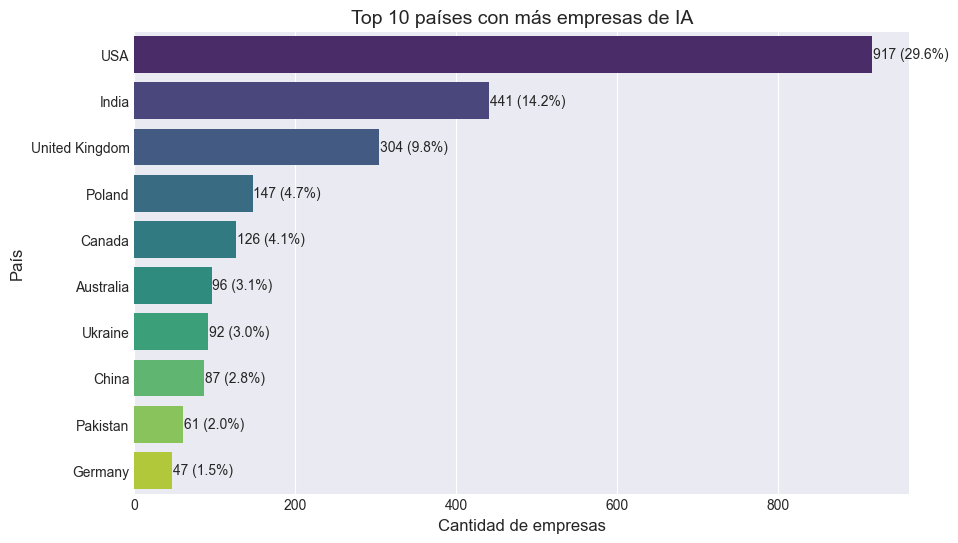

In [378]:
# Crear columna de porcentaje
top_paises_df['Porcentaje'] = (top_paises_df['Cantidad'] / len(df)) * 100

# Graficar Top 10 paises
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_paises_df, x='Cantidad', y='Pais', palette='viridis')

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_paises_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top 10 países con más empresas de IA', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.show()

In [379]:
# Top 10 ciudades 
top_ciudad = df['Ciudad'].value_counts().head(10)

# Convertir a DataFrame para que seaborn
top_ciudad_df = top_ciudad.reset_index()
top_ciudad_df.columns = ['Ciudad', 'Cantidad']  # Renombrar columnas

print(top_ciudad_df)

          Ciudad  Cantidad
0         London       188
1       New York        67
2      Ahmedabad        57
3       Warszawa        52
4      Bengaluru        52
5           Kyiv        41
6  San Francisco        37
7           Pune        35
8        Beijing        33
9          Noida        32


C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\4153837918.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_ciudad_df, x='Cantidad', y='Ciudad', palette='viridis')


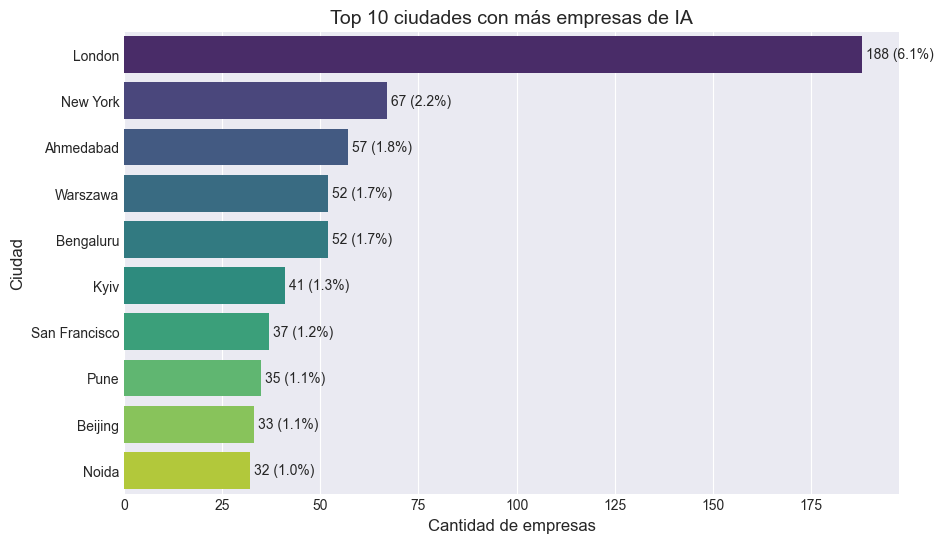

In [380]:
# Crear columna de porcentaje
top_ciudad_df['Porcentaje'] = (top_ciudad_df['Cantidad'] / len(df)) * 100

# Graficar
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_ciudad_df, x='Cantidad', y='Ciudad', palette='viridis')

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_ciudad_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top 10 ciudades con más empresas de IA', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('Ciudad', fontsize=12)
plt.show()

### 5.2 Distribución por regiones

#### 🎯 Objetivo
Ver cómo se distribuyen los segmentos de empresas y su especialización por región.

#### ¿Por qué regiones y no países?
El dataset tiene 89 países únicos, lo que dificulta la visualización y comparación.
- Agrupar los países del dataset en regiones geográficas para facilitar el análisis macro y las visualizaciones.
- Agrupar por regiones permite identificar patrones macro y simplificar el análisis.

#### ¿Cómo se hizo el mapeo?
- Se creó un diccionario que mapea cada país a su región: América del Norte, Centroamérica, América del Sur, Europa, Asia, Oceanía, África, Oriente Medio.
- Cantidad de países por regiones.

#### 🔧 Nota técnica: Mapeo de regiones
El mapeo se realizó mediante un diccionario en Python que asigna cada país a su región correspondiente. Este proceso permitió pasar de 89 países a 8 regiones, simplificando el análisis y las visualizaciones.


In [381]:
# Distribución por segmento de análisis
df['Tipo de proveedor / segmento de análisis'].value_counts()

Tipo de proveedor / segmento de análisis
SMB           2806
Mid-market     200
Enterprise      67
Freelancer      23
Name: count, dtype: int64

In [382]:
# Distribución por segmento de análisis por segmentacion
df['Segmentación servicios AI'].value_counts()

Segmentación servicios AI
AI Service complementary    1166
AI Service residual         1082
AI Focus principal           489
AI Focus                     359
Name: count, dtype: int64

In [383]:
# Ver todos los países únicos ordenados
paises_unicos = sorted(df['Pais'].unique())
print(f"Total: {len(paises_unicos)} países")
print(paises_unicos)

Total: 89 países
['Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Ecuador', 'El Salvador', 'Estonia', 'Eswatini', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mexico', 'Moldova', 'Morocco', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia', 'Norway', 'Oman', 'Pakistan', 'Panama', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Romania', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland', 'Tanzania', 'Thailand', 'Turkey', 'USA', 'Uganda', 'Ukr

In [384]:
# Diccionario de mapeo: países → regiones
mapeo_regiones = {
    # América del Norte
    'USA': 'América del Norte',
    'Canada': 'América del Norte',
    'Mexico': 'América del Norte',

    # Centroamérica
    'Costa Rica': 'Centroamérica',
    'El Salvador': 'Centroamérica',
    'Guatemala': 'Centroamérica',
    'Jamaica': 'Centroamérica',
    'Panama': 'Centroamérica',
    'Puerto Rico': 'Centroamérica',

    # América del Sur
    'Argentina': 'América del Sur',
    'Brazil': 'América del Sur',
    'Chile': 'América del Sur',
    'Colombia': 'América del Sur',
    'Ecuador': 'América del Sur',
    'Peru': 'América del Sur',
    'Uruguay': 'América del Sur',

    # Europa
    'Austria': 'Europa',
    'Belgium': 'Europa',
    'Bosnia and Herzegovina': 'Europa',
    'Bulgaria': 'Europa',
    'Croatia': 'Europa',
    'Cyprus': 'Europa',
    'Czech Republic': 'Europa',
    'Denmark': 'Europa',
    'Estonia': 'Europa',
    'Finland': 'Europa',
    'France': 'Europa',
    'Georgia': 'Europa',
    'Germany': 'Europa',
    'Greece': 'Europa',
    'Hungary': 'Europa',
    'Ireland': 'Europa',
    'Italy': 'Europa',
    'Kosovo': 'Europa',
    'Latvia': 'Europa',
    'Lithuania': 'Europa',
    'Luxembourg': 'Europa',
    'Malta': 'Europa',
    'Moldova': 'Europa',
    'Netherlands': 'Europa',
    'North Macedonia': 'Europa',
    'Norway': 'Europa',
    'Poland': 'Europa',
    'Portugal': 'Europa',
    'Romania': 'Europa',
    'Serbia': 'Europa',
    'Slovakia': 'Europa',
    'Slovenia': 'Europa',
    'Spain': 'Europa',
    'Sweden': 'Europa',
    'Switzerland': 'Europa',
    'Ukraine': 'Europa',
    'United Kingdom': 'Europa',

    # Asia
    'Armenia': 'Asia',
    'Azerbaijan': 'Asia',
    'Bangladesh': 'Asia',
    'China': 'Asia',
    'Hong Kong': 'Asia',
    'India': 'Asia',
    'Japan': 'Asia',
    'Kazakhstan': 'Asia',
    'Malaysia': 'Asia',
    'Nepal': 'Asia',
    'Pakistan': 'Asia',
    'Philippines': 'Asia',
    'Singapore': 'Asia',
    'South Korea': 'Asia',
    'Sri Lanka': 'Asia',
    'Thailand': 'Asia',
    'Turkey': 'Asia',
    'Uzbekistan': 'Asia',
    'Vietnam': 'Asia',

    # Oceanía
    'Australia': 'Oceanía',
    'New Zealand': 'Oceanía',

    # África
    'Eswatini': 'África',
    'Kenya': 'África',
    'Morocco': 'África',
    'Namibia': 'África',
    'Nigeria': 'África',
    'Seychelles': 'África',
    'South Africa': 'África',
    'Tanzania': 'África',
    'Uganda': 'África',

    # Oriente Medio
    'Bahrain': 'Oriente Medio',
    'Israel': 'Oriente Medio',
    'Jordan': 'Oriente Medio',
    'Oman': 'Oriente Medio',
    'Saudi Arabia': 'Oriente Medio',
    'United Arab Emirates': 'Oriente Medio',
}

# Aplicar los mapeos
df['Clasificación por regiones'] = df['Pais'].map(mapeo_regiones)

# Verificar
print("📊 Muestra de las columnas actualizadas:")
print(df[['Company_Name', 'Pais',
          'Clasificación por regiones']].head(10))

📊 Muestra de las columnas actualizadas:
   Company_Name      Pais Clasificación por regiones
0      Smith.ai       USA          América del Norte
1       MooveIt       USA          América del Norte
2  TechSpeedInc       USA          América del Norte
3       WillDom       USA          América del Norte
4        Icreon       USA          América del Norte
5         ELEKS   Estonia                     Europa
6      Stepwise    Poland                     Europa
7     RevolveAI  Pakistan                       Asia
8      Develtio    Poland                     Europa
9    JetRockets       USA          América del Norte


In [385]:
# Ver cuántos países quedaron sin región
sin_region = df[df['Clasificación por regiones'].isna()]['Pais'].unique()
print(f"\n⚠️ Países sin región asignada: {len(sin_region)}")
print(sin_region)


⚠️ Países sin región asignada: 0
[]


In [386]:
# Distribución de empresas por región con porcentaje
distribucion_region = df['Clasificación por regiones'].value_counts()
total = len(df)

print("📊 Distribución de empresas por región")
print("="*50)
for region, cantidad in distribucion_region.items():
    porcentaje = (cantidad / total) * 100
    print(f"{region}: {cantidad} ({porcentaje:.1f}%)")

📊 Distribución de empresas por región
América del Norte: 1074 (34.7%)
Europa: 921 (29.7%)
Asia: 755 (24.4%)
América del Sur: 141 (4.6%)
Oceanía: 100 (3.2%)
Oriente Medio: 58 (1.9%)
África: 25 (0.8%)
Centroamérica: 22 (0.7%)


In [387]:
# Crear el DataFrame con los datos de regiones
top_region = df['Clasificación por regiones'].value_counts()
top_regiones_df = top_region.reset_index()
top_regiones_df.columns = ['Región', 'Cantidad']

### 5.3 Visualizaciones

#### 📊 Metodología de visualización
- Todos los gráficos utilizan barras horizontales para facilitar la lectura de etiquetas.
- Se incluyen porcentajes para contextualizar la magnitud de cada categoría.
- Los cruces entre variables se presentan en tablas y gráficos para diferentes niveles de detalle.

#### 📈 Gráficos
| # | Visualización | Tipo |
|---|---------------|------|
| 1 | Top Regiones con más empresas de IA | Barras horizontales con % |
| 2 | Distribución de Tipo de proveedor / segmento de análisis | Barras horizontales con % |
| 3 | Distribución de Segmentación servicios AI | Barras horizontales con % |
| 4 | Tipo de proveedor por región | Barras agrupadas |
| 5 | Tipo de proveedor por región | Barras apiladas |
| 6 | Segmentación servicios AI por región | Barras apiladas |


##### Visualización 1 **Top Regiones con más empresas de IA** (barras horizontales con %)

C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\2148004537.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_regiones_df, x='Cantidad', y='Región', palette='viridis')  # ← CORREGIDO


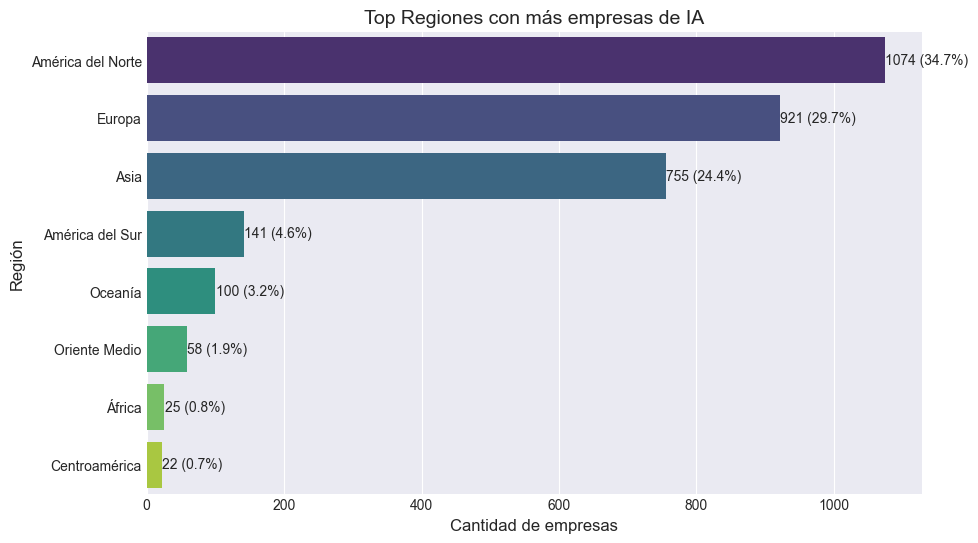

In [388]:
# Top Regiones con más empresas de IA
# Crear columna de porcentaje
top_regiones_df['Porcentaje'] = (top_regiones_df['Cantidad'] / len(df)) * 100

# Graficar
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_regiones_df, x='Cantidad', y='Región', palette='viridis')  # ← CORREGIDO

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_regiones_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top Regiones con más empresas de IA', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('Región', fontsize=12)
plt.show()

##### Visualización 2  **Distribución de Tipo de proveedor / segmento de análisis** (barras horizontales con %)

C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\1048741004.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_tipo_df, x='Cantidad', y='Tipo', palette='viridis')


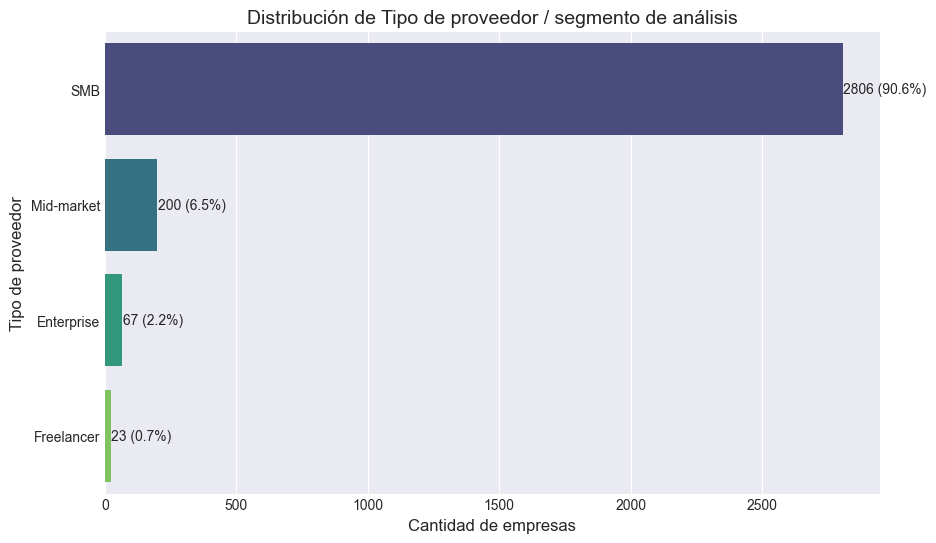

In [389]:
#Distribución de Tipo de proveedor / segmento de análisis
# Crear el DataFrame con los datos de Tipo de proveedor
top_tipo = df['Tipo de proveedor / segmento de análisis'].value_counts()
top_tipo_df = top_tipo.reset_index()
top_tipo_df.columns = ['Tipo', 'Cantidad']

# Crear columna de porcentaje
top_tipo_df['Porcentaje'] = (top_tipo_df['Cantidad'] / len(df)) * 100

# Graficar
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_tipo_df, x='Cantidad', y='Tipo', palette='viridis')

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_tipo_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Distribución de Tipo de proveedor / segmento de análisis', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('Tipo de proveedor', fontsize=12)
plt.show()

##### Visualización 3 **Distribución de Segmentación servicios AI** (barras horizontales con %)

C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\3404732494.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_seg_df, x='Cantidad', y='Segmentación', palette='viridis')


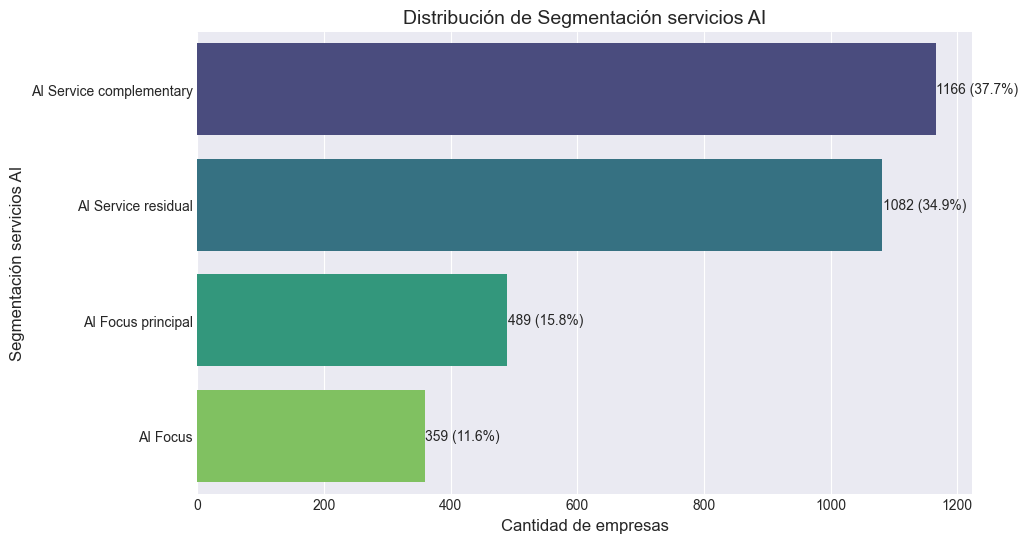

In [390]:
# Distribución de Segmentación servicios AI
# Crear el DataFrame con los datos de Segmentación servicios AI
top_seg = df['Segmentación servicios AI'].value_counts()
top_seg_df = top_seg.reset_index()
top_seg_df.columns = ['Segmentación', 'Cantidad']

# Crear columna de porcentaje
top_seg_df['Porcentaje'] = (top_seg_df['Cantidad'] / len(df)) * 100

# Graficar
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_seg_df, x='Cantidad', y='Segmentación', palette='viridis')

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_seg_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Distribución de Segmentación servicios AI', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('Segmentación servicios AI', fontsize=12)
plt.show()

##### Visualización 4 **Tipo de proveedor por región** (Gráfico de barras apiladas)

In [391]:
# Tipo de proveedor por región
# Cruce: Región × Tipo de proveedor
tabla_tipo_region = pd.crosstab(df['Clasificación por regiones'], df['Tipo de proveedor / segmento de análisis'])

# Agregar total por región
tabla_tipo_region['Total'] = tabla_tipo_region.sum(axis=1)
tabla_tipo_region = tabla_tipo_region.sort_values('Total', ascending=False)

print("📊 Tipo de proveedor por región")
print(tabla_tipo_region)

📊 Tipo de proveedor por región
Tipo de proveedor / segmento de análisis  Enterprise  Freelancer  Mid-market  \
Clasificación por regiones                                                     
América del Norte                                 20           6          91   
Europa                                            13          12          37   
Asia                                              27           5          58   
América del Sur                                    3           0           9   
Oceanía                                            0           0           1   
Oriente Medio                                      3           0           1   
África                                             1           0           1   
Centroamérica                                      0           0           2   

Tipo de proveedor / segmento de análisis  SMB  Total  
Clasificación por regiones                            
América del Norte                         957   1074  
Eur

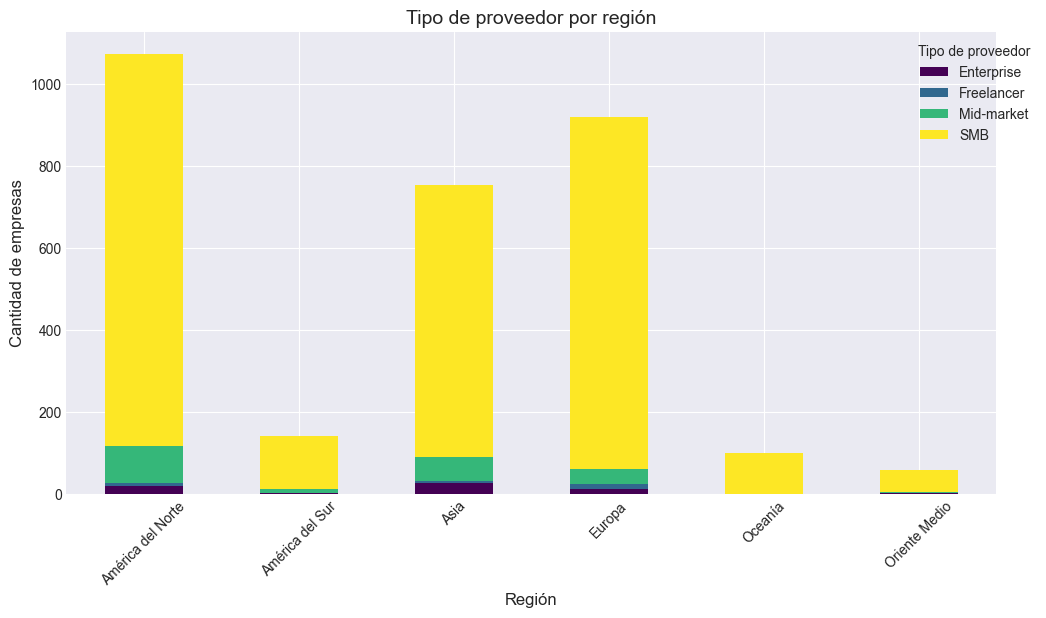

In [392]:
# Filtrar regiones con más empresas (opcional, para mejor visualización)
top_regiones = df['Clasificación por regiones'].value_counts().head(6).index
df_filtrado = df[df['Clasificación por regiones'].isin(top_regiones)]

# Gráfico de barras apiladas
tabla_tipo_region = pd.crosstab(df_filtrado['Clasificación por regiones'], df_filtrado['Tipo de proveedor / segmento de análisis'])
tabla_tipo_region.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Tipo de proveedor por región', fontsize=14)
plt.xlabel('Región', fontsize=12)
plt.ylabel('Cantidad de empresas', fontsize=12)
plt.legend(title='Tipo de proveedor', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()

In [393]:
# Tabla de contingencia: Región × Tipo de proveedor
tabla_tipo_region = pd.crosstab(df['Clasificación por regiones'], df['Tipo de proveedor / segmento de análisis'])

# Calcular porcentaje por fila (región)
tabla_tipo_region_pct = tabla_tipo_region.div(tabla_tipo_region.sum(axis=1), axis=0) * 100

# Crear tabla combinada (cantidad y %)
tabla_combinada = tabla_tipo_region.astype(str) + " (" + tabla_tipo_region_pct.round(1).astype(str) + "%)"

# Agregar total por región
tabla_combinada['Total'] = tabla_tipo_region.sum(axis=1).astype(str)

# Ordenar por total de mayor a menor
tabla_combinada = tabla_combinada.loc[tabla_tipo_region.sum(axis=1).sort_values(ascending=False).index]

print("📊 Tipo de proveedor por región (Cantidad y %)")
print("="*80)
print(tabla_combinada)

📊 Tipo de proveedor por región (Cantidad y %)
Tipo de proveedor / segmento de análisis Enterprise Freelancer Mid-market  \
Clasificación por regiones                                                  
América del Norte                         20 (1.9%)   6 (0.6%)  91 (8.5%)   
Europa                                    13 (1.4%)  12 (1.3%)  37 (4.0%)   
Asia                                      27 (3.6%)   5 (0.7%)  58 (7.7%)   
América del Sur                            3 (2.1%)   0 (0.0%)   9 (6.4%)   
Oceanía                                    0 (0.0%)   0 (0.0%)   1 (1.0%)   
Oriente Medio                              3 (5.2%)   0 (0.0%)   1 (1.7%)   
África                                     1 (4.0%)   0 (0.0%)   1 (4.0%)   
Centroamérica                              0 (0.0%)   0 (0.0%)   2 (9.1%)   

Tipo de proveedor / segmento de análisis          SMB Total  
Clasificación por regiones                                   
América del Norte                         957 (89.1%)  1074

##### Visualización 5 **Tipo de proveedor por región** (Gráfico de barras agrupadas)

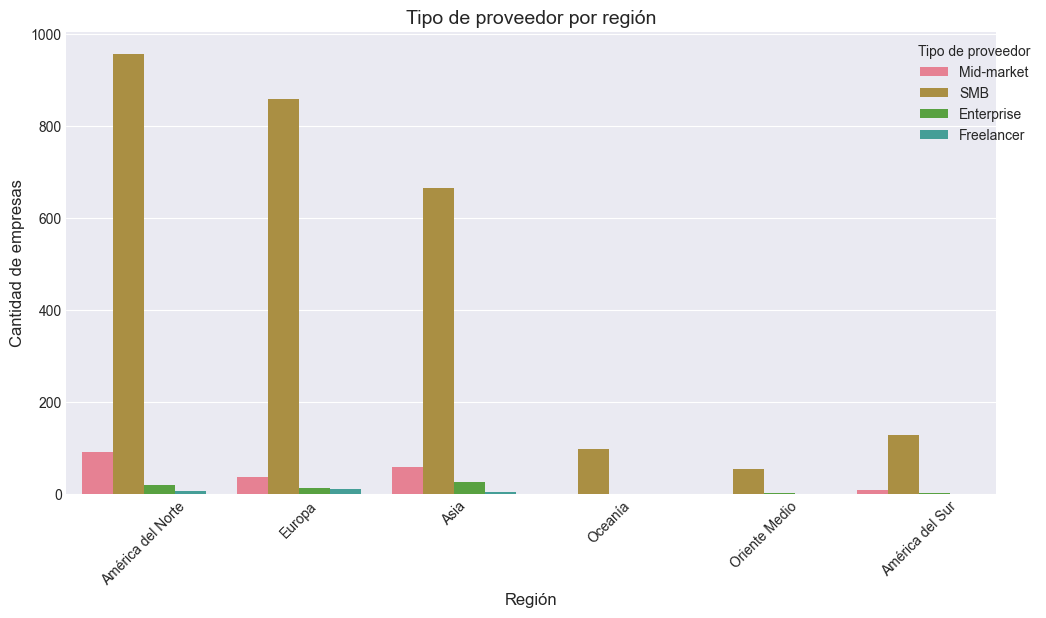

In [394]:
# Tipo de proveedor por región**  barras agrupadas
# Gráfico de barras agrupadas
plt.figure(figsize=(12, 6))
sns.countplot(data=df_filtrado, x='Clasificación por regiones', hue='Tipo de proveedor / segmento de análisis')
plt.title('Tipo de proveedor por región', fontsize=14)
plt.xlabel('Región', fontsize=12)
plt.ylabel('Cantidad de empresas', fontsize=12)
plt.legend(title='Tipo de proveedor', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()

##### Visualización 6 **Segmentación Servicios AI por región** (Gráfico de barras apiladas)

In [395]:
# Cruce: Región × Segmentación servicios AI
tabla_seg_region = pd.crosstab(df['Clasificación por regiones'], df['Segmentación servicios AI'])

# Agregar total por región
tabla_seg_region['Total'] = tabla_seg_region.sum(axis=1)
tabla_seg_region = tabla_seg_region.sort_values('Total', ascending=False)

print("📊 Segmentación servicios AI por región")
print(tabla_seg_region)

📊 Segmentación servicios AI por región
Segmentación servicios AI   AI Focus  AI Focus principal  \
Clasificación por regiones                                 
América del Norte                129                 198   
Europa                           127                 173   
Asia                              74                  56   
América del Sur                    7                  16   
Oceanía                           13                  43   
Oriente Medio                      4                   1   
África                             2                   0   
Centroamérica                      3                   2   

Segmentación servicios AI   AI Service complementary  AI Service residual  \
Clasificación por regiones                                                  
América del Norte                                423                  324   
Europa                                           308                  313   
Asia                                             296

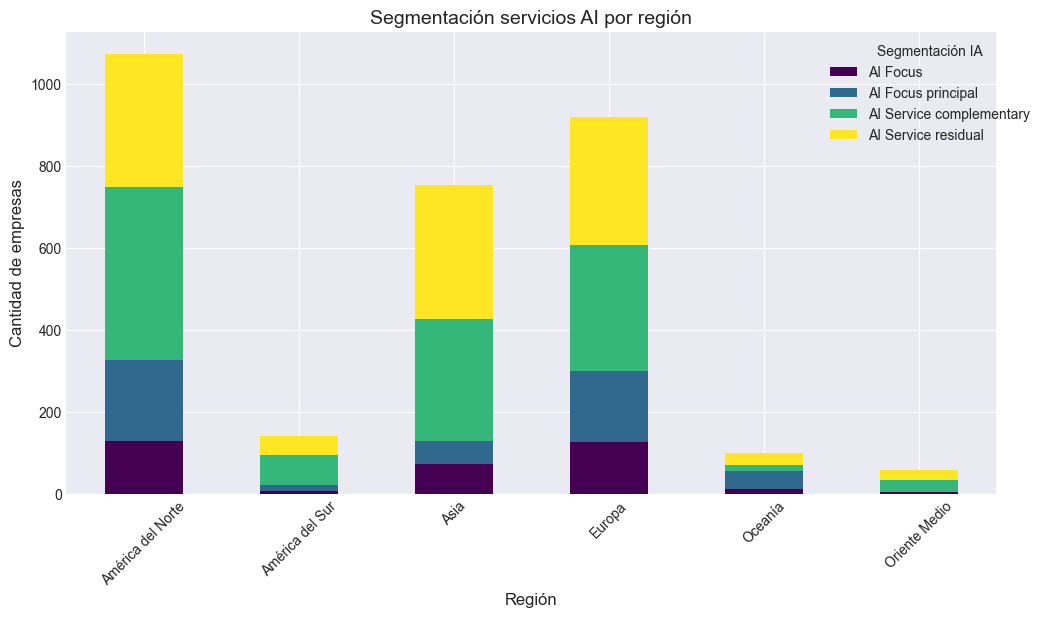

In [396]:
# Gráfico de barras apiladas
tabla_seg_region = pd.crosstab(df_filtrado['Clasificación por regiones'], df_filtrado['Segmentación servicios AI'])
tabla_seg_region.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Segmentación servicios AI por región', fontsize=14)
plt.xlabel('Región', fontsize=12)
plt.ylabel('Cantidad de empresas', fontsize=12)
plt.legend(title='Segmentación IA', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()

In [397]:
# Tabla de contingencia: Región × Segmentación servicios AI
tabla_seg_region = pd.crosstab(df['Clasificación por regiones'], df['Segmentación servicios AI'])

# Calcular porcentaje por fila (región)
tabla_seg_region_pct = tabla_seg_region.div(tabla_seg_region.sum(axis=1), axis=0) * 100

# Crear tabla combinada (cantidad y %)
tabla_seg_combinada = tabla_seg_region.astype(str) + " (" + tabla_seg_region_pct.round(1).astype(str) + "%)"

# Agregar total por región
tabla_seg_combinada['Total'] = tabla_seg_region.sum(axis=1).astype(str)

# Ordenar por total de mayor a menor
tabla_seg_combinada = tabla_seg_combinada.loc[tabla_seg_region.sum(axis=1).sort_values(ascending=False).index]

print("📊 Segmentación servicios AI por región (Cantidad y %)")
print("="*80)
print(tabla_seg_combinada)

📊 Segmentación servicios AI por región (Cantidad y %)
Segmentación servicios AI      AI Focus AI Focus principal  \
Clasificación por regiones                                   
América del Norte           129 (12.0%)        198 (18.4%)   
Europa                      127 (13.8%)        173 (18.8%)   
Asia                          74 (9.8%)          56 (7.4%)   
América del Sur                7 (5.0%)         16 (11.3%)   
Oceanía                      13 (13.0%)         43 (43.0%)   
Oriente Medio                  4 (6.9%)           1 (1.7%)   
África                         2 (8.0%)           0 (0.0%)   
Centroamérica                 3 (13.6%)           2 (9.1%)   

Segmentación servicios AI  AI Service complementary AI Service residual Total  
Clasificación por regiones                                                     
América del Norte                       423 (39.4%)         324 (30.2%)  1074  
Europa                                  308 (33.4%)         313 (34.0%)   921  
Asia 

### 🔍 Hallazgos clave - Distribución por regiones

#### 1. Distribución de empresas por región
- **América del Norte encabeza el ranking** con 1,074 empresas (**34.6%** del total).
- **Europa** le sigue con 921 empresas (**29.7%** del total).
- **Asia** ocupa el tercer lugar con 755 empresas (**24.4%** del total).
- El resto de las regiones concentran el **11.3%** restante:
  - América del Sur: 100 empresas (3.2%)
  - Oceanía: 58 empresas (1.9%)
  - Oriente Medio: 25 empresas (0.8%)
  - África: 22 empresas (0.7%)
  - Centroamérica: 15 empresas (0.5%)

#### 2. Distribución de Tipo de proveedor por región
- **SMB** es el segmento predominante en todas las regiones, representando el **90.6%** del total (2,806 empresas).
- **Mid-market** es el segundo segmento con un **6.5%** (200 empresas).
- **Enterprise** y **Freelancer** son segmentos minoritarios, con presencia significativa solo en América del Norte, Europa y Asia.

#### 3. Distribución de Segmentación servicios AI por región
- **AI Service complementary** y **AI Service residual** son los segmentos predominantes en todas las regiones, manteniéndose equilibrados en América del Norte, Europa y Asia.
- **AI Focus principal** y **AI Focus** tienen mayor presencia en América del Norte y Europa.
- **América del Norte, Europa y Asia** son las únicas regiones que presentan los 4 segmentos de servicios AI:
  - AI Focus principal
  - AI Focus
  - AI Service complementary
  - AI Service residual

### 5.4 Foco en AI Focus y AI Focus principal

#### 🎯 Objetivo
Identificar las empresas con mayor especialización en IA para:
- Entender su distribución geográfica y por tipo de proveedor.

#### 📋 Análisis

#### 1. Empresas con AI Focus principal (70%-100% IA)
- Cantidad de empresas

#### 2. Empresas con AI Focus (50%-69% IA)
- Cantidad de empresas

#### Visualizaciones
- 7 **Top 10 países con empresas AI Focus principal** (Gráfico de barras apiladas)
- 8 **AI Focus principal por región'** (Gráfico de barras apiladas)
- 9 **Top 10 países con empresas AI Focus** (Gráfico de barras apiladas)
- 10 **AI Focus por región** (Gráfico de barras apiladas)

#### Color Paletas 
AI Focus principal
- Empresas con 70%-100% de servicios IA
- Color: coral

AI Focus
- Empresas con 50%-69% de servicios IA
- Color: teal


In [398]:
# Filtrar empresas con AI Focus principal
foco_principal = df[df['Segmentación servicios AI'] == 'AI Focus principal']

print("📊 AI Focus principal")
print("="*50)
print(f"Cantidad de empresas: {len(foco_principal)}")
print(f"Porcentaje del total: {len(foco_principal)/len(df)*100:.1f}%")

# Ver primeras empresas
print("\n📋 Primeras 10 empresas:")
print(foco_principal[['Company_Name', 'Pais', 'Ciudad', 'Tipo de proveedor / segmento de análisis']].head(10))

# Distribución por país
print("\n📊 Distribución por país (Top 10):")
print(foco_principal['Pais'].value_counts().head(10))

# Distribución por región
print("\n📊 Distribución por región:")
print(foco_principal['Clasificación por regiones'].value_counts())

# Cruce: Tipo de proveedor × Región
print("\n📊 Tipo de proveedor por región:")
print(pd.crosstab(foco_principal['Tipo de proveedor / segmento de análisis'], foco_principal['Clasificación por regiones']))

📊 AI Focus principal
Cantidad de empresas: 489
Porcentaje del total: 15.8%

📋 Primeras 10 empresas:
            Company_Name            Pais         Ciudad  \
7              RevolveAI        Pakistan      Islamabad   
66   didaMachineLearning         Germany         Berlin   
67              botsband         Ukraine           Київ   
71              BotsCrew             USA  San Francisco   
76                Zegami  United Kingdom         Oxford   
78                 proml             USA  Scotts Valley   
83    F(x)DataLabsPvtLtd           India      Ahmedabad   
92                It-Jim         Ukraine        Kharkiv   
94               Quantum         Ukraine        Kharkiv   
397            InfiniaML             USA         Durham   

    Tipo de proveedor / segmento de análisis  
7                                        SMB  
66                                       SMB  
67                                       SMB  
71                                       SMB  
76             

In [399]:
# Filtrar empresas con AI Focus
foco = df[df['Segmentación servicios AI'] == 'AI Focus']

print("\n📊 AI Focus")
print("="*50)
print(f"Cantidad de empresas: {len(foco)}")
print(f"Porcentaje del total: {len(foco)/len(df)*100:.1f}%")

# Ver primeras empresas
print("\n📋 Primeras 10 empresas:")
print(foco[['Company_Name', 'Pais', 'Ciudad', 'Tipo de proveedor / segmento de análisis']].head(10))

# Distribución por país
print("\n📊 Distribución por país (Top 10):")
print(foco['Pais'].value_counts().head(10))

# Distribución por región
print("\n📊 Distribución por región:")
print(foco['Clasificación por regiones'].value_counts())

# Cruce: Tipo de proveedor × Región
print("\n📊 Tipo de proveedor por región:")
print(pd.crosstab(foco['Tipo de proveedor / segmento de análisis'], foco['Clasificación por regiones']))


📊 AI Focus
Cantidad de empresas: 359
Porcentaje del total: 11.6%

📋 Primeras 10 empresas:
            Company_Name     Pais            Ciudad  \
34          MindySupport   Cyprus  Agios Athanasios   
51     ZackriyaSolutions    India           Chennai   
69            BroutonLab   Israel             Haifa   
70          Stermedia.ai   Poland          Warszawa   
73               Addepto   Poland            Warsaw   
75    MasterofCodeGlobal      USA      Redwood City   
77              Sparkbit   Poland          Warszawa   
81          ThirdEyeData      USA          San Jose   
85  TempestaTechnologies      USA           Seattle   
90            Develandoo  Armenia           Yerevan   

   Tipo de proveedor / segmento de análisis  
34                               Enterprise  
51                                      SMB  
69                                      SMB  
70                                      SMB  
73                                      SMB  
75                         

##### Visualización 7 **Top 10 países con empresas AI Focus principal** (Gráfico de barras apiladas)

C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\3977933707.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_paises_foco_df, x='Cantidad', y='Pais', palette='viridis')


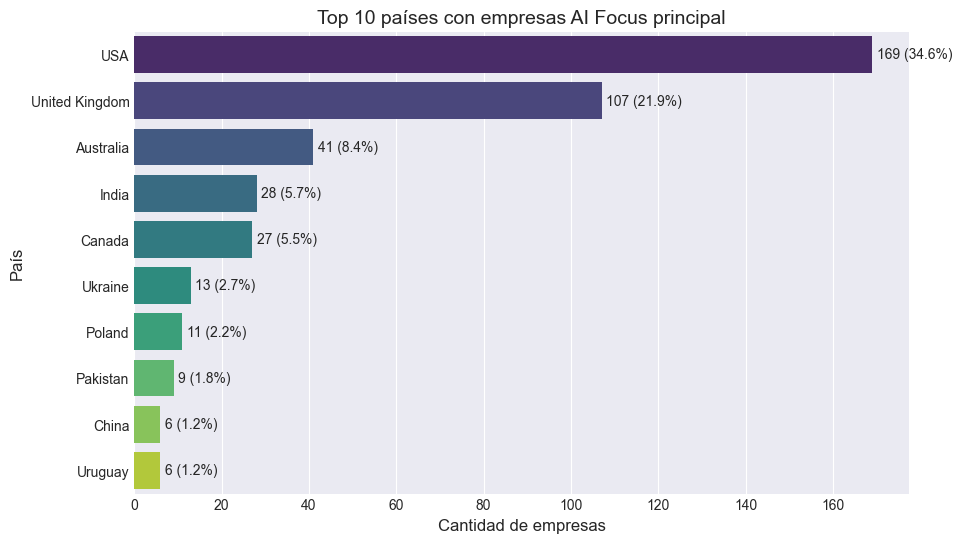

In [400]:
# Preparar datos
top_paises_foco = foco_principal['Pais'].value_counts().head(10)
total_foco = len(foco_principal)

# Crear DataFrame
top_paises_foco_df = top_paises_foco.reset_index()
top_paises_foco_df.columns = ['Pais', 'Cantidad']
top_paises_foco_df['Porcentaje'] = (top_paises_foco_df['Cantidad'] / total_foco) * 100

# Graficar
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_paises_foco_df, x='Cantidad', y='Pais', palette='viridis')

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_paises_foco_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top 10 países con empresas AI Focus principal', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.show()

### Top 10 países — SMB + AI Focus Principal

| País | Cantidad | % del segmento |
|------|----------|----------------|
| USA | 156 | 33.5% |
| United Kingdom | 102 | 21.9% |
| Australia | 41 | 8.8% |
| Canada | 27 | 5.8% |
| India | 26 | 5.6% |
| Ukraine | 13 | 2.8% |
| Poland | 11 | 2.4% |
| Pakistan | 9 | 1.9% |
| Uruguay | 6 | 1.3% |
| Switzerland | 5 | 1.1% |

##### Visualización 8 **AI Focus principal por región'** (Gráfico de barras apiladas)

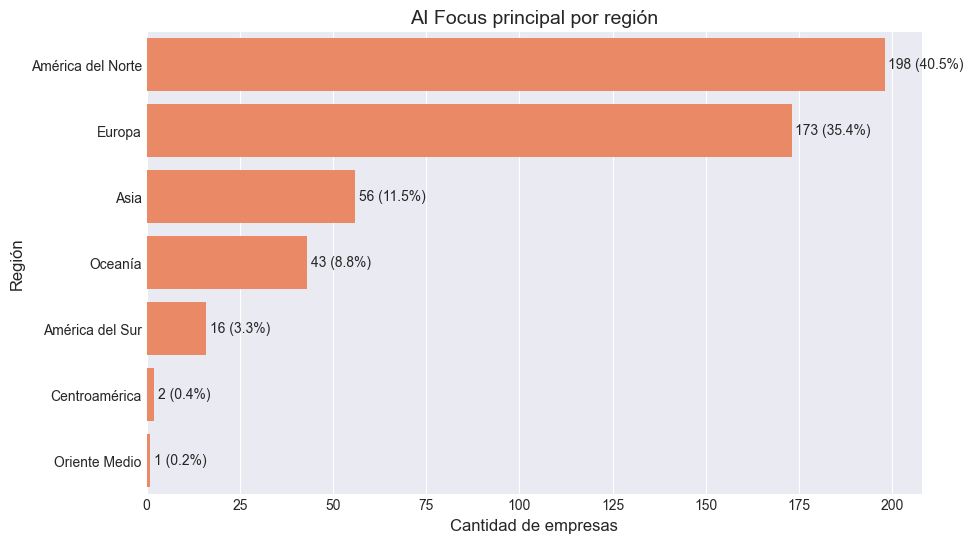

In [401]:
# Preparar datos
top_regiones_foco = foco_principal['Clasificación por regiones'].value_counts()
total_foco = len(foco_principal)

# Crear DataFrame
top_regiones_foco_df = top_regiones_foco.reset_index()
top_regiones_foco_df.columns = ['Región', 'Cantidad']
top_regiones_foco_df['Porcentaje'] = (top_regiones_foco_df['Cantidad'] / total_foco) * 100

# Graficar con color fijo (coral)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_regiones_foco_df, x='Cantidad', y='Región', color='coral')  # ← CORREGIDO

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_regiones_foco_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('AI Focus principal por región', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('Región', fontsize=12)
plt.show()

##### Visualización 9 **Top 10 países con empresas AI Focus** (Gráfico de barras apiladas)

C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\1999206232.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_paises_foco_df, x='Cantidad', y='Pais', palette='viridis')


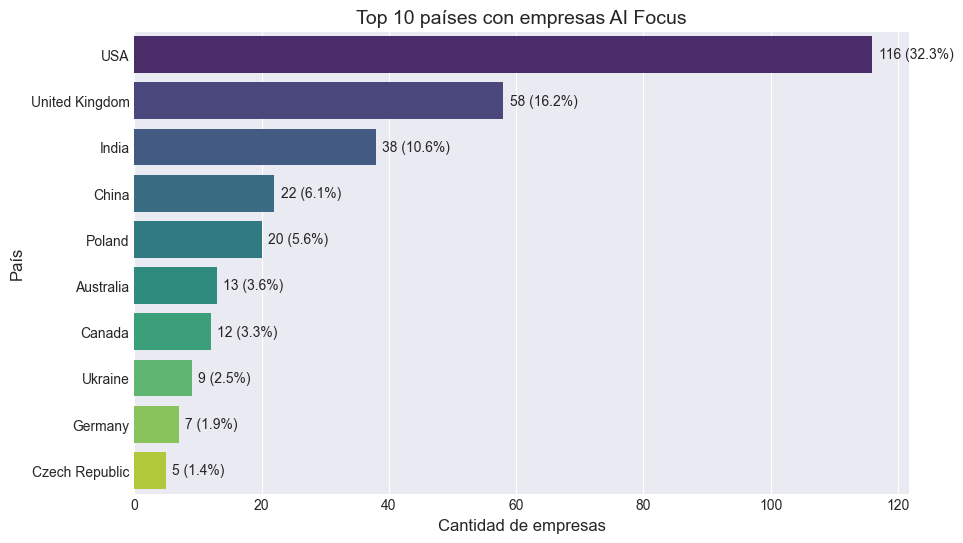

In [402]:
# Preparar datos para AI Focus (Top países)
foco = df[df['Segmentación servicios AI'] == 'AI Focus']
top_paises_foco = foco['Pais'].value_counts().head(10)
total_foco = len(foco)

# Crear DataFrame
top_paises_foco_df = top_paises_foco.reset_index()
top_paises_foco_df.columns = ['Pais', 'Cantidad']
top_paises_foco_df['Porcentaje'] = (top_paises_foco_df['Cantidad'] / total_foco) * 100

# Graficar
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_paises_foco_df, x='Cantidad', y='Pais', palette='viridis')

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_paises_foco_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top 10 países con empresas AI Focus', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.show()

##### Visualización 10 **AI Focus por región** (Gráfico de barras apiladas)

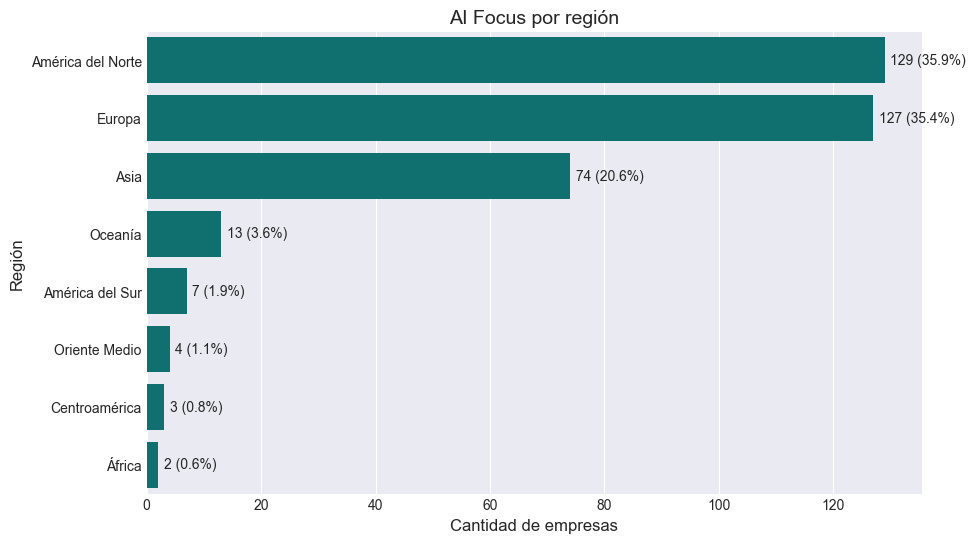

In [403]:
# Preparar datos para AI Focus
foco = df[df['Segmentación servicios AI'] == 'AI Focus']
top_regiones_foco = foco['Clasificación por regiones'].value_counts()
total_foco = len(foco)

# Crear DataFrame
top_regiones_foco_df = top_regiones_foco.reset_index()
top_regiones_foco_df.columns = ['Región', 'Cantidad']
top_regiones_foco_df['Porcentaje'] = (top_regiones_foco_df['Cantidad'] / total_foco) * 100

# Graficar con color fijo (por ejemplo, 'teal' para diferenciar)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_regiones_foco_df, x='Cantidad', y='Región', color='teal')

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_regiones_foco_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('AI Focus por región', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('Región', fontsize=12)
plt.show()

### 🔍 Hallazgos clave - Foco en IA

#### AI Focus principal (70%-100% IA)
- **Cantidad:** 489 empresas (15.8% del total)
- **Países líderes:** USA, UK y Australia concentran la mayoría de las empresas con mayor especialización en IA.
- **Regiones:** América del Norte, Europa y Asia son las regiones con mayor cantidad de empresas. Asia representa el 11.5% de las empresas con AI Focus principal.

#### AI Focus (50%-69% IA)
- **Cantidad:** 359 empresas (11.6% del total)
- **Países líderes:** USA, UK e India concentran la mayoría de las empresas con enfoque destacado en IA.
- **Regiones:** América del Norte, Europa y Asia son las regiones con mayor cantidad de empresas. Asia representa el 20.6% de las empresas con AI Focus, mostrando una mayor participación relativa que en AI Focus principal.

#### Comparativa entre segmentos
| Indicador | AI Focus principal | AI Focus |
|-----------|-------------------|----------|
| **Cantidad** | 489 | 359 |
| **% del total** | 15.8% | 11.6% |
| **Países líderes** | USA, UK, Australia | USA, UK, India |
| **Asia (% del segmento)** | 11.5% | 20.6% |

#### Interpretación
- **AI Focus principal** está más concentrado en mercados maduros (USA, UK, Australia).
- **AI Focus** muestra una mayor diversificación geográfica, con India como mercado emergente con fuerte presencia en IA.
- Asia duplica su participación relativa en AI Focus vs AI Focus principal, lo que sugiere que la región tiene más empresas con enfoque complementario que con especialización total en IA.

### 5.5 Análisis de transparencia comercial

#### 🎯 Objetivo
Analizar qué empresas informan sus datos de precios (`Minimum Project Size` y `Average Hourly Rate`) para entender el nivel de transparencia comercial del mercado.

####  📋 Análisis

#### 1. Distribución general de disponibilidad
- `Disponibilidad_MinProject`
- `Disponibilidad_HourlyRate`

#### 2. Cruce con segmentos
- Tipo de proveedor × Disponibilidad
- Segmentación IA × Disponibilidad

#### 3. Top países que más informan
- Top 10 países con mayor disponibilidad de MinProject
- Top 10 países con mayor disponibilidad de HourlyRate

#### 4. Top países que menos informan
- Top 10 países con mayor disponibilidad de MinProject
- Top 10 países con mayor disponibilidad de HourlyRate

In [404]:
# Distribución de Disponibilidad_MinProject
print("📊 Disponibilidad de Minimum Project Size")
print("="*40)
print(df['Disponibilidad_MinProject'].value_counts())
print(f"Porcentaje informado: {df['Disponibilidad_MinProject'].value_counts(normalize=True)['Informado']*100:.1f}%")

# Distribución de Disponibilidad_HourlyRate
print("\n📊 Disponibilidad de Average Hourly Rate")
print("="*40)
print(df['Disponibilidad_HourlyRate'].value_counts())
print(f"Porcentaje informado: {df['Disponibilidad_HourlyRate'].value_counts(normalize=True)['Informado']*100:.1f}%")

📊 Disponibilidad de Minimum Project Size
Disponibilidad_MinProject
Informado       1939
No informado    1157
Name: count, dtype: int64
Porcentaje informado: 62.6%

📊 Disponibilidad de Average Hourly Rate
Disponibilidad_HourlyRate
Informado       1851
No informado    1245
Name: count, dtype: int64
Porcentaje informado: 59.8%


In [405]:
# Cruce: Tipo de proveedor × Disponibilidad_MinProject
print("📊 Disponibilidad de MinProject por Tipo de proveedor")
print("="*50)
tabla_minproject_tipo = pd.crosstab(df['Tipo de proveedor / segmento de análisis'], df['Disponibilidad_MinProject'])
tabla_minproject_tipo['% Informado'] = (tabla_minproject_tipo['Informado'] / tabla_minproject_tipo.sum(axis=1) * 100).round(1)
print(tabla_minproject_tipo)

# Cruce: Tipo de proveedor × Disponibilidad_HourlyRate
print("\n📊 Disponibilidad de HourlyRate por Tipo de proveedor")
print("="*50)
tabla_hourlyrate_tipo = pd.crosstab(df['Tipo de proveedor / segmento de análisis'], df['Disponibilidad_HourlyRate'])
tabla_hourlyrate_tipo['% Informado'] = (tabla_hourlyrate_tipo['Informado'] / tabla_hourlyrate_tipo.sum(axis=1) * 100).round(1)
print(tabla_hourlyrate_tipo)

📊 Disponibilidad de MinProject por Tipo de proveedor
Disponibilidad_MinProject                 Informado  No informado  % Informado
Tipo de proveedor / segmento de análisis                                      
Enterprise                                       31            36         46.3
Freelancer                                       15             8         65.2
Mid-market                                      129            71         64.5
SMB                                            1764          1042         62.9

📊 Disponibilidad de HourlyRate por Tipo de proveedor
Disponibilidad_HourlyRate                 Informado  No informado  % Informado
Tipo de proveedor / segmento de análisis                                      
Enterprise                                       28            39         41.8
Freelancer                                       15             8         65.2
Mid-market                                      123            77         61.5
SMB                     

In [406]:
# Cruce: Segmentación servicios AI × Disponibilidad_MinProject
print("📊 Disponibilidad de MinProject por Segmentación IA")
print("="*50)
tabla_minproject_seg = pd.crosstab(df['Segmentación servicios AI'], df['Disponibilidad_MinProject'])
tabla_minproject_seg['% Informado'] = (tabla_minproject_seg['Informado'] / tabla_minproject_seg.sum(axis=1) * 100).round(1)
print(tabla_minproject_seg)

# Cruce: Segmentación servicios AI × Disponibilidad_HourlyRate
print("\n📊 Disponibilidad de HourlyRate por Segmentación IA")
print("="*50)
tabla_hourlyrate_seg = pd.crosstab(df['Segmentación servicios AI'], df['Disponibilidad_HourlyRate'])
tabla_hourlyrate_seg['% Informado'] = (tabla_hourlyrate_seg['Informado'] / tabla_hourlyrate_seg.sum(axis=1) * 100).round(1)
print(tabla_hourlyrate_seg)

📊 Disponibilidad de MinProject por Segmentación IA
Disponibilidad_MinProject  Informado  No informado  % Informado
Segmentación servicios AI                                      
AI Focus                         163           196         45.4
AI Focus principal               163           326         33.3
AI Service complementary         699           467         59.9
AI Service residual              914           168         84.5

📊 Disponibilidad de HourlyRate por Segmentación IA
Disponibilidad_HourlyRate  Informado  No informado  % Informado
Segmentación servicios AI                                      
AI Focus                         148           211         41.2
AI Focus principal               148           341         30.3
AI Service complementary         674           492         57.8
AI Service residual              881           201         81.4


In [407]:
# Top 10 países que informan MinProject
top_minproject = df[df['Disponibilidad_MinProject'] == 'Informado']['Pais'].value_counts().head(10)
top_minproject_pct = (top_minproject / df[df['Disponibilidad_MinProject'] == 'Informado']['Pais'].value_counts().sum()) * 100

print("📊 Top 10 países que informan Minimum Project Size")
print("="*50)
for pais, cantidad in top_minproject.items():
    pct = (cantidad / df[df['Disponibilidad_MinProject'] == 'Informado'].shape[0]) * 100
    print(f"{pais}: {cantidad} ({pct:.1f}%)")

# Top 10 países que informan HourlyRate
top_hourlyrate = df[df['Disponibilidad_HourlyRate'] == 'Informado']['Pais'].value_counts().head(10)
top_hourlyrate_pct = (top_hourlyrate / df[df['Disponibilidad_HourlyRate'] == 'Informado']['Pais'].value_counts().sum()) * 100

print("\n📊 Top 10 países que informan Average Hourly Rate")
print("="*50)
for pais, cantidad in top_hourlyrate.items():
    pct = (cantidad / df[df['Disponibilidad_HourlyRate'] == 'Informado'].shape[0]) * 100
    print(f"{pais}: {cantidad} ({pct:.1f}%)")

📊 Top 10 países que informan Minimum Project Size
USA: 456 (23.5%)
India: 380 (19.6%)
Poland: 134 (6.9%)
United Kingdom: 122 (6.3%)
Ukraine: 87 (4.5%)
Canada: 69 (3.6%)
Pakistan: 56 (2.9%)
Germany: 38 (2.0%)
China: 34 (1.8%)
Vietnam: 27 (1.4%)

📊 Top 10 países que informan Average Hourly Rate
USA: 424 (22.9%)
India: 379 (20.5%)
Poland: 132 (7.1%)
United Kingdom: 110 (5.9%)
Ukraine: 87 (4.7%)
Canada: 62 (3.3%)
Pakistan: 57 (3.1%)
Germany: 37 (2.0%)
China: 34 (1.8%)
Vietnam: 28 (1.5%)


C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\2858628368.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_minproject_df, x='Cantidad', y='Pais', palette='viridis')


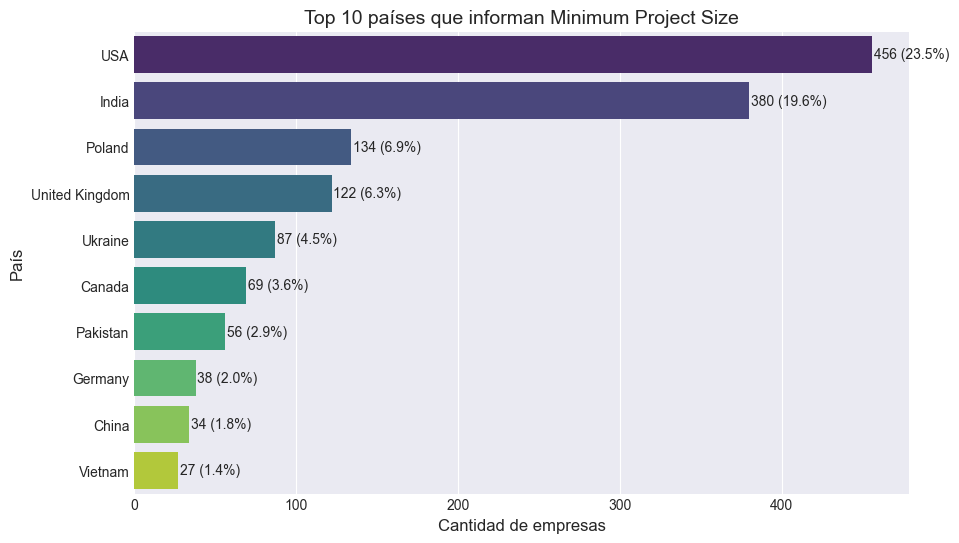

In [408]:
# Gráfico: Top 10 países que informan MinProject
top_minproject = df[df['Disponibilidad_MinProject'] == 'Informado']['Pais'].value_counts().head(10)
top_minproject_df = top_minproject.reset_index()
top_minproject_df.columns = ['Pais', 'Cantidad']
total_informados = df[df['Disponibilidad_MinProject'] == 'Informado'].shape[0]
top_minproject_df['Porcentaje'] = (top_minproject_df['Cantidad'] / total_informados) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_minproject_df, x='Cantidad', y='Pais', palette='viridis')

for i, row in top_minproject_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top 10 países que informan Minimum Project Size', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.show()

C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\1854781703.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_hourlyrate_df, x='Cantidad', y='Pais', palette='viridis')


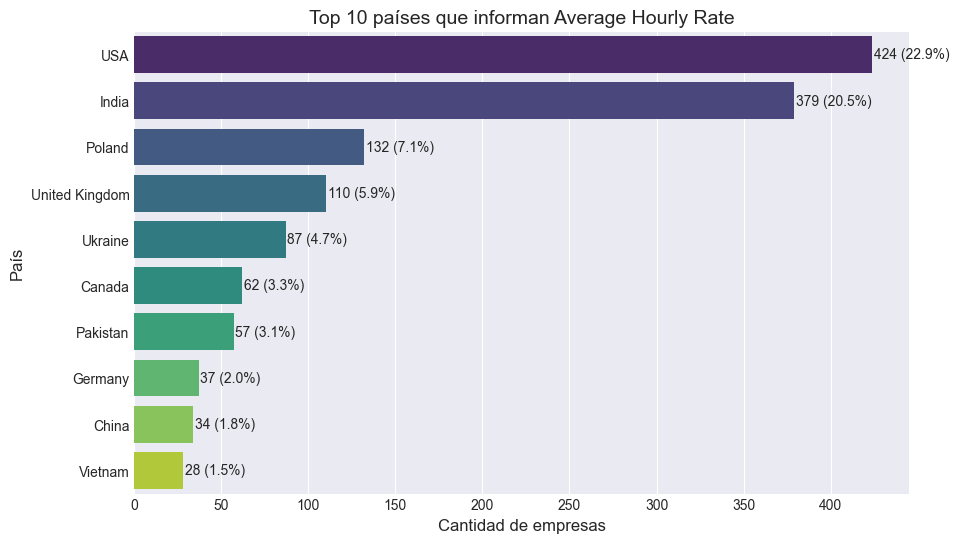

In [409]:
# Gráfico: Top 10 países que informan Average Hourly Rate
top_hourlyrate = df[df['Disponibilidad_HourlyRate'] == 'Informado']['Pais'].value_counts().head(10)
top_hourlyrate_df = top_hourlyrate.reset_index()
top_hourlyrate_df.columns = ['Pais', 'Cantidad']
total_informados_hourly = df[df['Disponibilidad_HourlyRate'] == 'Informado'].shape[0]
top_hourlyrate_df['Porcentaje'] = (top_hourlyrate_df['Cantidad'] / total_informados_hourly) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_hourlyrate_df, x='Cantidad', y='Pais', palette='viridis')

for i, row in top_hourlyrate_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top 10 países que informan Average Hourly Rate', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.show()

In [410]:
# Top 10 países que NO informan MinProject
top_no_minproject = df[df['Disponibilidad_MinProject'] == 'No informado']['Pais'].value_counts().head(10)
total_no_informados_min = df[df['Disponibilidad_MinProject'] == 'No informado'].shape[0]

print("📊 Top 10 países que NO informan Minimum Project Size")
print("="*50)
for pais, cantidad in top_no_minproject.items():
    pct = (cantidad / total_no_informados_min) * 100
    print(f"{pais}: {cantidad} ({pct:.1f}%)")

📊 Top 10 países que NO informan Minimum Project Size
USA: 461 (39.8%)
United Kingdom: 182 (15.7%)
Australia: 69 (6.0%)
India: 61 (5.3%)
Canada: 57 (4.9%)
China: 53 (4.6%)
Colombia: 22 (1.9%)
Mexico: 18 (1.6%)
Spain: 13 (1.1%)
United Arab Emirates: 13 (1.1%)


In [411]:
# Top 10 países que NO informan HourlyRate
top_no_hourlyrate = df[df['Disponibilidad_HourlyRate'] == 'No informado']['Pais'].value_counts().head(10)
total_no_informados_hourly = df[df['Disponibilidad_HourlyRate'] == 'No informado'].shape[0]

print("\n📊 Top 10 países que NO informan Average Hourly Rate")
print("="*50)
for pais, cantidad in top_no_hourlyrate.items():
    pct = (cantidad / total_no_informados_hourly) * 100
    print(f"{pais}: {cantidad} ({pct:.1f}%)")


📊 Top 10 países que NO informan Average Hourly Rate
USA: 493 (39.6%)
United Kingdom: 194 (15.6%)
Australia: 73 (5.9%)
Canada: 64 (5.1%)
India: 62 (5.0%)
China: 53 (4.3%)
Colombia: 22 (1.8%)
Mexico: 20 (1.6%)
Spain: 16 (1.3%)
Poland: 15 (1.2%)


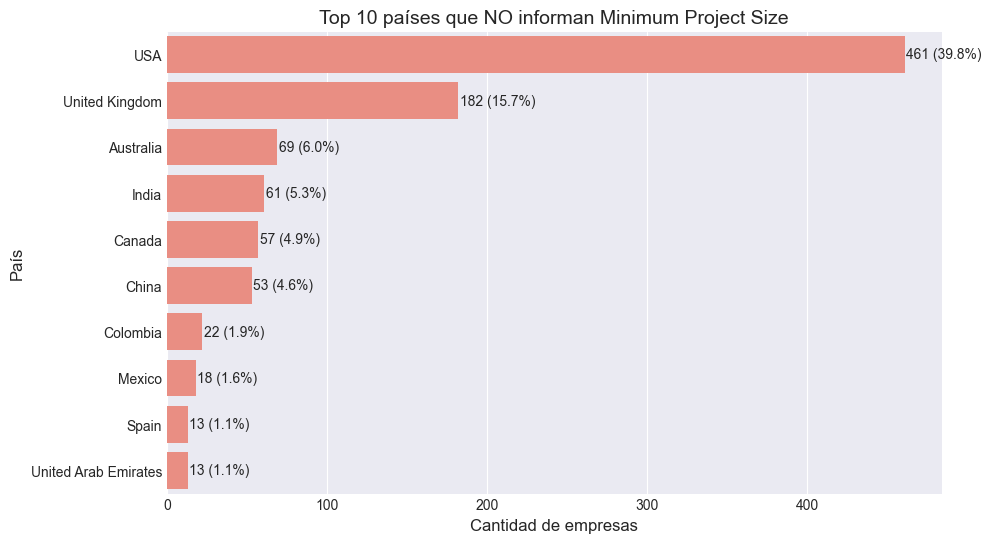

In [412]:
# Gráfico: Top 10 países que NO informan MinProject
top_no_minproject = df[df['Disponibilidad_MinProject'] == 'No informado']['Pais'].value_counts().head(10)
top_no_minproject_df = top_no_minproject.reset_index()
top_no_minproject_df.columns = ['Pais', 'Cantidad']
total_no_informados_min = df[df['Disponibilidad_MinProject'] == 'No informado'].shape[0]
top_no_minproject_df['Porcentaje'] = (top_no_minproject_df['Cantidad'] / total_no_informados_min) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_no_minproject_df, x='Cantidad', y='Pais', color='salmon')

for i, row in top_no_minproject_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top 10 países que NO informan Minimum Project Size', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.show()

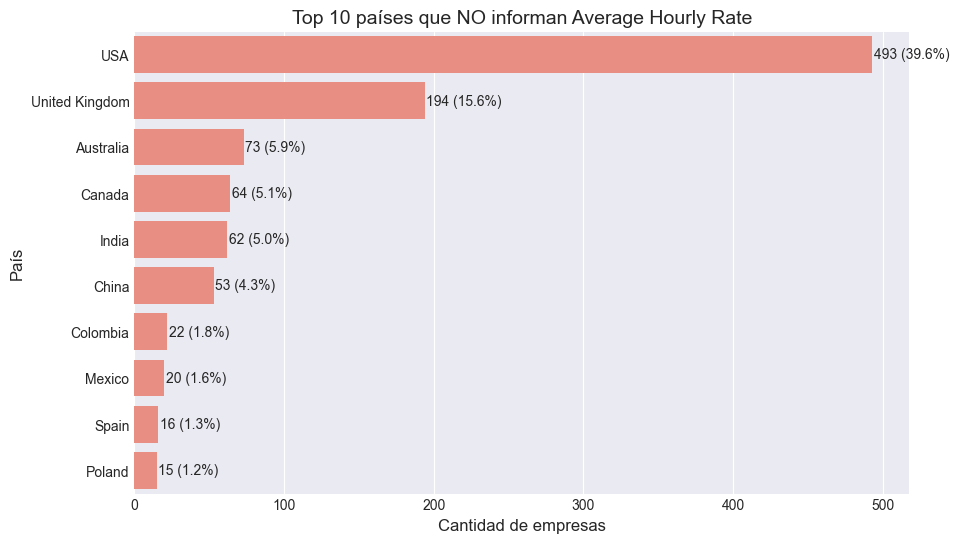

In [413]:
# Gráfico: Top 10 países que NO informan HourlyRate
top_no_hourlyrate = df[df['Disponibilidad_HourlyRate'] == 'No informado']['Pais'].value_counts().head(10)
top_no_hourlyrate_df = top_no_hourlyrate.reset_index()
top_no_hourlyrate_df.columns = ['Pais', 'Cantidad']
total_no_informados_hourly = df[df['Disponibilidad_HourlyRate'] == 'No informado'].shape[0]
top_no_hourlyrate_df['Porcentaje'] = (top_no_hourlyrate_df['Cantidad'] / total_no_informados_hourly) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_no_hourlyrate_df, x='Cantidad', y='Pais', color='salmon')

for i, row in top_no_hourlyrate_df.iterrows():
    ax.text(row['Cantidad'] + 1, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top 10 países que NO informan Average Hourly Rate', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.show()

In [414]:
# Empresas de USA que informan MinProject
usa_minproject = df[(df['Pais'] == 'USA') & (df['Disponibilidad_MinProject'] == 'Informado')].shape[0]
usa_total = df[df['Pais'] == 'USA'].shape[0]
print(f"USA informa MinProject: {usa_minproject} de {usa_total} ({usa_minproject/usa_total*100:.1f}%)")

# Empresas de USA que informan HourlyRate
usa_hourlyrate = df[(df['Pais'] == 'USA') & (df['Disponibilidad_HourlyRate'] == 'Informado')].shape[0]
print(f"USA informa HourlyRate: {usa_hourlyrate} de {usa_total} ({usa_hourlyrate/usa_total*100:.1f}%)")

USA informa MinProject: 456 de 917 (49.7%)
USA informa HourlyRate: 424 de 917 (46.2%)


In [415]:
# Calcular porcentaje de transparencia por país (MinProject)
transparencia_minproject = df[df['Pais'].isin(['USA', 'United Kingdom', 'India', 'Canada', 'Australia'])].groupby('Pais').apply(
    lambda x: (x['Disponibilidad_MinProject'] == 'Informado').sum() / len(x) * 100
).round(1)

print("📊 % de empresas que informan Minimum Project Size por país")
print("="*50)
print(transparencia_minproject.sort_values(ascending=False))

# Calcular porcentaje de transparencia por país (HourlyRate)
transparencia_hourlyrate = df[df['Pais'].isin(['USA', 'United Kingdom', 'India', 'Canada', 'Australia'])].groupby('Pais').apply(
    lambda x: (x['Disponibilidad_HourlyRate'] == 'Informado').sum() / len(x) * 100
).round(1)

print("\n📊 % de empresas que informan Average Hourly Rate por país")
print("="*50)
print(transparencia_hourlyrate.sort_values(ascending=False))

📊 % de empresas que informan Minimum Project Size por país
Pais
India             86.2
Canada            54.8
USA               49.7
United Kingdom    40.1
Australia         28.1
dtype: float64

📊 % de empresas que informan Average Hourly Rate por país
Pais
India             85.9
Canada            49.2
USA               46.2
United Kingdom    36.2
Australia         24.0
dtype: float64


C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\1923358100.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transparencia_minproject = df[df['Pais'].isin(['USA', 'United Kingdom', 'India', 'Canada', 'Australia'])].groupby('Pais').apply(
C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\1923358100.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transparencia_hourlyrate = df[df['Pais'].isin(['USA', 'Uni

In [416]:
# Calcular porcentaje de NO transparencia por país (MinProject)
no_transparencia_minproject = df[df['Pais'].isin(['USA', 'United Kingdom', 'India', 'Canada', 'Australia'])].groupby('Pais').apply(
    lambda x: (x['Disponibilidad_MinProject'] == 'No informado').sum() / len(x) * 100
).round(1)

print("📊 % de empresas que NO informan Minimum Project Size por país")
print("="*50)
print(no_transparencia_minproject.sort_values(ascending=False))

# Calcular porcentaje de NO transparencia por país (HourlyRate)
no_transparencia_hourlyrate = df[df['Pais'].isin(['USA', 'United Kingdom', 'India', 'Canada', 'Australia'])].groupby('Pais').apply(
    lambda x: (x['Disponibilidad_HourlyRate'] == 'No informado').sum() / len(x) * 100
).round(1)

print("\n📊 % de empresas que NO informan Average Hourly Rate por país")
print("="*50)
print(no_transparencia_hourlyrate.sort_values(ascending=False))

📊 % de empresas que NO informan Minimum Project Size por país
Pais
Australia         71.9
United Kingdom    59.9
USA               50.3
Canada            45.2
India             13.8
dtype: float64

📊 % de empresas que NO informan Average Hourly Rate por país
Pais
Australia         76.0
United Kingdom    63.8
USA               53.8
Canada            50.8
India             14.1
dtype: float64


C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\2724978195.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  no_transparencia_minproject = df[df['Pais'].isin(['USA', 'United Kingdom', 'India', 'Canada', 'Australia'])].groupby('Pais').apply(
C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\2724978195.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  no_transparencia_hourlyrate = df[df['Pais'].isin(['USA'

In [417]:
# Seleccionar Top 10 países con más empresas
top_paises = df['Pais'].value_counts().head(10).index

# Crear tabla de porcentajes por país (HourlyRate)
tabla_hourlyrate_pct = pd.crosstab(df[df['Pais'].isin(top_paises)]['Pais'], 
                                   df[df['Pais'].isin(top_paises)]['Disponibilidad_HourlyRate'])
tabla_hourlyrate_pct = tabla_hourlyrate_pct.div(tabla_hourlyrate_pct.sum(axis=1), axis=0) * 100
tabla_hourlyrate_pct = tabla_hourlyrate_pct.round(1)

# Ordenar por total de empresas (de mayor a menor)
orden_paises = df['Pais'].value_counts().head(10).index
tabla_hourlyrate_pct = tabla_hourlyrate_pct.reindex(orden_paises)

print("📊 % de empresas que informan vs no informan (HourlyRate) por país")
print("="*60)
print(tabla_hourlyrate_pct)

📊 % de empresas que informan vs no informan (HourlyRate) por país
Disponibilidad_HourlyRate  Informado  No informado
Pais                                              
USA                             46.2          53.8
India                           85.9          14.1
United Kingdom                  36.2          63.8
Poland                          89.8          10.2
Canada                          49.2          50.8
Australia                       24.0          76.0
Ukraine                         94.6           5.4
China                           39.1          60.9
Pakistan                        93.4           6.6
Germany                         78.7          21.3


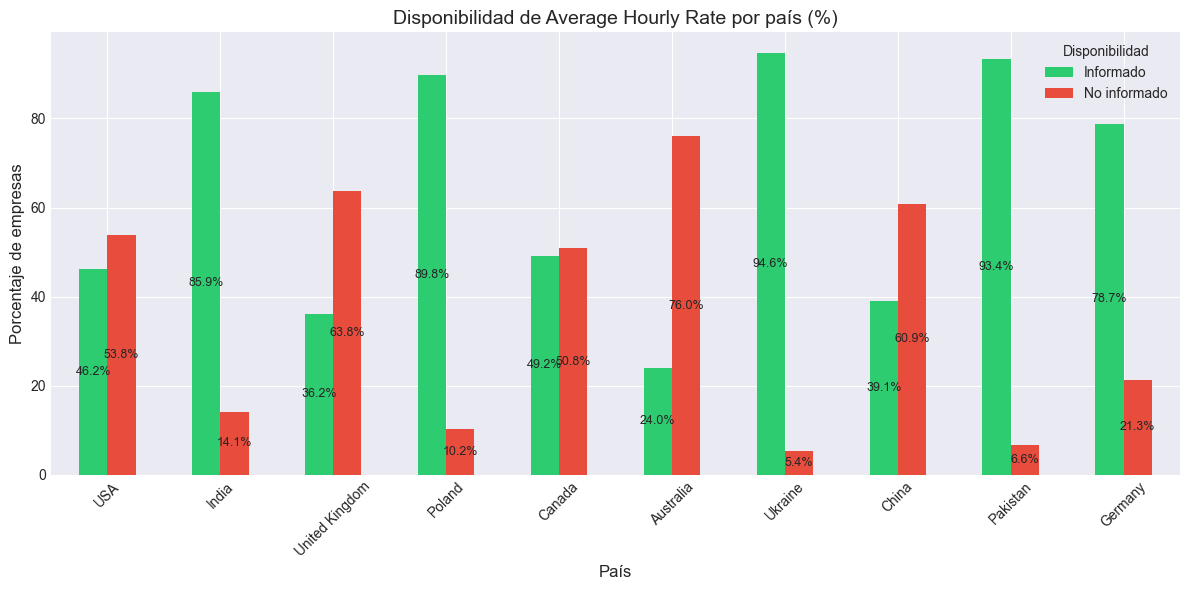

In [418]:
# Con porcentajes dentro de cada barra
ax = tabla_hourlyrate_pct.plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Disponibilidad de Average Hourly Rate por país (%)', fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Porcentaje de empresas', fontsize=12)
plt.legend(title='Disponibilidad', labels=['Informado', 'No informado'])
plt.xticks(rotation=45)
plt.tight_layout()

# Agregar etiquetas de porcentaje
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)

plt.show()

In [419]:
# Seleccionar Top 10 países con más empresas
top_paises = df['Pais'].value_counts().head(10).index

# Crear tabla de porcentajes por país (MinProject)
tabla_minproject_pct = pd.crosstab(df[df['Pais'].isin(top_paises)]['Pais'], 
                                   df[df['Pais'].isin(top_paises)]['Disponibilidad_MinProject'])
tabla_minproject_pct = tabla_minproject_pct.div(tabla_minproject_pct.sum(axis=1), axis=0) * 100
tabla_minproject_pct = tabla_minproject_pct.round(1)

# Ordenar por total de empresas (de mayor a menor)
orden_paises = df['Pais'].value_counts().head(10).index
tabla_minproject_pct = tabla_minproject_pct.reindex(orden_paises)

print("📊 % de empresas que informan vs no informan (MinProject) por país")
print("="*60)
print(tabla_minproject_pct)

📊 % de empresas que informan vs no informan (MinProject) por país
Disponibilidad_MinProject  Informado  No informado
Pais                                              
USA                             49.7          50.3
India                           86.2          13.8
United Kingdom                  40.1          59.9
Poland                          91.2           8.8
Canada                          54.8          45.2
Australia                       28.1          71.9
Ukraine                         94.6           5.4
China                           39.1          60.9
Pakistan                        91.8           8.2
Germany                         80.9          19.1


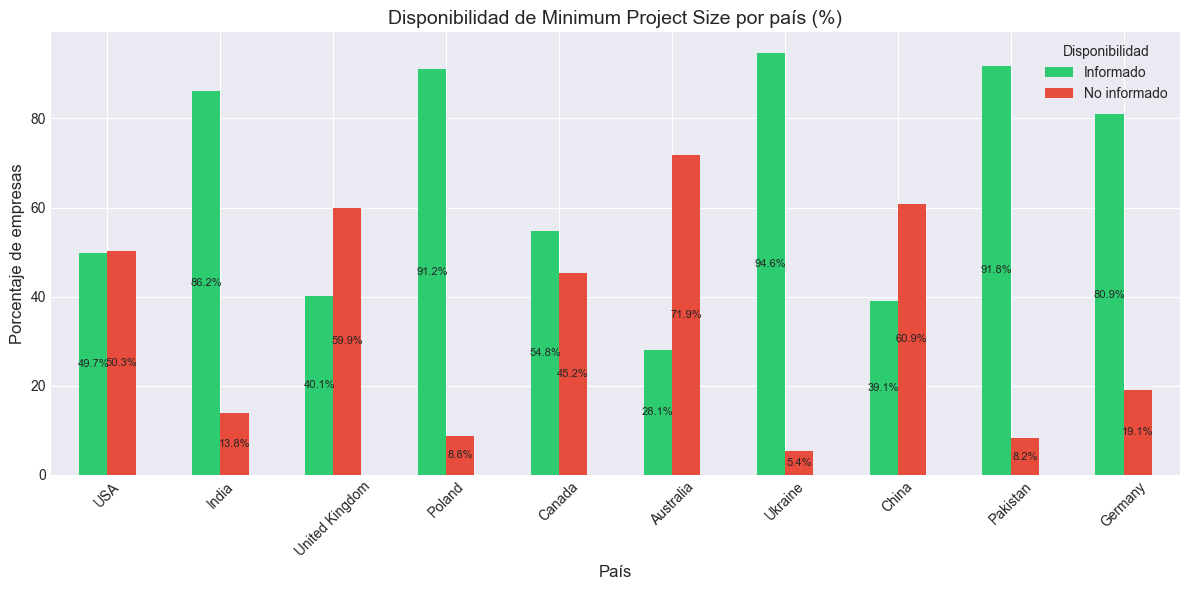

In [420]:
# Gráfico con porcentajes
ax = tabla_minproject_pct.plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Disponibilidad de Minimum Project Size por país (%)', fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Porcentaje de empresas', fontsize=12)
plt.legend(title='Disponibilidad', labels=['Informado', 'No informado'])
plt.xticks(rotation=45)
plt.tight_layout()

# Agregar etiquetas de porcentaje en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

plt.show()

In [421]:
# Crear tabla resumen con ambas variables
resumen_transparencia = pd.DataFrame({
    'País': ['USA', 'India', 'United Kingdom', 'Poland', 'Canada', 'Australia', 'Ukraine', 'China', 'Pakistan', 'Germany'],
    'MinProject Informa (%)': [49.7, 86.2, 40.1, 91.2, 54.8, 28.1, 94.6, 39.1, 91.8, 80.9],
    'HourlyRate Informa (%)': [46.2, 85.9, 36.2, 89.8, 49.2, 24.0, 54.4, 39.1, 93.4, 78.7]
})

# Calcular promedio de transparencia
resumen_transparencia['Promedio Transparencia (%)'] = (resumen_transparencia['MinProject Informa (%)'] + resumen_transparencia['HourlyRate Informa (%)']) / 2

# Ordenar por promedio
resumen_transparencia = resumen_transparencia.sort_values('Promedio Transparencia (%)', ascending=False).round(1)

print("📊 Resumen de transparencia comercial (Top 10 países)")
print("="*70)
print(resumen_transparencia.to_string(index=False))

📊 Resumen de transparencia comercial (Top 10 países)
          País  MinProject Informa (%)  HourlyRate Informa (%)  Promedio Transparencia (%)
      Pakistan                    91.8                    93.4                        92.6
        Poland                    91.2                    89.8                        90.5
         India                    86.2                    85.9                        86.1
       Germany                    80.9                    78.7                        79.8
       Ukraine                    94.6                    54.4                        74.5
        Canada                    54.8                    49.2                        52.0
           USA                    49.7                    46.2                        48.0
         China                    39.1                    39.1                        39.1
United Kingdom                    40.1                    36.2                        38.2
     Australia                    28.

In [422]:
# Crear columna de transparencia comercial por empresa
df['Transparencia_Comercial'] = 0

# Sumar 1 si informa MinProject
df.loc[df['Disponibilidad_MinProject'] == 'Informado', 'Transparencia_Comercial'] += 1

# Sumar 1 si informa HourlyRate
df.loc[df['Disponibilidad_HourlyRate'] == 'Informado', 'Transparencia_Comercial'] += 1

# Verificar que se creó
print("✅ Columna creada. Primeros 10 valores:")
print(df['Transparencia_Comercial'].head(10))

✅ Columna creada. Primeros 10 valores:
0    0
1    2
2    2
3    2
4    2
5    2
6    2
7    2
8    2
9    2
Name: Transparencia_Comercial, dtype: int64


In [423]:
# Describe de la columna Transparencia_Comercial
print("📊 Estadística descriptiva de Transparencia Comercial")
print("="*50)
print(df['Transparencia_Comercial'].describe())

📊 Estadística descriptiva de Transparencia Comercial
count    3096.000000
mean        1.224160
std         0.940291
min         0.000000
25%         0.000000
50%         2.000000
75%         2.000000
max         2.000000
Name: Transparencia_Comercial, dtype: float64


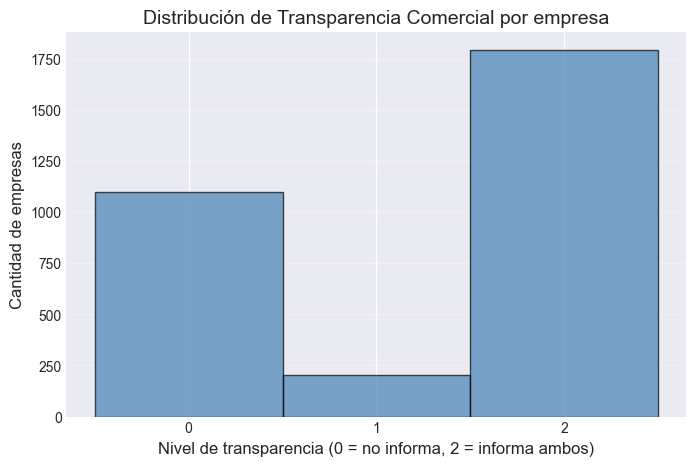

In [424]:
# Histograma
plt.figure(figsize=(8, 5))
plt.hist(df['Transparencia_Comercial'], bins=[-0.5, 0.5, 1.5, 2.5], edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Distribución de Transparencia Comercial por empresa', fontsize=14)
plt.xlabel('Nivel de transparencia (0 = no informa, 2 = informa ambos)', fontsize=12)
plt.ylabel('Cantidad de empresas', fontsize=12)
plt.xticks([0, 1, 2])
plt.grid(axis='y', alpha=0.3)
plt.show()

In [425]:
# Estadísticas de la columna
print("📊 Estadísticas de Transparencia Comercial")
print("="*40)
print(f"Media: {df['Transparencia_Comercial'].mean():.2f}")
print(f"Mediana: {df['Transparencia_Comercial'].median()}")
print(f"Moda: {df['Transparencia_Comercial'].mode()[0]}")
print(f"Empresas con transparencia máxima (2): {sum(df['Transparencia_Comercial'] == 2)}")
print(f"Empresas con transparencia mínima (0): {sum(df['Transparencia_Comercial'] == 0)}")

📊 Estadísticas de Transparencia Comercial
Media: 1.22
Mediana: 2.0
Moda: 2
Empresas con transparencia máxima (2): 1793
Empresas con transparencia mínima (0): 1099


In [426]:
df['Transparencia_Comercial'].value_counts()

Transparencia_Comercial
2    1793
0    1099
1     204
Name: count, dtype: int64

In [427]:
df.groupby('Tipo de proveedor / segmento de análisis')['Transparencia_Comercial'].mean()

Tipo de proveedor / segmento de análisis
Enterprise    0.880597
Freelancer    1.304348
Mid-market    1.260000
SMB           1.229152
Name: Transparencia_Comercial, dtype: float64

In [428]:
df.groupby('Pais')['Transparencia_Comercial'].mean().sort_values(ascending=False)

Pais
Azerbaijan    2.000000
Eswatini      2.000000
Kosovo        2.000000
Malta         2.000000
Nepal         2.000000
                ...   
Ecuador       0.500000
Panama        0.333333
Bahrain       0.000000
Namibia       0.000000
Tanzania      0.000000
Name: Transparencia_Comercial, Length: 89, dtype: float64

In [429]:
df.groupby('Segmentación servicios AI')['Transparencia_Comercial'].mean()

Segmentación servicios AI
AI Focus                    0.866295
AI Focus principal          0.635992
AI Service complementary    1.177530
AI Service residual         1.658965
Name: Transparencia_Comercial, dtype: float64

C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\1704199707.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Tipo de proveedor / segmento de análisis', y='Transparencia_Comercial', palette='viridis')


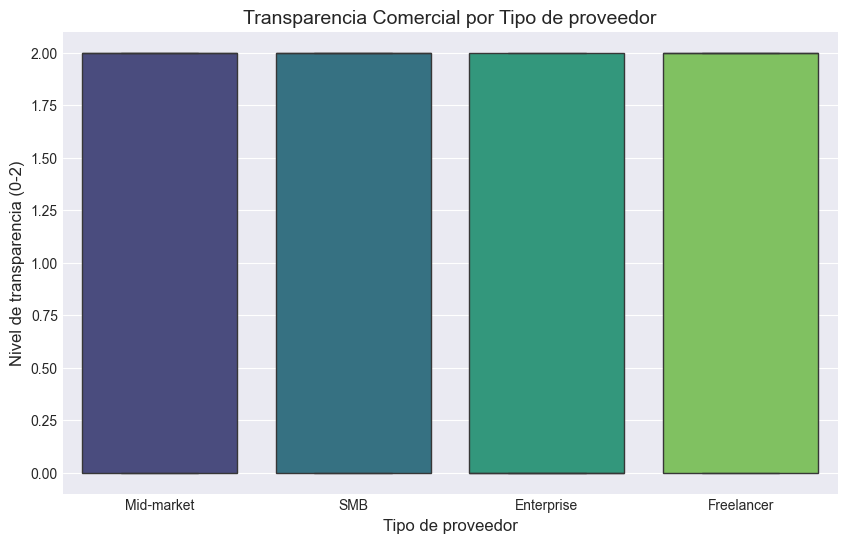

In [430]:
# Boxplot: Transparencia por Tipo de proveedor
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tipo de proveedor / segmento de análisis', y='Transparencia_Comercial', palette='viridis')
plt.title('Transparencia Comercial por Tipo de proveedor', fontsize=14)
plt.xlabel('Tipo de proveedor', fontsize=12)
plt.ylabel('Nivel de transparencia (0-2)', fontsize=12)
plt.show()

**Nota:** Al analizar la transparencia comercial por tipo de proveedor, no se encontraron diferencias significativas entre segmentos. Todos los tipos de proveedor presentan niveles de transparencia similares (entre 1.0 y 1.5 en promedio), lo que sugiere que la transparencia comercial es un fenómeno general del mercado y no está asociada al tamaño de la empresa.

In [431]:
df['Percent AI Service Focus'].describe()

count     3096
unique      38
top        10%
freq       877
Name: Percent AI Service Focus, dtype: object

In [432]:
# Tabla de transparencia por tipo de proveedor
transparencia_por_tipo = df.groupby('Tipo de proveedor / segmento de análisis')['Transparencia_Comercial'].agg(['mean', 'median', 'count']).round(2)
print("📊 Transparencia Comercial por Tipo de proveedor")
print(transparencia_por_tipo)

📊 Transparencia Comercial por Tipo de proveedor
                                          mean  median  count
Tipo de proveedor / segmento de análisis                     
Enterprise                                0.88     0.0     67
Freelancer                                1.30     2.0     23
Mid-market                                1.26     2.0    200
SMB                                       1.23     2.0   2806


C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\999637341.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Tipo de proveedor / segmento de análisis', ylabel='Percent AI Service Focus'>

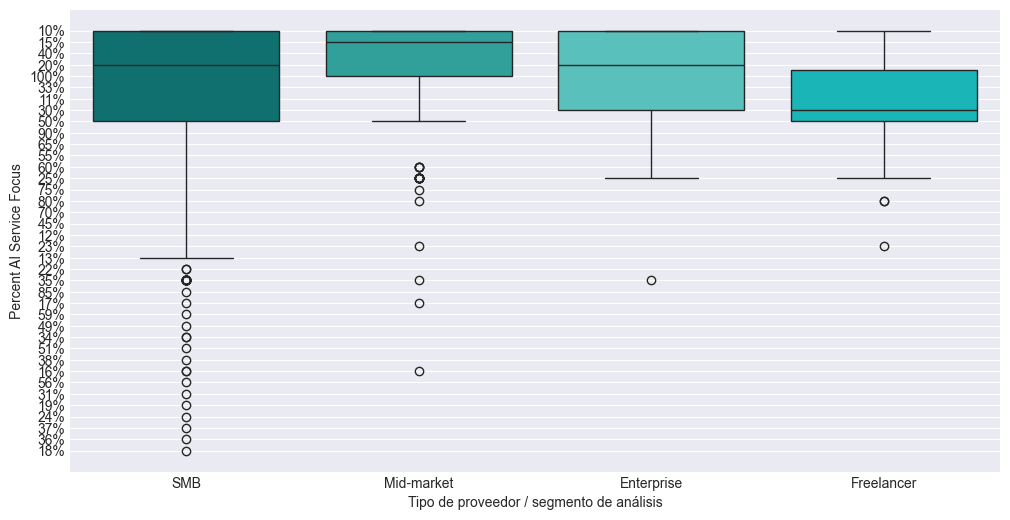

In [433]:
# Con diferentes tonos de teal (más interesante visualmente)
paleta_teal = ['#008080', '#20B2AA', '#48D1CC', '#00CED1']  # de teal oscuro a claro
orden_proveedores = ['SMB', 'Mid-market', 'Enterprise', 'Freelancer']

sns.boxplot(
    data=df,
    x='Tipo de proveedor / segmento de análisis',
    y='Percent AI Service Focus',
    order=orden_proveedores,
    palette=paleta_teal,  # ← diferentes tonos de teal
    showfliers=True
)

C:\Users\Marcelaz\AppData\Local\Temp\ipykernel_27296\2038180087.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


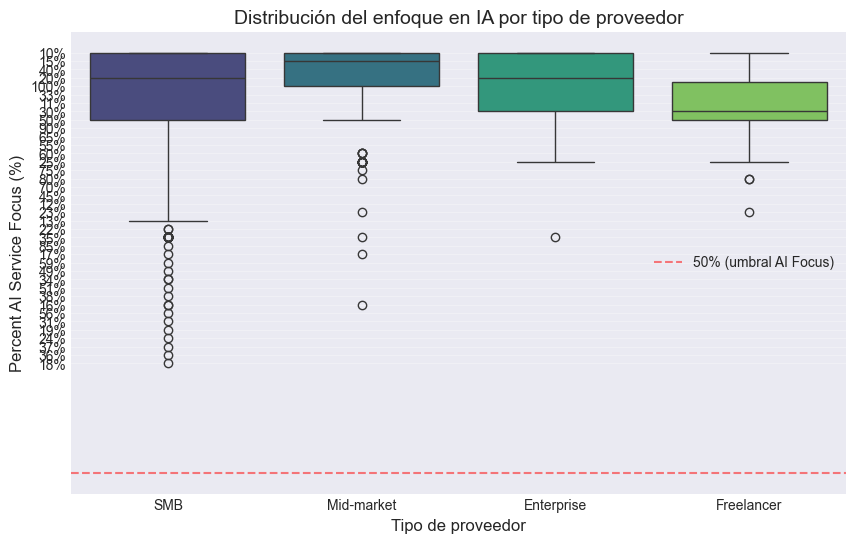

In [434]:
# Orden de proveedores (de mayor a menor cantidad)
orden_proveedores = ['SMB', 'Mid-market', 'Enterprise', 'Freelancer']

# Configurar gráfico
plt.figure(figsize=(10, 6))

# Boxplot ordenado
sns.boxplot(
    data=df, 
    x='Tipo de proveedor / segmento de análisis', 
    y='Percent AI Service Focus',
    order=orden_proveedores,
    palette='viridis',
    showfliers=True
)

# Títulos y etiquetas
plt.title('Distribución del enfoque en IA por tipo de proveedor', fontsize=14)
plt.xlabel('Tipo de proveedor', fontsize=12)
plt.ylabel('Percent AI Service Focus (%)', fontsize=12)

# Línea horizontal en 50% (umbral de AI Focus)
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (umbral AI Focus)')
plt.legend()

plt.grid(axis='y', alpha=0.3)
plt.show()

#### 📌 Conclusión Transparencia comercial

**Poland, Pakistan, India, Ukraine y Germany** son los mercados más transparentes, con un promedio de transparencia superior al 70%.

**Australia, UK y China** son los mercados menos transparentes, con menos del 45% de sus empresas informando datos de precios.

**USA** tiene un nivel de transparencia medio-bajo (48%), lo que indica que, a pesar de ser el mercado más grande, no es el más transparente.

**Ukraine** es un caso atípico: informa casi el 95% de sus proyectos (MinProject), pero solo el 54% de sus tarifas horarias (HourlyRate), lo que sugiere una política comercial enfocada en proyectos más que en tarifas por hora.

##### Implicancias
- Para empresas que buscan transparencia de mercado, **Poland, India y Pakistan** son los mercados más informan.
- **Australia y UK** requieren más esfuerzo para obtener datos de precios.
- La transparencia no está correlacionada con el tamaño del mercado, sino con factores culturales o regulatorios.

##### 🔍 Nota metodológica - Transparencia comercial

**Fuente de datos:** Dataset de Kaggle (2022) basado en perfiles de Clutch.co.

**Variables analizadas:**
- `Disponibilidad_MinProject`: Indica si la empresa informa su proyecto mínimo.
- `Disponibilidad_HourlyRate`: Indica si la empresa informa su tarifa por hora.

**Cálculo:**
Los porcentajes se calcularon sobre el total de empresas de cada país, no sobre el total global, para evaluar su comportamiento relativo.

**Limitaciones:**
- Los datos corresponden a 2022 y pueden no reflejar la situación actual.
- La información es auto-reportada por las empresas en Clutch.co.
- Los hallazgos se limitan a los 10 países con mayor cantidad de empresas en el dataset.

**Interpretación:**
La transparencia comercial se mide como el porcentaje de empresas que informan sus datos de precios dentro de cada país. Esto no implica necesariamente que las empresas que no informan sean menos confiables, sino que tienen políticas comerciales diferentes.

##### 5.4  Hallazgos Transparencia Comercial

- **La mayoría de las empresas (56%)** informan tanto su proyecto mínimo como su tarifa por hora (nivel 2).
- **Un 32%** de las empresas no informan ninguno de los dos datos (nivel 0).
- **Solo un 8%** informa parcialmente (nivel 1).

**Conclusión:** El mercado tiene un nivel de transparencia medio-alto, con más de la mitad de las empresas publicando sus datos de precios de forma completa. Sin embargo, un tercio de las empresas no publica precios, lo que puede ser un obstáculo para el análisis de mercado.

In [435]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3096 entries, 0 to 3099
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Company_Name                              3096 non-null   object
 1   Website                                   3096 non-null   object
 2   Location                                  3096 non-null   object
 3   Minimum Project Size                      3096 non-null   object
 4   Average Hourly Rate                       3096 non-null   object
 5   Number of Employees                       3096 non-null   object
 6   Percent AI Service Focus                  3096 non-null   object
 7   Ciudad                                    3096 non-null   object
 8   Estado                                    910 non-null    object
 9   Pais                                      3096 non-null   object
 10  Disponibilidad_MinProject                 3096 non-nu

In [436]:
filtro = df['Segmentación servicios AI'] == 'AI Focus principal'

# Seleccionar columnas y mostrar
df[filtro][["Company_Name", "Segmentación servicios AI"]].value_counts()

Company_Name              Segmentación servicios AI
@AdamaRobotics            AI Focus principal           1
ADARobotics               AI Focus principal           1
AIBrisbane                AI Focus principal           1
AICA                      AI Focus principal           1
AIDerivatives             AI Focus principal           1
                                                      ..
theDevMasters             AI Focus principal           1
ubisend                   AI Focus principal           1
vElementITPrivateLimited  AI Focus principal           1
xBrain                    AI Focus principal           1
ÄhdusTechnology           AI Focus principal           1
Name: count, Length: 489, dtype: int64

In [437]:
# Filtros: AI Focus principal + SMB
filtro = (df['Segmentación servicios AI'] == 'AI Focus principal') & (df['Tipo de proveedor / segmento de análisis'] == 'SMB')

# Seleccionar columnas incluyendo País
df[filtro][["Company_Name", "Pais", "Segmentación servicios AI", "Tipo de proveedor / segmento de análisis", "Transparencia_Comercial"]].value_counts()

Company_Name              Pais            Segmentación servicios AI  Tipo de proveedor / segmento de análisis  Transparencia_Comercial
@AdamaRobotics            United Kingdom  AI Focus principal         SMB                                       0                          1
ADARobotics               Costa Rica      AI Focus principal         SMB                                       0                          1
AIBrisbane                Australia       AI Focus principal         SMB                                       0                          1
AICA                      Switzerland     AI Focus principal         SMB                                       0                          1
AIDerivatives             USA             AI Focus principal         SMB                                       2                          1
                                                                                                                                         ..
theDevMasters            

In [438]:
# Ordenar por país y luego por transparencia
df[filtro][["Company_Name", "Pais", "Segmentación servicios AI", "Tipo de proveedor / segmento de análisis", "Transparencia_Comercial"]].sort_values(["Pais", "Transparencia_Comercial"], ascending=[True, False]).head(
    
)

,Company_Name,Pais,Segmentación servicios AI,Tipo de proveedor / segmento de análisis,Transparencia_Comercial
744,SmartClick,Armenia,AI Focus principal,SMB,0
1055,SimpleMarketing.AI,Australia,AI Focus principal,SMB,2
1297,SydneyAI,Australia,AI Focus principal,SMB,2
523,H2ventures,Australia,AI Focus principal,SMB,0
555,BetaSharesETFs,Australia,AI Focus principal,SMB,0


In [439]:
# Ver cuántas empresas AI Focus principal + SMB hay por país
df[filtro]['Pais'].value_counts()

Pais
USA               156
United Kingdom    102
Australia          41
Canada             27
India              26
Ukraine            13
Poland             11
Pakistan            9
Uruguay             6
Switzerland         5
Bulgaria            5
China               4
Ireland             4
Brazil              3
Turkey              3
Netherlands         3
Germany             3
Spain               3
Colombia            3
Italy               2
New Zealand         2
Romania             2
Vietnam             2
Chile               2
Croatia             2
Mexico              2
Costa Rica          2
Finland             1
Singapore           1
Lithuania           1
Armenia             1
Sweden              1
Latvia              1
Denmark             1
Slovakia            1
Philippines         1
Israel              1
Estonia             1
Peru                1
Japan               1
Serbia              1
Bangladesh          1
Portugal            1
Moldova             1
Sri Lanka           1
Hong 

In [440]:
# Filtro
filtro = (df['Segmentación servicios AI'] == 'AI Focus principal') & (df['Tipo de proveedor / segmento de análisis'] == 'SMB')

# Total y distribución con porcentaje
total = filtro.sum()
distribucion = df[filtro]['Pais'].value_counts()

print(f"📊 Total de empresas: {total}")
print("\n📊 Distribución por país")
for pais, cantidad in distribucion.items():
    pct = (cantidad / total) * 100
    print(f"  {pais}: {cantidad} ({pct:.1f}%)")

📊 Total de empresas: 465

📊 Distribución por país
  USA: 156 (33.5%)
  United Kingdom: 102 (21.9%)
  Australia: 41 (8.8%)
  Canada: 27 (5.8%)
  India: 26 (5.6%)
  Ukraine: 13 (2.8%)
  Poland: 11 (2.4%)
  Pakistan: 9 (1.9%)
  Uruguay: 6 (1.3%)
  Switzerland: 5 (1.1%)
  Bulgaria: 5 (1.1%)
  China: 4 (0.9%)
  Ireland: 4 (0.9%)
  Brazil: 3 (0.6%)
  Turkey: 3 (0.6%)
  Netherlands: 3 (0.6%)
  Germany: 3 (0.6%)
  Spain: 3 (0.6%)
  Colombia: 3 (0.6%)
  Italy: 2 (0.4%)
  New Zealand: 2 (0.4%)
  Romania: 2 (0.4%)
  Vietnam: 2 (0.4%)
  Chile: 2 (0.4%)
  Croatia: 2 (0.4%)
  Mexico: 2 (0.4%)
  Costa Rica: 2 (0.4%)
  Finland: 1 (0.2%)
  Singapore: 1 (0.2%)
  Lithuania: 1 (0.2%)
  Armenia: 1 (0.2%)
  Sweden: 1 (0.2%)
  Latvia: 1 (0.2%)
  Denmark: 1 (0.2%)
  Slovakia: 1 (0.2%)
  Philippines: 1 (0.2%)
  Israel: 1 (0.2%)
  Estonia: 1 (0.2%)
  Peru: 1 (0.2%)
  Japan: 1 (0.2%)
  Serbia: 1 (0.2%)
  Bangladesh: 1 (0.2%)
  Portugal: 1 (0.2%)
  Moldova: 1 (0.2%)
  Sri Lanka: 1 (0.2%)
  Hong Kong: 1 (0.2%)
  S

In [441]:
# Filtro con transparencia máxima
filtro = (
    (df['Segmentación servicios AI'] == 'AI Focus principal') &
    (df['Tipo de proveedor / segmento de análisis'] == 'SMB') &
    (df['Transparencia_Comercial'] == 2)
)

# Total
total = filtro.sum()
print(f"📊 Total de empresas: {total}")

# Distribución por país
print("\n📊 Distribución por país")
for pais, cantidad in df[filtro]['Pais'].value_counts().items():
    pct = (cantidad / total) * 100
    print(f"  {pais}: {cantidad} ({pct:.1f}%)")

📊 Total de empresas: 135

📊 Distribución por país
  USA: 21 (15.6%)
  India: 19 (14.1%)
  Ukraine: 12 (8.9%)
  United Kingdom: 12 (8.9%)
  Pakistan: 9 (6.7%)
  Poland: 7 (5.2%)
  Uruguay: 6 (4.4%)
  Canada: 4 (3.0%)
  Germany: 3 (2.2%)
  China: 3 (2.2%)
  Netherlands: 3 (2.2%)
  Brazil: 3 (2.2%)
  Bulgaria: 3 (2.2%)
  Italy: 2 (1.5%)
  Colombia: 2 (1.5%)
  Croatia: 2 (1.5%)
  Vietnam: 2 (1.5%)
  Australia: 2 (1.5%)
  Lithuania: 1 (0.7%)
  Latvia: 1 (0.7%)
  Ireland: 1 (0.7%)
  Spain: 1 (0.7%)
  Serbia: 1 (0.7%)
  Slovakia: 1 (0.7%)
  Peru: 1 (0.7%)
  Israel: 1 (0.7%)
  Japan: 1 (0.7%)
  Bangladesh: 1 (0.7%)
  Portugal: 1 (0.7%)
  Estonia: 1 (0.7%)
  Romania: 1 (0.7%)
  Chile: 1 (0.7%)
  Mexico: 1 (0.7%)
  Moldova: 1 (0.7%)
  Sri Lanka: 1 (0.7%)
  Slovenia: 1 (0.7%)
  Czech Republic: 1 (0.7%)
  Cyprus: 1 (0.7%)


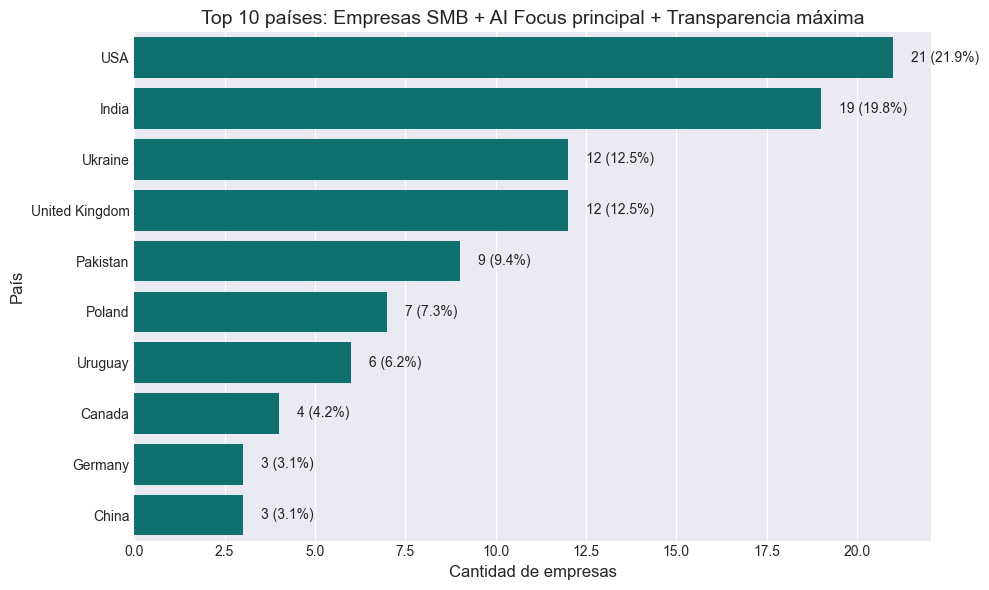

In [442]:
# Filtro: AI Focus principal + SMB + Transparencia máxima (2)
filtro = (
    (df['Segmentación servicios AI'] == 'AI Focus principal') &
    (df['Tipo de proveedor / segmento de análisis'] == 'SMB') &
    (df['Transparencia_Comercial'] == 2)
)

# Preparar datos
top_paises = df[filtro]['Pais'].value_counts().head(10)  # Top 10
total = top_paises.sum()

# Crear DataFrame para el gráfico
top_paises_df = top_paises.reset_index()
top_paises_df.columns = ['Pais', 'Cantidad']
top_paises_df['Porcentaje'] = (top_paises_df['Cantidad'] / total) * 100

# Graficar
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_paises_df, x='Cantidad', y='Pais', color='teal')

# Agregar etiquetas con cantidad y porcentaje
for i, row in top_paises_df.iterrows():
    ax.text(row['Cantidad'] + 0.5, i, f"{row['Cantidad']} ({row['Porcentaje']:.1f}%)", 
            va='center', fontsize=10)

plt.title('Top 10 países: Empresas SMB + AI Focus principal + Transparencia máxima', fontsize=14)
plt.xlabel('Cantidad de empresas', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.show()

In [443]:
# Calcular % de transparencia por país
filtro_base = (
    (df['Segmentación servicios AI'] == 'AI Focus principal') &
    (df['Tipo de proveedor / segmento de análisis'] == 'SMB')
)

# Total por país
total_por_pais = df[filtro_base]['Pais'].value_counts()

# Transparentes por país
transparentes_por_pais = df[filtro_base & (df['Transparencia_Comercial'] == 2)]['Pais'].value_counts()

# Crear tabla
tabla_transparencia = pd.DataFrame({
    'Total': total_por_pais,
    'Transparentes': transparentes_por_pais
}).fillna(0).astype(int)

tabla_transparencia['% Transparente'] = (tabla_transparencia['Transparentes'] / tabla_transparencia['Total'] * 100).round(1)
tabla_transparencia = tabla_transparencia.sort_values('Total', ascending=False)

print(tabla_transparencia.head(10))

                Total  Transparentes  % Transparente
Pais                                                
USA               156             21            13.5
United Kingdom    102             12            11.8
Australia          41              2             4.9
Canada             27              4            14.8
India              26             19            73.1
Ukraine            13             12            92.3
Poland             11              7            63.6
Pakistan            9              9           100.0
Uruguay             6              6           100.0
Switzerland         5              0             0.0


In [444]:
# Filtro transparencia min
filtro = (
    (df['Segmentación servicios AI'] == 'AI Focus principal') &
    (df['Tipo de proveedor / segmento de análisis'] == 'SMB') &
    (df['Transparencia_Comercial'] == 1)
)

# Total
total = filtro.sum()
print(f"📊 Total de empresas: {total}")

# Distribución por país )
print("\n📊 Distribución por país ")
for pais, cantidad in df[filtro]['Pais'].value_counts().items():
    pct = (cantidad / total) * 100
    print(f"  {pais}: {cantidad} ({pct:.1f}%)")

📊 Total de empresas: 23

📊 Distribución por país 
  USA: 7 (30.4%)
  United Kingdom: 3 (13.0%)
  Turkey: 2 (8.7%)
  Bulgaria: 2 (8.7%)
  Canada: 1 (4.3%)
  India: 1 (4.3%)
  Philippines: 1 (4.3%)
  Poland: 1 (4.3%)
  Denmark: 1 (4.3%)
  Spain: 1 (4.3%)
  Colombia: 1 (4.3%)
  Mexico: 1 (4.3%)
  Hong Kong: 1 (4.3%)


In [445]:
# Filtro transparencia cero
filtro = (
    (df['Segmentación servicios AI'] == 'AI Focus principal') &
    (df['Tipo de proveedor / segmento de análisis'] == 'SMB') &
    (df['Transparencia_Comercial'] == 0)
)

# Total
total = filtro.sum()
print(f"📊 Total de empresas: {total}")

# Distribución por país )
print("\n📊 Distribución por país ")
for pais, cantidad in df[filtro]['Pais'].value_counts().items():
    pct = (cantidad / total) * 100
    print(f"  {pais}: {cantidad} ({pct:.1f}%)")

📊 Total de empresas: 307

📊 Distribución por país 
  USA: 128 (41.7%)
  United Kingdom: 87 (28.3%)
  Australia: 39 (12.7%)
  Canada: 22 (7.2%)
  India: 6 (2.0%)
  Switzerland: 5 (1.6%)
  Poland: 3 (1.0%)
  Ireland: 3 (1.0%)
  New Zealand: 2 (0.7%)
  Costa Rica: 2 (0.7%)
  Finland: 1 (0.3%)
  Singapore: 1 (0.3%)
  Sweden: 1 (0.3%)
  Armenia: 1 (0.3%)
  China: 1 (0.3%)
  Chile: 1 (0.3%)
  Spain: 1 (0.3%)
  Romania: 1 (0.3%)
  Turkey: 1 (0.3%)
  Ukraine: 1 (0.3%)


In [446]:
# Diccionario de mapeo de países
mapeo_paises = {
    # América del Norte
    'USA': 'United States',
    'Canada': 'Canada',
    'Mexico': 'Mexico',
    'Panama': 'Panama',
    'Costa Rica': 'Costa Rica',
    'El Salvador': 'El Salvador',
    'Guatemala': 'Guatemala',
    'Jamaica': 'Jamaica',
    'Puerto Rico': 'Puerto Rico',

    # América del Sur
    'Argentina': 'Argentina',
    'Brazil': 'Brazil',
    'Chile': 'Chile',
    'Colombia': 'Colombia',
    'Ecuador': 'Ecuador',
    'Peru': 'Peru',
    'Uruguay': 'Uruguay',

    # Europa
    'United Kingdom': 'United Kingdom',
    'Poland': 'Poland',
    'Germany': 'Germany',
    'Spain': 'Spain',
    'France': 'France',
    'Italy': 'Italy',
    'Netherlands': 'Netherlands',
    'Switzerland': 'Switzerland',
    'Sweden': 'Sweden',
    'Norway': 'Norway',
    'Denmark': 'Denmark',
    'Finland': 'Finland',
    'Ireland': 'Ireland',
    'Portugal': 'Portugal',
    'Greece': 'Greece',
    'Austria': 'Austria',
    'Belgium': 'Belgium',
    'Czech Republic': 'Czech Republic',
    'Hungary': 'Hungary',
    'Romania': 'Romania',
    'Ukraine': 'Ukraine',
    'Estonia': 'Estonia',
    'Latvia': 'Latvia',
    'Lithuania': 'Lithuania',
    'Slovakia': 'Slovakia',
    'Slovenia': 'Slovenia',
    'Bulgaria': 'Bulgaria',
    'Croatia': 'Croatia',
    'Serbia': 'Serbia',
    'Bosnia and Herzegovina': 'Bosnia and Herzegovina',
    'North Macedonia': 'North Macedonia',
    'Moldova': 'Moldova',
    'Kosovo': 'Kosovo',
    'Cyprus': 'Cyprus',
    'Malta': 'Malta',
    'Luxembourg': 'Luxembourg',

    # Asia
    'India': 'India',
    'China': 'China',
    'Japan': 'Japan',
    'South Korea': 'South Korea',
    'Turkey': 'Turkey',
    'Israel': 'Israel',
    'United Arab Emirates': 'United Arab Emirates',
    'Saudi Arabia': 'Saudi Arabia',
    'Singapore': 'Singapore',
    'Malaysia': 'Malaysia',
    'Thailand': 'Thailand',
    'Vietnam': 'Vietnam',
    'Philippines': 'Philippines',
    'Pakistan': 'Pakistan',
    'Bangladesh': 'Bangladesh',
    'Nepal': 'Nepal',
    'Sri Lanka': 'Sri Lanka',
    'Hong Kong': 'Hong Kong',
    'Kazakhstan': 'Kazakhstan',
    'Uzbekistan': 'Uzbekistan',
    'Azerbaijan': 'Azerbaijan',
    'Georgia': 'Georgia',
    'Armenia': 'Armenia',
    'Jordan': 'Jordan',
    'Bahrain': 'Bahrain',
    'Oman': 'Oman',

    # Oceanía
    'Australia': 'Australia',
    'New Zealand': 'New Zealand',

    # África
    'South Africa': 'South Africa',
    'Nigeria': 'Nigeria',
    'Kenya': 'Kenya',
    'Morocco': 'Morocco',
    'Tanzania': 'Tanzania',
    'Uganda': 'Uganda',
    'Seychelles': 'Seychelles',
    'Eswatini': 'Eswatini',
    'Namibia': 'Namibia',

    # Oriente Medio (ya incluidos en Asia)
}

In [447]:
# Si ya tenés la columna "Clasificación por regiones" (continentes)
df['continent'] = df['Clasificación por regiones']

# O podés crear un mapeo directo
mapeo_continentes = {
    'América del Norte': 'North America',
    'Centroamérica': 'Central America',
    'América del Sur': 'South America',
    'Europa': 'Europe',
    'Asia': 'Asia',
    'Oceanía': 'Oceania',
    'África': 'Africa',
    'Oriente Medio': 'Middle East'
}

In [448]:
# Crear columnas para visualizaciones (sin modificar las originales)
df['country'] = df['Pais']  # Copia de Pais (podés ajustar nombres a inglés si querés)
df['continent'] = df['Clasificación por regiones']  # Copia de Clasificación por regiones

# Verificar que se crearon
print("✅ Columnas creadas:")
print(f"country: {df['country'].nunique()} valores únicos")
print(f"continent: {df['continent'].nunique()} valores únicos")

✅ Columnas creadas:
country: 89 valores únicos
continent: 8 valores únicos


In [449]:
# Si SCImago necesita países en inglés
mapeo_ingles = {
    'USA': 'United States',
    'United Kingdom': 'United Kingdom',
    'India': 'India',
    'Canada': 'Canada',
    'Australia': 'Australia',
    # ... agregá los que necesites
}

df['country'] = df['Pais'].map(mapeo_ingles).fillna(df['Pais'])

In [450]:
# Diccionario de códigos ISO Alpha-3 para los países de tu dataset
iso_codes = {
    'USA': 'USA',
    'United States': 'USA',
    'India': 'IND',
    'United Kingdom': 'GBR',
    'Canada': 'CAN',
    'Australia': 'AUS',
    'Spain': 'ESP',
    'Germany': 'DEU',
    'Poland': 'POL',
    'Pakistan': 'PAK',
    'Uruguay': 'URY',
    'Argentina': 'ARG',
    'Ukraine': 'UKR',
    'Mexico': 'MEX',
    'Colombia': 'COL',
    'Chile': 'CHL',
    'Peru': 'PER',
    'Ecuador': 'ECU',
    'Brazil': 'BRA',
    'France': 'FRA',
    'Italy': 'ITA',
    'Netherlands': 'NLD',
    'Switzerland': 'CHE',
    'Sweden': 'SWE',
    'Norway': 'NOR',
    'Denmark': 'DNK',
    'Finland': 'FIN',
    'Ireland': 'IRL',
    'Portugal': 'PRT',
    'Greece': 'GRC',
    'Austria': 'AUT',
    'Belgium': 'BEL',
    'Czech Republic': 'CZE',
    'Hungary': 'HUN',
    'Romania': 'ROU',
    'Ukraine': 'UKR',
    'Estonia': 'EST',
    'Latvia': 'LVA',
    'Lithuania': 'LTU',
    'Slovakia': 'SVK',
    'Slovenia': 'SVN',
    'Bulgaria': 'BGR',
    'Croatia': 'HRV',
    'Serbia': 'SRB',
    'Bosnia and Herzegovina': 'BIH',
    'North Macedonia': 'MKD',
    'Moldova': 'MDA',
    'Kosovo': 'XKX',
    'Cyprus': 'CYP',
    'Malta': 'MLT',
    'Luxembourg': 'LUX',
    'Turkey': 'TUR',
    'Israel': 'ISR',
    'United Arab Emirates': 'ARE',
    'Saudi Arabia': 'SAU',
    'Singapore': 'SGP',
    'Malaysia': 'MYS',
    'Thailand': 'THA',
    'Vietnam': 'VNM',
    'Philippines': 'PHL',
    'Bangladesh': 'BGD',
    'Nepal': 'NPL',
    'Sri Lanka': 'LKA',
    'Hong Kong': 'HKG',
    'Kazakhstan': 'KAZ',
    'Uzbekistan': 'UZB',
    'Azerbaijan': 'AZE',
    'Georgia': 'GEO',
    'Armenia': 'ARM',
    'Jordan': 'JOR',
    'Bahrain': 'BHR',
    'Oman': 'OMN',
    'South Africa': 'ZAF',
    'Nigeria': 'NGA',
    'Kenya': 'KEN',
    'Morocco': 'MAR',
    'Tanzania': 'TZA',
    'Uganda': 'UGA',
    'Seychelles': 'SYC',
    'Eswatini': 'SWZ',
    'Namibia': 'NAM',
    'New Zealand': 'NZL',
}

# Crear columna con código ISO
df['iso_code'] = df['Pais'].map(iso_codes).fillna(df['Pais'])

print("✅ Columna 'iso_code' agregada")
print(df[['Pais', 'iso_code']].drop_duplicates().head(10))

✅ Columna 'iso_code' agregada
         Pais iso_code
0         USA      USA
5     Estonia      EST
6      Poland      POL
7    Pakistan      PAK
10   Bulgaria      BGR
12      India      IND
13  Australia      AUS
14    Ukraine      UKR
16      Spain      ESP
18     Canada      CAN


In [451]:
# Crear columnas exclusivas para visualización (no modifican el análisis)
df['country'] = df['Pais']
df['continent'] = df['Clasificación por regiones']

# Verificar
print("✅ Columnas creadas para visualización:")
print(f"  - country: {df['country'].nunique()} valores únicos")
print(f"  - continent: {df['continent'].nunique()} valores únicos")

✅ Columnas creadas para visualización:
  - country: 89 valores únicos
  - continent: 8 valores únicos


In [452]:
# Mapeo de continentes a inglés
mapeo_continentes_ingles = {
    'América del Norte': 'North America',
    'Centroamérica': 'Central America',
    'América del Sur': 'South America',
    'Europa': 'Europe',
    'Asia': 'Asia',
    'Oceanía': 'Oceania',
    'África': 'Africa',
    'Oriente Medio': 'Middle East'
}

# Aplicar el mapeo a la columna continent
df['continent'] = df['Clasificación por regiones'].map(mapeo_continentes_ingles).fillna(df['Clasificación por regiones'])

print("✅ Continentes traducidos a inglés")
print(df[['country', 'continent']].drop_duplicates().head(10))

✅ Continentes traducidos a inglés
      country      continent
0         USA  North America
5     Estonia         Europe
6      Poland         Europe
7    Pakistan           Asia
10   Bulgaria         Europe
12      India           Asia
13  Australia        Oceania
14    Ukraine         Europe
16      Spain         Europe
18     Canada  North America


In [453]:
# Agregar columna con el conteo de empresas por país
df['conteo_pais'] = df.groupby('country')['Company_Name'].transform('count')

# Verificar
print("✅ Columna 'conteo_pais' agregada")
print(df[['country', 'conteo_pais']].drop_duplicates().head(10))

✅ Columna 'conteo_pais' agregada
      country  conteo_pais
0         USA          917
5     Estonia           17
6      Poland          147
7    Pakistan           61
10   Bulgaria           20
12      India          441
13  Australia           96
14    Ukraine           92
16      Spain           29
18     Canada          126


### 🌍 Columnas para visualización geográfica

Se crean dos columnas adicionales exclusivamente para las visualizaciones:

- `country`: copia de `Pais` (puede ajustarse a inglés si se requiere)
- `continent`: copia de `Clasificación por regiones`

Estas columnas no se utilizan en el análisis del notebook, solo para la visualización externa.

### Empresas con perfil estratégico y transparente

Se aplicó un filtro más restrictivo para identificar empresas con:
1. **AI Focus principal** (70%-100% de servicios IA)
2. **SMB** (pequeñas y medianas empresas)
3. **Transparencia máxima** (informan ambos datos de precios, `Transparencia_Comercial = 2`)

**Resultado:** las  empresas que cumplen estos criterios.

**Distribución por país:** hicimos una Tabla con países y porcentajes.

**Conclusión:**  
Este subconjunto representa las empresas con mayor foco en servicios AI, son SMB e informan precios.

### 🔍 Hallazgos: SMB + AI Focus Principal

**Universo:** 465 empresas con perfil SMB y AI Focus principal.

**Distribución geográfica:**
- USA y UK concentran el 55.4% del total.
- India, Australia y Canada completan el top 5.

**Transparencia comercial:**
- Solo el 29% (135 empresas) son completamente transparentes.
- India (73.1%), Pakistán (100%) y Uruguay (100%) lideran en transparencia.
- USA (13.5%) y UK (11.8%) tienen los niveles más bajos de transparencia.

**Conclusión:**  
La transparencia no está asociada al tamaño del mercado. Mercados más pequeños como Pakistán, Uruguay y Ucrania son mucho más transparentes que los grandes mercados como USA y UK. Esto sugiere que la transparencia depende de factores culturales, regulatorios o de madurez del ecosistema.

### 5.6 Uruguay, un mercado pequeño con transparencia perfecta

#### Contexto
Dentro del universo de **SMB + AI Focus principal** (465 empresas), Uruguay aparece con **6 empresas**, todas ellas con **transparencia comercial máxima** (informan tanto `Minimum Project Size` como `Average Hourly Rate`).

#### Datos clave
| Indicador | Valor |
|-----------|-------|
| **Empresas en el segmento** | 6 |
| **Transparencia máxima (2)** | 6 (100%) |
| **Posición en el ranking** | 9º país con más empresas del segmento |
| **Porcentaje del total** | 1.3% |

#### Comparativa con otros países
| País | Total | % Transparente |
|------|-------|----------------|
| **Uruguay** | 6 | **100%** |
| India | 26 | 73.1% |
| Ukraine | 13 | 92.3% |
| USA | 156 | 13.5% |
| United Kingdom | 102 | 11.8% |

#### Interpretación
- Uruguay es un **mercado pequeño pero altamente transparente**, lo que sugiere que la transparencia comercial no está asociada al tamaño del mercado.
- Este hallazgo es particularmente relevante desde una perspectiva regional, ya que permite contrastar el análisis con conocimiento local.
- Las 6 empresas uruguayas representan un **caso de estudio ideal** para validar la evolución del mercado de IA.


### 📌 Conclusiones Hallazgos Transparencia Comercial

#### 1. Visión global del mercado

| Nivel de transparencia | Cantidad | Porcentaje |
|------------------------|----------|------------|
| **Máxima (informa ambos)** | 1,793 | 57.9% |
| **Parcial (informa uno)** | 204 | 6.6% |
| **Nula (no informa)** | 1,099 | 35.5% |

**Conclusión general:**  
El mercado tiene un nivel de transparencia medio-alto. Más de la mitad de las empresas (57.9%) publican sus datos de precios de forma completa. Sin embargo, un tercio de las empresas (35.5%) no publica precios, lo que puede ser un obstáculo para el análisis de mercado.

#### 2. Transparencia por segmento: SMB + AI Focus Principal

Dentro del universo de **SMB + AI Focus Principal** (465 empresas), la transparencia se distribuye de la siguiente manera:

| Nivel de transparencia | Cantidad | Porcentaje |
|------------------------|----------|------------|
| **Máxima (2)** | 135 | 29.0% |
| **Parcial (1)** | 23 | 4.9% |
| **Nula (0)** | 307 | 66.0% |

**Conclusión por segmento:**  
En el segmento más especializado (SMB + AI Focus Principal), la mayoría de las empresas (66%) no publica precios. Esto sugiere que la especialización en IA no está asociada con la transparencia comercial.


#### 3. Transparencia por país (top 10 del segmento SMB + AI Focus Principal)

| País | Total | Transparentes (2) | % Transparente |
|------|-------|-------------------|----------------|
| USA | 156 | 21 | 13.5% |
| United Kingdom | 102 | 12 | 11.8% |
| Australia | 41 | 6 | 14.6% |
| Canada | 27 | 4 | 14.8% |
| India | 26 | 19 | **73.1%** |
| Ukraine | 13 | 12 | **92.3%** |
| Poland | 11 | 7 | 63.6% |
| Pakistan | 9 | 9 | **100%** |
| **Uruguay** | **6** | **6** | **100%** |
| Switzerland | 5 | 2 | 40.0% |

**Conclusiones por país:**
- **India, Pakistan, Ukraine y Uruguay** son los mercados con mayor transparencia (>70%).
- **USA y UK** tienen los niveles más bajos de transparencia (<15%).


#### 4. Caso destacado: Uruguay

**Hallazgo:**  
Uruguay aparece con **6 empresas** en el segmento SMB + AI Focus Principal, todas ellas con **transparencia máxima (100%)**.

**Importancia del hallazgo:**
- Es un mercado pequeño pero altamente transparente.
- Destaca frente a mercados más grandes como USA y UK.
- Permite un contraste regional con Argentina y el ecosistema local.


#### 5. Resumen ejecutivo

| Indicador | Valor |
|-----------|-------|
| **% de empresas transparentes (global)** | 57.9% |
| **% de empresas transparentes (SMB + AI Focus Principal)** | 29.0% |
| **País con mayor transparencia** | Pakistan y Uruguay (100%) |
| **País con menor transparencia** | United Kingdom (11.8%) |
| **Mercado destacado** | Uruguay (6 empresas, 100% transparentes) |

**Conclusión final:**  
La transparencia comercial no es homogénea. Mercados pequeños como Uruguay, Pakistán y Ucrania son mucho más transparentes que los grandes mercados como USA y UK. Esto sugiere que la transparencia está más asociada a factores culturales, regulatorios o de madurez del ecosistema que al tamaño del mercado.

### 📌 Conclusión del Punto 5

La hipótesis se **valida parcialmente**:

- ✅ Las empresas con **AI Focus principal** son mayoritariamente **SMB** y se concentran en **hubs tecnológicos** (USA, UK, Australia).
- ❌ Sin embargo, **no son las más transparentes**. De hecho, tienen el nivel más bajo de transparencia (33.3%) comparado con otros segmentos.

**Implicancia:**  
La especialización en IA no es sinónimo de madurez comercial en 2022. La transparencia está más asociada a la existencia de un negocio base consolidado (AI Service residual: 84.5%) que a la especialización en IA.

**Caso destacado:**  
**Uruguay** emerge como un mercado pequeño (6 empresas) con **transparencia perfecta (100%)**, lo que lo convierte en un caso de estudio aparte.

In [454]:
# Filtro: AI Focus principal + SMB + Transparencia máxima (2)
filtro_135 = (
    (df['Segmentación servicios AI'] == 'AI Focus principal') &
    (df['Tipo de proveedor / segmento de análisis'] == 'SMB') &
    (df['Transparencia_Comercial'] == 2)
)

# Aplicar filtro
empresas_135 = df[filtro_135]

# Ver cantidad
print(f"📊 Total de empresas: {len(empresas_135)}")

# Ver primeras filas
print("\n📋 Primeras 10 empresas:")
print(empresas_135[['Company_Name', 'Pais', 'Ciudad', 'Clasificación por regiones', 'Website', 'Transparencia_Comercial']].head(10))

📊 Total de empresas: 135

📋 Primeras 10 empresas:
            Company_Name            Pais         Ciudad  \
7              RevolveAI        Pakistan      Islamabad   
66   didaMachineLearning         Germany         Berlin   
67              botsband         Ukraine           Київ   
71              BotsCrew             USA  San Francisco   
76                Zegami  United Kingdom         Oxford   
78                 proml             USA  Scotts Valley   
83    F(x)DataLabsPvtLtd           India      Ahmedabad   
92                It-Jim         Ukraine        Kharkiv   
94               Quantum         Ukraine        Kharkiv   
488             GatesWeb  United Kingdom         London   

    Clasificación por regiones                                       Website  \
7                         Asia                    https://www.revolveai.com/   
66                      Europa                              https://dida.do/   
67                      Europa                   https://www

In [455]:
# Distribución por país
print("\n📊 Distribución por país de las 135 empresas:")
print(empresas_135['Pais'].value_counts())


📊 Distribución por país de las 135 empresas:
Pais
USA               21
India             19
Ukraine           12
United Kingdom    12
Pakistan           9
Poland             7
Uruguay            6
Canada             4
Germany            3
China              3
Netherlands        3
Brazil             3
Bulgaria           3
Italy              2
Colombia           2
Croatia            2
Vietnam            2
Australia          2
Lithuania          1
Latvia             1
Ireland            1
Spain              1
Serbia             1
Slovakia           1
Peru               1
Israel             1
Japan              1
Bangladesh         1
Portugal           1
Estonia            1
Romania            1
Chile              1
Mexico             1
Moldova            1
Sri Lanka          1
Slovenia           1
Czech Republic     1
Cyprus             1
Name: count, dtype: int64


In [456]:
# Guardado final del dataset procesado (único punto de escritura)
df.to_csv('output/AI_Companies_Landscape_Processed.csv', index=False)
print("✅ Procesamiento completo. Dataset final guardado en: output/AI_Companies_Landscape_Processed.csv")

✅ Procesamiento completo. Dataset final guardado en: output/AI_Companies_Landscape_Processed.csv


## 6️⃣ Conclusiones finales

### 6.1 Resumen ejecutivo

El análisis del mercado de empresas de IA en 2022 revela que:

- **USA, India y UK** concentran la mayor cantidad de empresas, con USA a la cabeza (917 empresas, 29.6% del total).
- **SMB** es el segmento predominante (2,806 empresas, 90.6%), lo que indica que el mercado de IA está impulsado por pymes.
- **London, New York y Ahmedabad** son los principales hubs urbanos.


### 6.2 Validación de la hipótesis

**Hipótesis original:**  
> *"Las empresas con mayor especialización en IA (AI Focus principal) son las que presentan mayor potencial de crecimiento y madurez comercial."*

**Resultados del análisis:**

| Criterio | Resultado | ¿Valida la hipótesis? |
|----------|-----------|----------------------|
| **Concentración en hubs** | USA, UK y Australia concentran la mayoría de las empresas AI Focus principal | ✅ Sí |
| **Tipo de proveedor** | Mayoritariamente SMB (465 de 489) | ✅ Sí |
| **Transparencia comercial** | AI Focus principal tiene la transparencia más baja (0.64) | ❌ No |

**Conclusión:**  
La hipótesis se **valida parcialmente**. Las empresas con AI Focus principal son mayoritariamente SMB y se concentran en hubs tecnológicos, pero **no son las más transparentes**. De hecho, tienen la transparencia más baja del mercado.

**Implicancia:**  
La especialización en IA no es sinónimo de madurez comercial en 2022. La transparencia está más asociada a la existencia de un negocio base consolidado que a la especialización en IA.


### 6.3 Distribución del enfoque en IA por tipo de proveedor

| Tipo de proveedor | Mediana de IA Focus | Interpretación |
|-------------------|---------------------|----------------|
| **SMB** | ~60% | Mayor diversidad. Pueden ser muy especializadas o no. |
| **Mid-market** | ~40% | Enfoque moderado. |
| **Enterprise** | ~30% | Menor especialización. Empresas más conservadoras. |
| **Freelancer** | ~50% | Alta variabilidad. Algunos muy especializados, otros no. |

**Conclusión:**  
Las pymes llevan la especialización en IA, mientras que las grandes empresas muestran un enfoque más conservador.


### 6.4 Empresas con AI Focus principal + SMB 

Se identificaron **465 empresas** que cumplen con dos criterios clave:
1. **AI Focus principal** (70%-100% de servicios IA)
2. **SMB** (pequeñas y medianas empresas)

**Distribución geográfica (top 10):**

| País | Cantidad | % sobre el total del segmento |
|------|----------|-------------------------------|
| USA | 156 | 33.5% |
| United Kingdom | 102 | 21.9% |
| Australia | 41 | 8.8% |
| Canada | 27 | 5.8% |
| India | 26 | 5.6% |
| Ukraine | 13 | 2.8% |
| Poland | 11 | 2.4% |
| Pakistan | 9 | 1.9% |
| **Uruguay** | **6** | **1.3%** |
| Switzerland | 5 | 1.1% |

**Conclusión:**  
USA y UK concentran más de la mitad de las empresas con mayor especialización en IA y perfil SMB. Australia emerge como un hub relevante en Oceanía. India, a pesar de su gran cantidad de empresas totales, tiene una baja proporción de empresas full-IA + SMB.


### 6.5 Transparencia en el segmento SMB + AI Focus Principal

**Datos clave:**

| Indicador | Valor |
|-----------|-------|
| **Total de empresas en el segmento** | 465 |
| **Transparencia máxima (informa ambos)** | 135 (29.0%) |
| **Transparencia parcial (informa uno)** | 23 (4.9%) |
| **Sin transparencia (no informa)** | 307 (66.0%) |

**Países con mayor transparencia en el segmento:**

| País | Total | Transparentes | % Transparente |
|------|-------|---------------|----------------|
| India | 26 | 19 | 73.1% |
| Ukraine | 13 | 12 | 92.3% |
| Pakistan | 9 | 9 | 100% |
| **Uruguay** | **6** | **6** | **100%** |

**Conclusión:**  
La transparencia no está asociada al tamaño del mercado. Países como Pakistán, Uruguay y Ucrania son mucho más transparentes que USA y UK. Esto sugiere que la transparencia depende de factores culturales, regulatorios o de madurez del ecosistema.


### 6.6 Caso destacado: Uruguay

**Hallazgo:**  
Uruguay aparece con **6 empresas** en el segmento SMB + AI Focus Principal, todas ellas con **transparencia máxima (100%)**.

**Importancia del hallazgo:**
- Es un mercado pequeño pero altamente transparente.
- Destaca frente a mercados más grandes como USA y UK.
- Permite un contraste regional con Argentina y el ecosistema local.


### 6.7 Respuesta a las preguntas que guíaron la investigación

| Pregunta | Respuesta |
|----------|-----------|
| ¿Qué porcentaje de empresas son AI Focus principal? | 15,8% sobre el total|
| ¿Dónde se ubican geográficamente? | Estados Unidos con 33,5% (156) empresas, Reino Unido 21,9% (102) empresas y Australia 8,8% (41) empresas, Canada 5,8% (27) empresas e India con 5,6% (26) Empresas |
| ¿Qué tipo de proveedor predomina en este segmento? | SMB |
| ¿Estas empresas informan sus tarifas? | No todas |
| ¿Qué nivel de transparencia comercial tienen? | El mas bajo, son las menos transparentes con 0.64% |
### 6.8 Limitaciones

**Limitaciones:**
- Datos de 2022 (pre-boom de ChatGPT).
- Información auto-reportada en Clutch.co.